## **Seção 1 — GANs**

### 1.1 - Importações

In [ ]:
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib
!pip install scikit-learn

In [ ]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader do PyTorch, que facilita o carregamento de dados em mini-lotes (batches).
from torchvision.transforms import ToTensor # Importa a transformação ToTensor, que converte imagens PIL ou NumPy arrays em tensores PyTorch
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).

from sklearn import datasets                     # Importa o módulo de conjuntos de dados do sklearn
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler # Para facilitar a normalização dos dados

In [ ]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

# Define o dispositivo de hardware para execução: usa acelerador (GPU/TPU) se disponível; caso contrário, usa a CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Usando o dispositivo: {device}") # Exibe qual dispositivo está sendo utilizado

# Fixa a semente para ser usada em todos os geradores de números aleatórios.
SEED = 42

torch.manual_seed(SEED)       # Fixa a semente dos geradores aleatórios do PyTorch.

### 1.2. Preparando os Dados de Treinamento

#### 1.2.1 Geração do conjunto de dados two moons

In [ ]:
X, y = make_moons(n_samples=4096, noise=0.1, random_state=SEED)

In [ ]:
# Normalização dos dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# Visualização do conjunto de dados two moons
plt.figure(dpi=100, figsize=(6, 4))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    s=10,
    alpha=0.7
)

plt.xlabel("x₁", fontsize=12)
plt.ylabel("x₂", fontsize=12)
plt.title("Two Moons", fontsize=16)

plt.show()

#### 1.2.2. Preparando o Conjunto de Treinamento

In [ ]:
X_tensor = torch.tensor(X, dtype=torch.float32)

batch_size = 128                                 # Define o tamanho de cada mini-lote (quantidade de amostras processadas por iteração).
train_loader = DataLoader(                       # Cria o objeto DataLoader para organizar os dados de treinamento.
    X_tensor,                                    # Conjunto de dados a ser usado (nosso tensor com pares (x, y)).
    batch_size = batch_size,                     # Número de amostras por lote = 128.
    shuffle = True)                              # Embaralha os dados a cada época.

In [ ]:
# Cria um iterador sobre o DataLoader e obtém o primeiro mini-lote de dados (128 amostras).
batch0 = next(iter(train_loader))
print(batch0.shape)

In [ ]:
# Exibe no console o conteúdo desse mini-lote (tensor com shape [128, 2]).
print(batch0)                                    

### 1.3. Criando Redes Adversárias Generativas (GANs)

#### 1.3.1 Discriminador

In [ ]:
import torch.nn as nn        # Importa o módulo nn, que contém blocos para construir redes neurais.

D = nn.Sequential(           # Define o discriminador como uma rede sequencial (camadas empilhadas).
    nn.Linear(2, 256),       # Camada totalmente conectada: entrada com 2 features (x,y); saída com 256 neurônios.
    nn.ReLU(),               # Função de ativação ReLU.
    nn.Dropout(0.3),         # Dropout: desativa aleatoriamente 30% dos neurônios durante o treinamento.
    nn.Linear(256, 128),     # Camada linear: reduz de 256 para 128 neurônios.
    nn.ReLU(),               # Ativação ReLU.
    nn.Dropout(0.3),         # Dropout novamente (30%).
    nn.Linear(128, 64),      # Camada linear: reduz de 128 para 64 neurônios.
    nn.ReLU(),               # Ativação ReLU.
    nn.Dropout(0.3),         # Dropout novamente (30%).
    nn.Linear(64, 1),        # Camada final: reduz de 64 para 1 saída (probabilidade real/fake).
    nn.Sigmoid()             # Função sigmóide: comprime a saída para [0,1], interpretada como probabilidade.
).to(device)                 # Move a rede para o dispositivo escolhido (CPU ou GPU).

In [ ]:
print(D)

In [ ]:
# Visualização com torchinfo
summary(D, device=device, input_size=(1, 2))

#### 1.3.2 Gerador

In [ ]:
G = nn.Sequential(         # Define o gerador como uma rede neural sequencial (camadas empilhadas).
    nn.Linear(2, 16),      # Primeira camada linear: entrada com 2 dimensões (vetor de ruído); saída com 16 neurônios.
    nn.ReLU(),             # Função de ativação ReLU.
    nn.Linear(16, 32),     # Segunda camada linear: expande de 16 para 32 neurônios.
    nn.ReLU(),             # Função de ativação ReLU.
    nn.Linear(32, 2)       # Camada de saída: gera 2 valores (x, y) que simulam amostras reais.
).to(device)               # Move a rede para o dispositivo escolhido (CPU ou GPU).

In [ ]:
print(G)

In [ ]:
# Visualização com torchinfo
summary(G, device=device, input_size=(1, 2))

#### 1.3.3 Hiperparâmetros

In [ ]:
loss_fn = nn.BCELoss()   # Define a função de perda: entropia cruzada binária [Binary Cross-Entropy, BCE]
lr = 0.0002              # Define a taxa de aprendizado [learning rate] para os otimizadores.
βs = (0.5, 0.999)     # Reduz o momentum para 0.5 porque a a distribuição dos dados varia a todo momento, e mantem o momentum quadrático default de 0.999

# Otimizador Adam para o discriminador D: ajusta seus pesos para melhorar a classificação real/falso.
optimD = torch.optim.Adam(
  D.parameters(), 
  betas=βs,
  lr=lr)

# Otimizador Adam para o gerador G: ajusta seus pesos para "enganar" o discriminador.
optimG = torch.optim.Adam(
  G.parameters(), 
  betas=βs,
  lr=lr)

### 1.4. Treinar e Utilizar GANs para Geração de Formas

#### 1.4.1. Treinar as GANs

In [ ]:
# Cria um tensor de rótulos iguais a 1 (amostras reais), tamanho [batch_size, 1] diretamente no device disponivel.
real_labels = torch.ones((batch_size, 1), device=device)

# Cria um tensor de rótulos iguais a 0 (amostras falsas), tamanho [batch_size, 1] diretamente no device disponivel.
fake_labels = torch.zeros((batch_size, 1), device=device)  

In [ ]:
def train_D_on_real(real_samples):                  # Função para treinar o discriminador em dados reais.
    real_samples = real_samples.to(device)          # Move o lote de amostras reais para o dispositivo (CPU ou GPU).
    optimD.zero_grad()                              # Zera os gradientes acumulados do otimizador do discriminador.
    out_D = D(real_samples)                         # Passa as amostras reais pelo discriminador: obtém probabilidades (saída).
    loss_D = loss_fn(out_D, real_labels)            # Calcula a perda comparando saída do discriminador com rótulos = 1 (reais).
    loss_D.backward()                               # Propaga os gradientes da perda para atualizar os pesos.
    optimD.step()                                   # Realiza a atualização dos pesos do discriminador (descida do gradiente).
    return loss_D                                   # Retorna o valor da perda para monitoramento.

In [ ]:
def train_D_on_fake():                                # Função para treinar o discriminador em dados falsos (gerados pelo gerador G).
    noise = torch.randn(
        (batch_size, 2), 
        device=device)                                # Gera um lote de vetores de ruído aleatório ~ N(0,1), shape [batch_size, 2] diretamente no device disponivel.
        
    fake_samples = G(noise)                           # Passa o ruído pelo gerador: obtém amostras falsas (x, y).
    optimD.zero_grad()                                # Zera os gradientes acumulados do otimizador do discriminador.
    out_D = D(fake_samples)                           # Passa as amostras falsas pelo discriminador: obtém probabilidades.
    loss_D = loss_fn(out_D, fake_labels)              # Calcula a perda comparando saída do discriminador com rótulos = 0 (falsos).
    loss_D.backward()                                 # Propaga os gradientes da perda para os parâmetros do discriminador.
    optimD.step()                                     # Atualiza os pesos do discriminador com base na perda calculada.
    return loss_D                                     # Retorna a perda para monitoramento.

In [ ]:
def train_G():                                        # Função para treinar o gerador (G).
    noise = torch.randn(
        (batch_size, 2), 
        device=device)                                # Gera um lote de vetores de ruído aleatório ~ N(0,1), shape [batch_size, 2] diretamente no device disponivel.
    optimG.zero_grad()                                # Zera os gradientes acumulados do otimizador do gerador.
    fake_samples = G(noise)                           # Passa o ruído pelo gerador: obtém amostras falsas (x, y).
    out_G = D(fake_samples)                           # Passa as amostras falsas no discriminador: obtém probabilidades.
    loss_G = loss_fn(out_G, real_labels)              # Calcula a perda considerando rótulos = 1, POIS O GERADOR QUER QUE O DISCRIMINADOR CLASSIFIQUE AS AMOSTRAS FALSAS COMO REAIS.
    loss_G.backward()                                 # Propaga os gradientes da perda para os parâmetros do gerador.
    optimG.step()                                     # Atualiza os pesos do gerador (descida do gradiente).
    return loss_G, fake_samples                       # Retorna a perda e as amostras falsas geradas para análise/visualização.

In [ ]:
def generate_fake_samples(model, num_samples):              # Gera amostras falsas a partir de um modelo.
    with torch.no_grad():                                   # Desabilita o cálculo de gradientes, pois estamos apenas gerando dados.
        noise = torch.randn(
            (num_samples, 2),
            device=device
        )                                                   # Gera vetores de ruído aleatório ~ N(0,1) diretamente no device.
        fake_samples = model(noise)                         # Passa o ruído pelo gerador informado e produz amostras falsas.
        fake = fake_samples.cpu().numpy()                   # Move as amostras geradas para CPU e converte para NumPy.

    return fake                                             # Retorna as amostras geradas em formato NumPy.

In [ ]:
# Função reutilizável para comparar visualmente amostras reais e geradas.
def plot_twomoons(real, fake, title, filename):              

    plt.figure(
        dpi=120,
        figsize=(6, 4.5)
    )                                                        # Cria uma figura com boa resolução e tamanho adequado.

    plt.scatter(
        real[:, 0],
        real[:, 1],
        s=6,
        alpha=0.45,
        label="amostras reais"
    )                                                        # Plota as amostras reais como referência visual.

    plt.scatter(
        fake[:, 0],
        fake[:, 1],
        s=6,
        alpha=0.12,
        label="amostras geradas"
    )                                                        # Plota as amostras geradas com maior transparência.

    plt.xlabel("$x_1$")                                      # Define o nome do primeiro eixo.
    plt.ylabel("$x_2$")                                      # Define o nome do segundo eixo.
    plt.title(title)                                         # Define o título recebido como parâmetro.
    plt.axis("equal")                                        # Mantém a mesma escala nos dois eixos para não deformar os dados.
    plt.grid(alpha=0.2)                                      # Adiciona uma grade discreta para facilitar a leitura.
    plt.legend()                                             # Exibe a legenda das amostras reais e geradas.
    plt.tight_layout()                                       # Ajusta automaticamente as margens e espaçamentos.

    plt.savefig(
        filename,
        bbox_inches="tight"
    )                                                        # Salva a figura no arquivo informado.

    plt.show()                                               # Exibe a figura.
    plt.close()                                              # Libera a figura da memória após a exibição.

In [ ]:
def test_epoch(epoch, gloss, dloss, n):                      # Função para monitorar e visualizar o progresso do treino.

    if epoch == 0 or (epoch + 1) % 50 == 0:                  # Executa na primeira época e depois a cada 50 épocas.
        num_batches = n + 1                                  # O enumerate começa em zero, portanto o total de lotes é n + 1.
        g = gloss / num_batches                              # Calcula a perda média do gerador por lote.
        d = dloss / num_batches                              # Calcula a perda média do discriminador por lote.

        print(
            f"época {epoch + 1:4d} | "
            f"G loss: {g:.4f} | "
            f"D loss: {d:.4f}"
        )                                       # Exibe as perdas médias da época.

        fake = generate_fake_samples(G, len(X)) # Gera a mesma quantidade de amostras falsas que a quantidade de amostras reais.

        plot_twomoons(
            X,
            fake,
            title=f"Two Moons — época {epoch + 1}",
            filename=f"files/twomoons_p{epoch + 1}.png"
        )                                                    # Gera e salva o gráfico comparando dados reais e dados gerados.

In [ ]:
g_loss_history = []                              # Armazena a perda média do gerador em cada época.
d_loss_history = []                              # Armazena a perda média do discriminador em cada época.

for epoch in range(1000):                           # Loop principal de treinamento da GAN por exatamente 1000 épocas.

    gloss = 0.0                                     # Inicializa o acumulador da perda do gerador.
    dloss = 0.0                                     # Inicializa o acumulador da perda do discriminador.

    for n, real_samples in enumerate(train_loader): # Itera sobre os mini-lotes do conjunto de dados reais.

        loss_D = train_D_on_real(real_samples)      # Treina o discriminador usando amostras reais.
        dloss += loss_D.item()                      # Acumula o valor numérico da perda do discriminador para dados reais.
        loss_D = train_D_on_fake()                  # Treina o discriminador usando amostras falsas produzidas pelo gerador.
        dloss += loss_D.item()                      # Acumula o valor numérico da perda do discriminador para dados falsos.
        loss_G, fake_samples = train_G()            # Treina o gerador e obtém as amostras falsas produzidas nessa iteração.
        gloss += loss_G.item()                      # Acumula o valor numérico da perda do gerador.

    g_epoch_loss = gloss / (n + 1) 
    d_epoch_loss = dloss / (n + 1) 
    g_loss_history.append(g_epoch_loss)
    d_loss_history.append(d_epoch_loss)

    test_epoch(
        epoch,
        gloss,
        dloss,
        n
    )                                               # Exibe métricas e plota amostras na primeira época e a cada 25 épocas.

In [ ]:
plt.figure(
    dpi=120,
    figsize=(8, 5)
)                                                     # Cria a figura para visualizar a evolução das perdas.


plt.plot(
    range(1, 1001),
    g_loss_history,
    label="Gerador"
)                                                     # Plota a perda média do gerador ao longo das épocas.


plt.plot(
    range(1, 1001),
    d_loss_history,
    label="Discriminador"
)                                                     # Plota a perda média do discriminador ao longo das épocas.


plt.xlabel("Época")                                  # Define o eixo X como o número da época.
plt.ylabel("Loss (BCE)")                             # Define o eixo Y como o valor da Binary Cross-Entropy.
plt.title("Evolução das perdas durante o treinamento")  # Define o título do gráfico.
plt.grid(alpha=0.2)                                  # Adiciona uma grade discreta para facilitar a leitura.
plt.legend()                                         # Exibe a legenda identificando G e D.
plt.tight_layout()                                   # Ajusta automaticamente as margens da figura.

plt.savefig(
    "files/twomoons_loss_history.png",
    bbox_inches="tight"
)                                                     # Salva o gráfico final das perdas.

plt.show()                                           # Exibe o gráfico.

#### 1.4.2. Salvar e utilizar o modelo treinado

In [ ]:
scripted = torch.jit.script(G)                       # Converte o gerador (G) para o formato TorchScript.
scripted.save('files/twomoons.pt')                # Salva o modelo convertido no arquivo "exponential.pt" dentro da pasta "files".

In [ ]:
new_G = torch.jit.load('files/twomoons.pt',       # Carrega o modelo salvo em TorchScript a partir do arquivo "twomoons.pt".
                       map_location=device)          # Garante que o modelo seja carregado no dispositivo correto (CPU ou GPU).
new_G.eval()                                         # Coloca o modelo no modo de avaliação (desativa dropout, batchnorm em modo treino, etc.).

In [ ]:
# Gera novas amostras usando o gerador carregado.
new_data = generate_fake_samples(new_G, len(X))             
# Gera o gráfico utilizando a mesma função usada durante o treinamento.
plot_twomoons(
    X,
    new_data,
    title="Two Moons — novas amostras",
    filename="files/twomoons_new_generation.png"
)                                                            

## **Seção 2 — DCGAN**

### 2.1. Preparações preliminares

#### 2.1.1. Instalação de dependências

In [ ]:
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib
!pip install scikit-learn
!pip install pandas

#### 2.1.2. Importações e Configuração matplotlib

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as transforms

from pathlib import Path

import pandas as pd

In [ ]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

#### 2.1.3. Configurações comuns a todos os experimentos

In [ ]:
# Configurações comuns a todos os experimentos
seed = 42
batch_size = 32
z_dim = 100
num_epochs = 10

# Quantidade de imagens usadas na grade final
n_amostras = 28

# Quantidade de passos usada nas interpolações
n_passos_interpolacao = 20

# Utiliza o acelerador disponível, quando houver
device = torch.device(
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

print(f"torch.__version__: {torch.__version__}")
print(f"Usando acelerador: {device}.")

torch.__version__: 2.13.0
Usando acelerador: mps.


#### 2.1.4. Função de definição de sementes de geradores aleatórios

In [ ]:
def definir_semente(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

        # Evita que o cuDNN escolha algoritmos diferentes entre execuções
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

#### 2.1.5. Função para calcular a quantidade de parametros de um modelo

In [ ]:
def contar_parametros(modelo):
    return sum(
        parametro.numel()
        for parametro in modelo.parameters()
        if parametro.requires_grad
    )

### 2.2. Preparação dos Dados

#### 2.2.1. Descarga e Leitura dos Dados

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Baixa os dados de treinamento a partir de conjuntos de dados públicos
training_data = datasets.MNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,    # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
test_data = datasets.MNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

#### 2.2.2. Exibição de Amostragem dos Dados

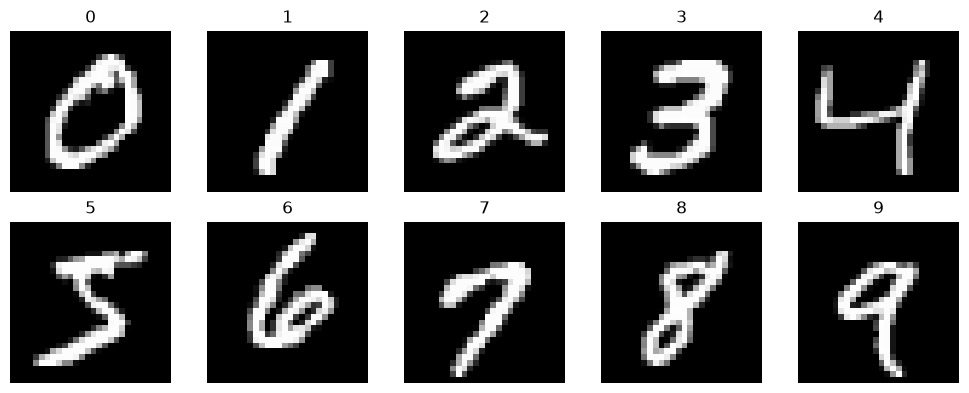

In [ ]:
classes = [str(i) for i in range(10)]

examples = {}

for img, label in training_data:
    if label not in examples:
        examples[label] = img.squeeze()

    if len(examples) == 10:
        break

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i], cmap="gray")
    plt.title(classes[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

#### 2.2.3. Criação dos Dataloaders Reprodutíveis

Definimos uma função para criação dos dataloaders que nos permita retomar o treinamento em caso de interrupção forçada ou indesejada. Por isso retornamos o generator explicitamente, que será persistido junto com o checkpoint durante o treino.

In [ ]:
def criar_train_dataloader(dataset, batch_size, seed, generator_state=None):
    generator = torch.Generator()

    if generator_state is None:
        generator.manual_seed(seed)
    else:
        generator.set_state(generator_state)

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        generator=generator
    )

    return dataloader, generator

Já para o conjunto de testes não é necessário mecanismo de retomada, pois o DataLoader não utilizar a função "Shuffle"

In [ ]:
test_dataloader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

for X, y in test_dataloader:
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")
    print(f"Forma de y [N, ]: {y.shape}, Tipo de dados em y: {y.dtype}")
    break

Forma de X [N, C, H, W]: torch.Size([32, 1, 28, 28]), Tipo de dados em X: torch.float32
Forma de y [N, ]: torch.Size([32]), Tipo de dados em y: torch.int64


### 2.3. Criação de Vetores Latentes Fixos

In [ ]:
diretorio_resultados = Path("resultados_lab2_dcgan")
diretorio_resultados.mkdir(parents=True, exist_ok=True)

arquivo_vetores_avaliacao = diretorio_resultados / "vetores_avaliacao.pt"


if arquivo_vetores_avaliacao.exists():

    msg_warning = "Verifique se houve modificação em z_dim entre a ultima execução e a atual."

    vetores_avaliacao = torch.load(
        arquivo_vetores_avaliacao,
        map_location="cpu"
    )

    if vetores_avaliacao["seed"] != seed:
        print(msg_warning)
        raise ValueError(
            f"Seed incompatível nos vetores de avaliação: "
            f"{vetores_avaliacao['seed']} != {seed}"
        )

    if vetores_avaliacao["z_dim"] != z_dim:
        print(msg_warning)
        raise ValueError(
            f"z_dim incompatível nos vetores de avaliação: "
            f"{vetores_avaliacao['z_dim']} != {z_dim}"
        )

    if vetores_avaliacao["n_amostras"] != n_amostras:
        print(msg_warning)
        raise ValueError(
            f"n_amostras incompatível nos vetores de avaliação: "
            f"{vetores_avaliacao['n_amostras']} != {n_amostras}"
        )

    z_evolucao = vetores_avaliacao["z_evolucao"]
    z_amostras = vetores_avaliacao["z_amostras"]
    z_interp_1 = vetores_avaliacao["z_interp_1"]
    z_interp_2 = vetores_avaliacao["z_interp_2"]


    if z_evolucao.shape != (1, z_dim):
        print(msg_warning)
        raise ValueError("Formato inválido para z_evolucao.")

    if z_amostras.shape != (n_amostras, z_dim):
        print(msg_warning)
        raise ValueError("Formato inválido para z_amostras.")

    if z_interp_1.shape != (1, z_dim):
        print(msg_warning)
        raise ValueError("Formato inválido para z_interp_1.")

    if z_interp_2.shape != (1, z_dim):
        print(msg_warning)
        raise ValueError("Formato inválido para z_interp_2.")

    print("Vetores latentes de avaliação recuperados.")

else:

    generator_avaliacao = torch.Generator(device="cpu")
    generator_avaliacao.manual_seed(seed)

    z_evolucao = torch.randn(
        (1, z_dim),
        generator=generator_avaliacao
    )

    z_amostras = torch.randn(
        (n_amostras, z_dim),
        generator=generator_avaliacao
    )

    z_interp_1 = torch.randn(
        (1, z_dim),
        generator=generator_avaliacao
    )

    z_interp_2 = torch.randn(
        (1, z_dim),
        generator=generator_avaliacao
    )

    torch.save(
        {
            "seed": seed,
            "z_dim": z_dim,
            "n_amostras": n_amostras,
            "z_evolucao": z_evolucao,
            "z_amostras": z_amostras,
            "z_interp_1": z_interp_1,
            "z_interp_2": z_interp_2
        },
        arquivo_vetores_avaliacao
    )

    print("Vetores latentes de avaliação criados e persistidos.")

Vetores latentes de avaliação recuperados.


### 2.4. Redes Neurais

#### 2.4.1. Funções auxiliares de parametrização dos modelos

In [ ]:
def parametros_transicao_gerador(resolucao_origem, resolucao_destino):
    fator = resolucao_destino // resolucao_origem

    if fator == 2:
        return {
            "kernel_size": 5,
            "stride": 2,
            "padding": 2,
            "output_padding": 1
        }

    if fator == 4:
        return {
            "kernel_size": 5,
            "stride": 4,
            "padding": 1,
            "output_padding": 1
        }

    raise ValueError(
        f"Transição não suportada no gerador: "
        f"{resolucao_origem} -> {resolucao_destino}"
    )


def parametros_transicao_discriminador(resolucao_origem, resolucao_destino):
    fator = resolucao_origem // resolucao_destino

    if fator == 2:
        return {
            "kernel_size": 5,
            "stride": 2,
            "padding": 2
        }

    if fator == 4:
        return {
            "kernel_size": 5,
            "stride": 4,
            "padding": 1
        }

    raise ValueError(
        f"Transição não suportada no discriminador: "
        f"{resolucao_origem} -> {resolucao_destino}"
    )

#### 2.4.2. Gerador

Definimos nosso gerador, parametrizado para suportar as variações que pretendemos estabelecer no experimento.

In [ ]:
class Gerador(nn.Module):
    def __init__(
        self,
        z_dim=100,
        resolucoes=(7, 14, 28),
        canais=(128, 64),
        camadas_extras=(0, 0)
    ):
        super().__init__()

        if len(resolucoes) != len(canais) + 1:
            raise ValueError(
                "No gerador, 'resolucoes' deve possuir um elemento a mais que 'canais'."
            )

        if len(camadas_extras) != len(canais):
            raise ValueError(
                "'camadas_extras' deve possuir um valor para cada escala interna."
            )

        if resolucoes[0] != 7 or resolucoes[-1] != 28:
            raise ValueError("O gerador deve operar da resolução 7 para 28.")

        camadas = [
            nn.Linear(z_dim, 7 * 7 * canais[0]),
            nn.Unflatten(
                dim=1,
                unflattened_size=(canais[0], 7, 7)
            ),
            nn.BatchNorm2d(canais[0])
        ]

        # Camadas adicionais na resolução inicial
        for _ in range(camadas_extras[0]):
            camadas.extend([
                nn.Conv2d(
                    canais[0],
                    canais[0],
                    kernel_size=3,
                    stride=1,
                    padding=1
                ),
                nn.ReLU(True),
                nn.BatchNorm2d(canais[0])
            ])

        # Transições entre as escalas internas
        for i in range(len(canais) - 1):
            parametros = parametros_transicao_gerador(
                resolucoes[i],
                resolucoes[i + 1]
            )

            camadas.extend([
                nn.ConvTranspose2d(
                    canais[i],
                    canais[i + 1],
                    **parametros
                ),
                nn.ReLU(True),
                nn.BatchNorm2d(canais[i + 1])
            ])

            for _ in range(camadas_extras[i + 1]):
                camadas.extend([
                    nn.Conv2d(
                        canais[i + 1],
                        canais[i + 1],
                        kernel_size=3,
                        stride=1,
                        padding=1
                    ),
                    nn.ReLU(True),
                    nn.BatchNorm2d(canais[i + 1])
                ])

        # Última transição produz a imagem 28 x 28 com um canal
        parametros = parametros_transicao_gerador(
            resolucoes[-2],
            resolucoes[-1]
        )

        camadas.extend([
            nn.ConvTranspose2d(
                canais[-1],
                1,
                **parametros
            ),
            nn.Tanh()
        ])

        self.net = nn.Sequential(*camadas)

    def forward(self, z):
        return self.net(z)

#### 2.4.3. Discriminador

E a seguir fazemos o mesmo para o discriminador.

In [ ]:
class Discriminador(nn.Module):
    def __init__(
        self,
        resolucoes=(28, 14, 7),
        canais=(64, 128),
        camadas_extras=(0, 0),
        dropout=0.4
    ):
        super().__init__()

        if len(resolucoes) != len(canais) + 1:
            raise ValueError(
                "No discriminador, 'resolucoes' deve possuir um elemento a mais que 'canais'."
            )

        if len(camadas_extras) != len(canais):
            raise ValueError(
                "'camadas_extras' deve possuir um valor para cada escala interna."
            )

        if resolucoes[0] != 28 or resolucoes[-1] != 7:
            raise ValueError("O discriminador deve operar da resolução 28 para 7.")

        camadas = []

        for i in range(len(canais)):
            canais_entrada = 1 if i == 0 else canais[i - 1]

            parametros = parametros_transicao_discriminador(
                resolucoes[i],
                resolucoes[i + 1]
            )

            camadas.extend([
                nn.Conv2d(
                    canais_entrada,
                    canais[i],
                    **parametros
                ),
                nn.LeakyReLU(negative_slope=0.2),
                nn.Dropout(p=dropout)
            ])

            for _ in range(camadas_extras[i]):
                camadas.extend([
                    nn.Conv2d(
                        canais[i],
                        canais[i],
                        kernel_size=3,
                        stride=1,
                        padding=1
                    ),
                    nn.LeakyReLU(negative_slope=0.2),
                    nn.Dropout(p=dropout)
                ])

        camadas.extend([
            nn.Flatten(),
            nn.Linear(
                resolucoes[-1] * resolucoes[-1] * canais[-1],
                1
            ),
            nn.Sigmoid()
        ])

        self.net = nn.Sequential(*camadas)

    def forward(self, x):
        return self.net(x)

#### 2.4.4. Definição da configuração base de referencia.

In [ ]:
config_gerador_base = {
    "z_dim": z_dim,
    "resolucoes": [7, 14, 28],
    "canais": [128, 64],
    "camadas_extras": [0, 0]
}

config_discriminador_base = {
    "resolucoes": [28, 14, 7],
    "canais": [64, 128],
    "camadas_extras": [0, 0],
    "dropout": 0.4
}

#### 2.4.5. Criação e Exibição da Arquitetura Base de Referência

In [ ]:
definir_semente(seed)

modelo_gerador_base = Gerador(**config_gerador_base)
modelo_discriminador_base = Discriminador(**config_discriminador_base)

z_teste = torch.randn((batch_size, z_dim))

with torch.no_grad():
    imagens_teste = modelo_gerador_base(z_teste)
    saidas_teste = modelo_discriminador_base(imagens_teste)

assert imagens_teste.shape == (batch_size, 1, 28, 28)
assert saidas_teste.shape == (batch_size, 1)

print(modelo_gerador_base)
print()
print(modelo_discriminador_base)

print()
print(f"Parâmetros do gerador: {contar_parametros(modelo_gerador_base):,}")
print(f"Parâmetros do discriminador: {contar_parametros(modelo_discriminador_base):,}")
print(f"Saída do gerador: {imagens_teste.shape}")
print(f"Saída do discriminador: {saidas_teste.shape}")

Gerador(
  (net): Sequential(
    (0): Linear(in_features=100, out_features=6272, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (7): Tanh()
  )
)

Discriminador(
  (net): Sequential(
    (0): Conv2d(1, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.4, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.4, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
 

#### 2.4.6. Validação da Arquitetura Base

In [ ]:
def validar_arquitetura_base(gerador, discriminador):
    # Gerador
    assert isinstance(gerador.net[0], nn.Linear)
    assert gerador.net[0].in_features == 100
    assert gerador.net[0].out_features == 7 * 7 * 128

    assert isinstance(gerador.net[1], nn.Unflatten)
    assert isinstance(gerador.net[2], nn.BatchNorm2d)
    assert gerador.net[2].num_features == 128

    assert isinstance(gerador.net[3], nn.ConvTranspose2d)
    assert gerador.net[3].in_channels == 128
    assert gerador.net[3].out_channels == 64
    assert gerador.net[3].kernel_size == (5, 5)
    assert gerador.net[3].stride == (2, 2)
    assert gerador.net[3].padding == (2, 2)
    assert gerador.net[3].output_padding == (1, 1)

    assert isinstance(gerador.net[4], nn.ReLU)

    assert isinstance(gerador.net[5], nn.BatchNorm2d)
    assert gerador.net[5].num_features == 64

    assert isinstance(gerador.net[6], nn.ConvTranspose2d)
    assert gerador.net[6].in_channels == 64
    assert gerador.net[6].out_channels == 1
    assert gerador.net[6].kernel_size == (5, 5)
    assert gerador.net[6].stride == (2, 2)
    assert gerador.net[6].padding == (2, 2)
    assert gerador.net[6].output_padding == (1, 1)

    assert isinstance(gerador.net[7], nn.Tanh)

    # Discriminador
    assert isinstance(discriminador.net[0], nn.Conv2d)
    assert discriminador.net[0].in_channels == 1
    assert discriminador.net[0].out_channels == 64
    assert discriminador.net[0].kernel_size == (5, 5)
    assert discriminador.net[0].stride == (2, 2)
    assert discriminador.net[0].padding == (2, 2)

    assert isinstance(discriminador.net[1], nn.LeakyReLU)
    assert discriminador.net[1].negative_slope == 0.2

    assert isinstance(discriminador.net[2], nn.Dropout)
    assert discriminador.net[2].p == 0.4

    assert isinstance(discriminador.net[3], nn.Conv2d)
    assert discriminador.net[3].in_channels == 64
    assert discriminador.net[3].out_channels == 128
    assert discriminador.net[3].kernel_size == (5, 5)
    assert discriminador.net[3].stride == (2, 2)
    assert discriminador.net[3].padding == (2, 2)

    assert isinstance(discriminador.net[4], nn.LeakyReLU)
    assert discriminador.net[4].negative_slope == 0.2

    assert isinstance(discriminador.net[5], nn.Dropout)
    assert discriminador.net[5].p == 0.4

    assert isinstance(discriminador.net[6], nn.Flatten)

    assert isinstance(discriminador.net[7], nn.Linear)
    assert discriminador.net[7].in_features == 7 * 7 * 128
    assert discriminador.net[7].out_features == 1

    assert isinstance(discriminador.net[8], nn.Sigmoid)

    # Quantidade total de parâmetros
    assert contar_parametros(gerador) == 840_321
    assert contar_parametros(discriminador) == 212_865

    # Formato das saídas
    z_teste = torch.randn((batch_size, z_dim))

    with torch.no_grad():
        imagens_teste = gerador(z_teste)
        saidas_teste = discriminador(imagens_teste)

    assert imagens_teste.shape == (batch_size, 1, 28, 28)
    assert saidas_teste.shape == (batch_size, 1)

    print("Arquitetura base validada com sucesso.")


validar_arquitetura_base(
    modelo_gerador_base,
    modelo_discriminador_base
)

Arquitetura base validada com sucesso.


### 2.5. Configurações dos Experimentos

#### 2.5.1. Definição declarativa

In [ ]:
experimentos = {

    # ============================================================
    # Configuração base
    # ============================================================

    "base": {
        "nome": "Base",
        "fator": "referencia",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    # ============================================================
    # Capacidade do gerador
    # ============================================================

    "gerador_reduzido": {
        "nome": "Gerador reduzido",
        "fator": "capacidade_gerador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 28],
            "canais": [32],
            "camadas_extras": [0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    "gerador_ampliado": {
        "nome": "Gerador ampliado",
        "fator": "capacidade_gerador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [256, 128],
            "camadas_extras": [2, 2]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    # ============================================================
    # Capacidade do discriminador
    # ============================================================

    "discriminador_reduzido": {
        "nome": "Discriminador reduzido",
        "fator": "capacidade_discriminador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [24, 64],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    "discriminador_ampliado": {
        "nome": "Discriminador ampliado",
        "fator": "capacidade_discriminador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [80, 160],
            "camadas_extras": [2, 2],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    # ============================================================
    # Gerador e Discriminador ampliados
    # ============================================================

    "ambos_ampliados": {
        "nome": "Gerador e discriminador ampliados",
        "fator": "capacidade_ambos",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [256, 128],
            "camadas_extras": [2, 2]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [80, 160],
            "camadas_extras": [2, 2],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    },

    # ============================================================
    # Taxas de aprendizado
    # ============================================================

    "lr_gerador_maior": {
        "nome": "LR gerador >> discriminador",
        "fator": "learning_rate",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-5
        }
    },

    "lr_discriminador_maior": {
        "nome": "LR gerador << discriminador",
        "fator": "learning_rate",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-5,
            "lr_discriminador": 1e-3
        }
    },

    "lr_ambos_menores": {
        "nome": "LR ambos menores",
        "fator": "learning_rate",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "RMSprop",
            "lr_gerador": 1e-4,
            "lr_discriminador": 1e-4
        }
    },

    # ============================================================
    # Otimizador
    # ============================================================

    "sgd": {
        "nome": "SGD",
        "fator": "otimizador",

        "gerador": {
            "z_dim": z_dim,
            "resolucoes": [7, 14, 28],
            "canais": [128, 64],
            "camadas_extras": [0, 0]
        },

        "discriminador": {
            "resolucoes": [28, 14, 7],
            "canais": [64, 128],
            "camadas_extras": [0, 0],
            "dropout": 0.4
        },

        "treinamento": {
            "batch_size": batch_size,
            "num_epochs": num_epochs,
            "seed": seed,
            "loss_fn": "BCELoss",
            "otimizador": "SGD",
            "lr_gerador": 1e-3,
            "lr_discriminador": 1e-3
        }
    }
}

#### 2.5.2. Validação da Definição

In [ ]:
def validar_experimentos(experimentos):
    base = experimentos["base"]

    for id_experimento, config in experimentos.items():

        assert config["gerador"]["z_dim"] == z_dim
        assert config["treinamento"]["batch_size"] == batch_size
        assert config["treinamento"]["num_epochs"] == num_epochs
        assert config["treinamento"]["seed"] == seed
        assert config["treinamento"]["loss_fn"] == "BCELoss"

        fator = config["fator"]

        if fator == "capacidade_gerador":
            assert config["discriminador"] == base["discriminador"]
            assert config["treinamento"] == base["treinamento"]

        elif fator == "capacidade_discriminador":
            assert config["gerador"] == base["gerador"]
            assert config["treinamento"] == base["treinamento"]

        elif fator == "learning_rate":
            assert config["gerador"] == base["gerador"]
            assert config["discriminador"] == base["discriminador"]
            assert config["treinamento"]["otimizador"] == "RMSprop"

        elif fator == "otimizador":
            assert config["gerador"] == base["gerador"]
            assert config["discriminador"] == base["discriminador"]
            assert config["treinamento"]["lr_gerador"] == base["treinamento"]["lr_gerador"]
            assert config["treinamento"]["lr_discriminador"] == base["treinamento"]["lr_discriminador"]

        elif fator == "capacidade_ambos":
            assert config["gerador"] == experimentos["gerador_ampliado"]["gerador"]
            assert config["discriminador"] == experimentos["discriminador_ampliado"]["discriminador"]
            assert config["treinamento"] == base["treinamento"]

    print(f"{len(experimentos)} configurações de experimento validadas.")


validar_experimentos(experimentos)

10 configurações de experimento validadas.


#### 2.5.3. Exibir Tabela de Experimentos

In [ ]:
def resumir_arquitetura(config, tipo):
    resolucoes = " → ".join(map(str, config["resolucoes"]))
    canais = " → ".join(map(str, config["canais"]))
    extras = " → ".join(map(str, config["camadas_extras"]))

    return (
        f"res={resolucoes}; "
        f"canais={canais}; "
        f"extras={extras}"
    )


def criar_tabela_experimentos(experimentos):
    linhas = []

    for id_experimento, config in experimentos.items():
        gerador = Gerador(**config["gerador"])
        discriminador = Discriminador(**config["discriminador"])

        treinamento = config["treinamento"]

        linhas.append({
            "Experimento": id_experimento,
            "Nome": config["nome"],
            "Fator": config["fator"],
            "Gerador": resumir_arquitetura(
                config["gerador"],
                "gerador"
            ),
            "Parâmetros G": contar_parametros(gerador),
            "Discriminador": resumir_arquitetura(
                config["discriminador"],
                "discriminador"
            ),
            "Parâmetros D": contar_parametros(discriminador),
            "Otimizador": treinamento["otimizador"],
            "LR G": treinamento["lr_gerador"],
            "LR D": treinamento["lr_discriminador"]
        })

    return pd.DataFrame(linhas)


tabela_experimentos = criar_tabela_experimentos(experimentos)

tabela_experimentos

,Experimento,Nome,Fator,Gerador,Parâmetros G,Discriminador,Parâmetros D,Otimizador,LR G,LR D
0,base,Base,referencia,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00100,0.00100
1,gerador_reduzido,Gerador reduzido,capacidade_gerador,res=7 → 28; canais=32; extras=0,159233,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00100,0.00100
2,gerador_ampliado,Gerador ampliado,capacidade_gerador,res=7 → 14 → 28; canais=256 → 128; extras=2 → 2,3567105,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00100,0.00100
3,discriminador_reduzido,Discriminador reduzido,capacidade_discriminador,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=24 → 64; extras=0 → 0,42225,RMSprop,0.00100,0.00100
4,discriminador_ampliado,Discriminador ampliado,capacidade_discriminador,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=80 → 160; extras=2 → 2,906561,RMSprop,0.00100,0.00100
5,ambos_ampliados,Gerador e discriminador ampliados,capacidade_ambos,res=7 → 14 → 28; canais=256 → 128; extras=2 → 2,3567105,res=28 → 14 → 7; canais=80 → 160; extras=2 → 2,906561,RMSprop,0.00100,0.00100
6,lr_gerador_maior,LR gerador >> discriminador,learning_rate,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00100,0.00001
7,lr_discriminador_maior,LR gerador << discriminador,learning_rate,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00001,0.00100
8,lr_ambos_menores,LR ambos menores,learning_rate,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,RMSprop,0.00010,0.00010
9,sgd,SGD,otimizador,res=7 → 14 → 28; canais=128 → 64; extras=0 → 0,840321,res=28 → 14 → 7; canais=64 → 128; extras=0 → 0,212865,SGD,0.00100,0.00100


#### 2.5.4. Critério de Redução e Amplicação de Capacidades do Modelo

A capacidade dos modelos foi comparada principalmente pelo número de parâmetros treináveis. As versões reduzidas foram ajustadas para manter cerca de 20% da capacidade da configuração base, enquanto as ampliadas ficaram em torno de 4,25 vezes o número original de parâmetros. A tabela a seguir mostra isso em detalhes.

In [ ]:
comparacao_capacidade = pd.DataFrame([
    {
        "Rede": "Gerador",
        "Base": contar_parametros(
            Gerador(**experimentos["base"]["gerador"])
        ),
        "Reduzida": contar_parametros(
            Gerador(**experimentos["gerador_reduzido"]["gerador"])
        ),
        "Ampliada": contar_parametros(
            Gerador(**experimentos["gerador_ampliado"]["gerador"])
        )
    },
    {
        "Rede": "Discriminador",
        "Base": contar_parametros(
            Discriminador(**experimentos["base"]["discriminador"])
        ),
        "Reduzida": contar_parametros(
            Discriminador(**experimentos["discriminador_reduzido"]["discriminador"])
        ),
        "Ampliada": contar_parametros(
            Discriminador(**experimentos["discriminador_ampliado"]["discriminador"])
        )
    }
])

comparacao_capacidade["Redução (%)"] = (
    1 - comparacao_capacidade["Reduzida"] / comparacao_capacidade["Base"]
) * 100

comparacao_capacidade["Ampliação (x)"] = (
    comparacao_capacidade["Ampliada"] / comparacao_capacidade["Base"]
)

comparacao_capacidade

,Rede,Base,Reduzida,Ampliada,Redução (%),Ampliação (x)
0,Gerador,840321,159233,3567105,81.050932,4.244931
1,Discriminador,212865,42225,906561,80.163484,4.258854


### 2.6. Treinamento

#### 2.6.1. Criação de Funções de Perda e de Otimizadores

In [ ]:
def criar_loss_fn(config_treinamento):
    nome = config_treinamento["loss_fn"]

    if nome == "BCELoss":
        return nn.BCELoss()

    raise ValueError(f"Função de perda não suportada: {nome}")

In [ ]:
def criar_otimizadores(
    gerador,
    discriminador,
    config_treinamento
):
    nome = config_treinamento["otimizador"]

    lr_gerador = config_treinamento["lr_gerador"]
    lr_discriminador = config_treinamento["lr_discriminador"]

    if nome == "RMSprop":
        opt_gerador = torch.optim.RMSprop(
            gerador.parameters(),
            lr=lr_gerador
        )

        opt_discriminador = torch.optim.RMSprop(
            discriminador.parameters(),
            lr=lr_discriminador
        )

    elif nome == "SGD":
        opt_gerador = torch.optim.SGD(
            gerador.parameters(),
            lr=lr_gerador
        )

        opt_discriminador = torch.optim.SGD(
            discriminador.parameters(),
            lr=lr_discriminador
        )

    else:
        raise ValueError(f"Otimizador não suportado: {nome}")

    return opt_gerador, opt_discriminador

#### 2.6.2. Validação da Configuração Base

In [ ]:
config_treinamento_base = experimentos["base"]["treinamento"]

loss_fn_teste = criar_loss_fn(
    config_treinamento_base
)

opt_gerador_teste, opt_discriminador_teste = criar_otimizadores(
    modelo_gerador_base,
    modelo_discriminador_base,
    config_treinamento_base
)

assert isinstance(loss_fn_teste, nn.BCELoss)

assert isinstance(
    opt_gerador_teste,
    torch.optim.RMSprop
)

assert isinstance(
    opt_discriminador_teste,
    torch.optim.RMSprop
)

assert opt_gerador_teste.param_groups[0]["lr"] == 1e-3
assert opt_discriminador_teste.param_groups[0]["lr"] == 1e-3

print("Função de perda e otimizadores da configuração base validados.")

Função de perda e otimizadores da configuração base validados.


#### 2.6.3. Função de Treinamento

In [ ]:
def train_dcgan(
    dataloader,
    gerador,
    discriminador,
    loss_fn,
    opt_gerador,
    opt_discriminador,
    device,
    epoch,
    z_dim
):
    gerador.train()
    discriminador.train()

    soma_perda_gerador = torch.zeros((), device=device)
    soma_perda_discriminador = torch.zeros((), device=device)
    soma_score_reais = torch.zeros((), device=device)
    soma_score_falsos = torch.zeros((), device=device)

    num_lotes = len(dataloader)

    for batch, (real_data, _) in enumerate(dataloader):

        batch_atual = real_data.shape[0]
        real_data = real_data.to(device)

        # ========================================================
        # Treinamento do discriminador
        # ========================================================

        labels_reais = torch.ones(
            (batch_atual, 1),
            device=device
        )

        labels_falsos = torch.zeros(
            (batch_atual, 1),
            device=device
        )

        z = torch.randn(
            (batch_atual, z_dim),
            device=device
        )

        dados_falsos = gerador(z)

        saida_reais = discriminador(real_data)
        saida_falsos_d = discriminador(
            dados_falsos.detach()
        )

        perda_reais = loss_fn(
            saida_reais,
            labels_reais
        )

        perda_falsos = loss_fn(
            saida_falsos_d,
            labels_falsos
        )

        perda_discriminador = (
            perda_reais + perda_falsos
        )

        opt_discriminador.zero_grad()
        perda_discriminador.backward()
        opt_discriminador.step()

        # ========================================================
        # Treinamento do gerador
        # ========================================================

        z = torch.randn(
            (batch_atual, z_dim),
            device=device
        )

        dados_falsos = gerador(z)

        saida_falsos_g = discriminador(
            dados_falsos
        )

        perda_gerador = loss_fn(
            saida_falsos_g,
            labels_reais
        )

        opt_gerador.zero_grad()
        perda_gerador.backward()
        opt_gerador.step()

        # ========================================================
        # Acumulação das métricas da época
        # ========================================================

        soma_perda_gerador += perda_gerador.detach()
        soma_perda_discriminador += perda_discriminador.detach()

        soma_score_reais += saida_reais.detach().mean()
        soma_score_falsos += saida_falsos_d.detach().mean()

        # ========================================================
        # Log de progresso
        # ========================================================

        if batch % 100 == 0 or batch == num_lotes - 1:
            print(
                f"[Época {epoch:03d}] "
                f"[Lote {batch:04d}/{num_lotes - 1:04d}] "
                f"Perda D: {perda_discriminador.item():.4f} | "
                f"Perda G: {perda_gerador.item():.4f} | "
                f"Score reais: {saida_reais.detach().mean().item():.4f} | "
                f"Score falsos: {saida_falsos_d.detach().mean().item():.4f}"
            )

    return {
        "loss_gerador":       (soma_perda_gerador       / num_lotes).item(),
        "loss_discriminador": (soma_perda_discriminador / num_lotes).item(),
        "score_reais":        (soma_score_reais         / num_lotes).item(),
        "score_falsos":       (soma_score_falsos        / num_lotes).item()
    }

### 2.7. Funções Auxiliares de Avaliação

#### 2.7.1. Geração de imagens a partir de vetores latentes

In [ ]:
def gerar_saida(
    gerador,
    z,
    device
):
    gerador.eval()

    with torch.no_grad():
        imagens = gerador(
            z.to(device)
        ).detach().cpu()

    return imagens

#### 2.7.2. Geração da saída para acompanhamento da evolução do treinamento

In [ ]:
def gerar_evolucao(
    gerador,
    z_evolucao,
    device
):
    imagens = gerar_saida(
        gerador=gerador,
        z=z_evolucao,
        device=device
    )

    return imagens.squeeze(0)

#### 2.7.2. Geração das amostras finais do experimento

In [ ]:
def gerar_amostras_finais(
    gerador,
    z_amostras,
    device
):
    return gerar_saida(
        gerador=gerador,
        z=z_amostras,
        device=device
    )

#### 2.7.3. Validação das funções

In [ ]:
modelo_gerador_base.to(device)

imagem_evolucao_teste = gerar_evolucao(
    gerador=modelo_gerador_base,
    z_evolucao=z_evolucao,
    device=device
)

amostras_teste = gerar_amostras_finais(
    gerador=modelo_gerador_base,
    z_amostras=z_amostras,
    device=device
)

assert imagem_evolucao_teste.device.type == "cpu"
assert amostras_teste.device.type == "cpu"

assert imagem_evolucao_teste.shape == (1, 28, 28)
assert amostras_teste.shape == (n_amostras, 1, 28, 28)

print("Funções de geração para avaliação validadas.")

Funções de geração para avaliação validadas.


### 2.8. Salvamento e Recuperação

#### 2.8.1. Caminhos e salvamento seguro dos arquivos

In [ ]:
def obter_caminhos_experimento(id_experimento):
    diretorio = diretorio_resultados / id_experimento
    diretorio.mkdir(parents=True, exist_ok=True)

    return {
        "diretorio": diretorio,
        "checkpoint_treinamento": diretorio / "checkpoint_treinamento.pt",
        "checkpoint_final": diretorio / "checkpoint_final.pt",
        "resultado": diretorio / "resultado.pt"
    }


def mover_para_cpu(objeto):
    if isinstance(objeto, torch.Tensor):
        return objeto.detach().cpu()

    if isinstance(objeto, dict):
        return {
            chave: mover_para_cpu(valor)
            for chave, valor in objeto.items()
        }

    if isinstance(objeto, list):
        return [
            mover_para_cpu(valor)
            for valor in objeto
        ]

    if isinstance(objeto, tuple):
        return tuple(
            mover_para_cpu(valor)
            for valor in objeto
        )

    return objeto


def salvar_torch_atomico(objeto, caminho):
    caminho_temporario = caminho.with_suffix(
        caminho.suffix + ".tmp"
    )

    torch.save(
        mover_para_cpu(objeto),
        caminho_temporario
    )

    caminho_temporario.replace(caminho)

#### 2.8.2. Captura e restauração dos estados aleatórios

In [ ]:
def capturar_estado_rng(device):
    estado = {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch_cpu": torch.get_rng_state(),
        "device_type": device.type
    }

    if device.type == "cuda":
        estado["torch_device"] = torch.cuda.get_rng_state_all()

    elif device.type == "mps":
        estado["torch_device"] = torch.mps.get_rng_state()

    return mover_para_cpu(estado)


def restaurar_estado_rng(estado, device):
    if estado["device_type"] != device.type:
        raise ValueError(
            f"O checkpoint foi criado em '{estado['device_type']}', "
            f"mas a retomada está sendo executada em '{device.type}'."
        )

    random.setstate(estado["python"])
    np.random.set_state(estado["numpy"])
    torch.set_rng_state(estado["torch_cpu"])

    if device.type == "cuda":
        torch.cuda.set_rng_state_all(
            estado["torch_device"]
        )

    elif device.type == "mps":
        torch.mps.set_rng_state(
            estado["torch_device"]
        )

#### 2.8.3. Salvamento do checkpoint de treinamento

In [ ]:
def salvar_checkpoint_treinamento(
    id_experimento,
    config,
    epoch,
    gerador,
    discriminador,
    opt_gerador,
    opt_discriminador,
    historico,
    evolucao_z_fixo,
    dataloader_generator,
    device
):
    caminhos = obter_caminhos_experimento(
        id_experimento
    )

    checkpoint = {
        "id_experimento": id_experimento,
        "config": config,
        "epoch": epoch,

        "gerador_state_dict": gerador.state_dict(),
        "discriminador_state_dict": discriminador.state_dict(),

        "opt_gerador_state_dict": opt_gerador.state_dict(),
        "opt_discriminador_state_dict": opt_discriminador.state_dict(),

        "historico": historico,
        "evolucao_z_fixo": evolucao_z_fixo,

        "dataloader_generator_state":
            dataloader_generator.get_state(),

        "rng_state": capturar_estado_rng(device)
    }

    salvar_torch_atomico(
        checkpoint,
        caminhos["checkpoint_treinamento"]
    )

#### 2.8.4. Recuperação do checkpoint de treinamento

In [ ]:
def carregar_checkpoint_treinamento(
    id_experimento,
    config
):
    caminhos = obter_caminhos_experimento(
        id_experimento
    )

    caminho = caminhos["checkpoint_treinamento"]

    if not caminho.exists():
        return None

    checkpoint = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )

    if checkpoint["id_experimento"] != id_experimento:
        raise ValueError(
            "O checkpoint pertence a outro experimento."
        )

    if checkpoint["config"] != config:
        raise ValueError(
            f"A configuração atual do experimento "
            f"'{id_experimento}' é diferente da configuração "
            f"armazenada no checkpoint."
        )

    validar_historico(
        historico=checkpoint["historico"],
        epocas_concluidas=checkpoint["epoch"],
        evolucao_z_fixo=checkpoint["evolucao_z_fixo"]
    )

    return checkpoint

#### 2.8.5. Salvamento do checkpoint e do resultado final

In [ ]:
def salvar_resultado_final(
    id_experimento,
    config,
    gerador,
    discriminador,
    historico,
    evolucao_z_fixo,
    amostras_finais,
    device
):
    caminhos = obter_caminhos_experimento(
        id_experimento
    )

    checkpoint_final = {
        "id_experimento": id_experimento,
        "config": config,

        "gerador_state_dict": gerador.state_dict(),
        "discriminador_state_dict": discriminador.state_dict()
    }

    resultado = {
        "id_experimento": id_experimento,
        "config": config,

        "historico": historico,

        "avaliacao": {
            "evolucao_z_fixo": torch.stack(
                evolucao_z_fixo
            ),
            "amostras_finais": amostras_finais
        },

        "metadados": {
            "seed": config["treinamento"]["seed"],
            "num_epochs": config["treinamento"]["num_epochs"],
            "batch_size": config["treinamento"]["batch_size"],
            "z_dim": config["gerador"]["z_dim"],
            "device_treinamento": device.type,
            "parametros_gerador": contar_parametros(gerador),
            "parametros_discriminador": contar_parametros(discriminador)
        }
    }

    salvar_torch_atomico(
        checkpoint_final,
        caminhos["checkpoint_final"]
    )

    salvar_torch_atomico(
        resultado,
        caminhos["resultado"]
    )

    if caminhos["checkpoint_treinamento"].exists():
        caminhos["checkpoint_treinamento"].unlink()

#### 2.8.6. Carregamento de resultados já concluídos

In [ ]:
def carregar_resultado_final(
    id_experimento,
    config
):
    caminhos = obter_caminhos_experimento(
        id_experimento
    )

    caminho = caminhos["resultado"]

    if not caminho.exists():
        return None

    resultado = torch.load(
        caminho,
        map_location="cpu",
        weights_only=False
    )

    if resultado["id_experimento"] != id_experimento:
        raise ValueError(
            "O resultado pertence a outro experimento."
        )

    if resultado["config"] != config:
        raise ValueError(
            f"A configuração atual do experimento "
            f"'{id_experimento}' é diferente da configuração "
            f"armazenada no resultado."
        )

    return resultado

### 2.9. Execução dos Experimentos

#### 2.9.1. Estrutura de controle de execução do experimentos

A seguir definimos funções auxiliares que ajudam na estruturação do controle de execução dos experimentos. Cada função realiza uma tarefa bem definida, e no final uma função principal consolida cada uma das etapas.

##### 2.9.1.1. Validação estrutural do resultado

In [ ]:
def validar_resultado_experimento(
    resultado,
    config
):
    num_epochs_esperado = config["treinamento"]["num_epochs"]

    historico = resultado["historico"]
    avaliacao = resultado["avaliacao"]

    validar_historico(
        historico=historico,
        epocas_concluidas=num_epochs_esperado,
        evolucao_z_fixo=avaliacao["evolucao_z_fixo"]
    )

    assert avaliacao["evolucao_z_fixo"].shape == (
        num_epochs_esperado + 1,
        1,
        28,
        28
    )

    assert avaliacao["amostras_finais"].shape == (
        n_amostras,
        1,
        28,
        28
    )

    assert avaliacao["evolucao_z_fixo"].device.type == "cpu"
    assert avaliacao["amostras_finais"].device.type == "cpu"

    print("Estrutura do resultado validada com sucesso.")

##### 2.9.1.2. Validação da consistência do histórico

In [ ]:
def validar_historico(
    historico,
    epocas_concluidas,
    evolucao_z_fixo
):
    chaves = [
        "loss_gerador",
        "loss_discriminador",
        "score_reais",
        "score_falsos"
    ]

    for chave in chaves:
        assert len(historico[chave]) == epocas_concluidas, (
            f"Histórico '{chave}' inconsistente: "
            f"{len(historico[chave])} registros para "
            f"{epocas_concluidas} épocas concluídas."
        )

        assert np.all(np.isfinite(historico[chave])), (
            f"Histórico '{chave}' contém valores NaN ou infinitos."
        )

    assert len(evolucao_z_fixo) == epocas_concluidas + 1, (
        f"Evolução do vetor fixo inconsistente: "
        f"{len(evolucao_z_fixo)} registros para "
        f"{epocas_concluidas} épocas concluídas."
    )

##### 2.9.1.3. Inicialização de um novo experimento

In [ ]:
def iniciar_novo_experimento(
    config,
    training_data,
    device,
    z_evolucao
):
    config_treinamento = config["treinamento"]

    definir_semente(
        config_treinamento["seed"]
    )

    gerador = Gerador(
        **config["gerador"]
    ).to(device)

    discriminador = Discriminador(
        **config["discriminador"]
    ).to(device)

    loss_fn = criar_loss_fn(
        config_treinamento
    )

    opt_gerador, opt_discriminador = criar_otimizadores(
        gerador,
        discriminador,
        config_treinamento
    )

    train_dataloader, dataloader_generator = criar_train_dataloader(
        dataset=training_data,
        batch_size=config_treinamento["batch_size"],
        seed=config_treinamento["seed"]
    )

    historico = {
        "loss_gerador": [],
        "loss_discriminador": [],
        "score_reais": [],
        "score_falsos": []
    }

    # Época 0: saída antes do treinamento
    evolucao_z_fixo = [
        gerar_evolucao(
            gerador=gerador,
            z_evolucao=z_evolucao,
            device=device
        )
    ]

    return {
        "gerador": gerador,
        "discriminador": discriminador,
        "loss_fn": loss_fn,
        "opt_gerador": opt_gerador,
        "opt_discriminador": opt_discriminador,
        "train_dataloader": train_dataloader,
        "dataloader_generator": dataloader_generator,
        "historico": historico,
        "evolucao_z_fixo": evolucao_z_fixo,
        "epoca_inicial": 1
    }

##### 2.9.1.4. Retomada de um experimento interrompido

In [ ]:
def retomar_experimento(
    config,
    checkpoint,
    training_data,
    device
):
    config_treinamento = config["treinamento"]

    gerador = Gerador(
        **config["gerador"]
    ).to(device)

    discriminador = Discriminador(
        **config["discriminador"]
    ).to(device)

    gerador.load_state_dict(
        checkpoint["gerador_state_dict"]
    )

    discriminador.load_state_dict(
        checkpoint["discriminador_state_dict"]
    )

    loss_fn = criar_loss_fn(
        config_treinamento
    )

    opt_gerador, opt_discriminador = criar_otimizadores(
        gerador,
        discriminador,
        config_treinamento
    )

    opt_gerador.load_state_dict(
        checkpoint["opt_gerador_state_dict"]
    )

    opt_discriminador.load_state_dict(
        checkpoint["opt_discriminador_state_dict"]
    )

    train_dataloader, dataloader_generator = criar_train_dataloader(
        dataset=training_data,
        batch_size=config_treinamento["batch_size"],
        seed=config_treinamento["seed"],
        generator_state=checkpoint[
            "dataloader_generator_state"
        ]
    )

    restaurar_estado_rng(
        checkpoint["rng_state"],
        device
    )

    return {
        "gerador": gerador,
        "discriminador": discriminador,
        "loss_fn": loss_fn,
        "opt_gerador": opt_gerador,
        "opt_discriminador": opt_discriminador,
        "train_dataloader": train_dataloader,
        "dataloader_generator": dataloader_generator,
        "historico": checkpoint["historico"],
        "evolucao_z_fixo": checkpoint["evolucao_z_fixo"],
        "epoca_inicial": checkpoint["epoch"] + 1
    }

##### 2.9.1.5. Registro das métricas de uma época

In [ ]:
def registrar_metricas_epoca(
    historico,
    metricas
):
    historico["loss_gerador"].append(
        metricas["loss_gerador"]
    )

    historico["loss_discriminador"].append(
        metricas["loss_discriminador"]
    )

    historico["score_reais"].append(
        metricas["score_reais"]
    )

    historico["score_falsos"].append(
        metricas["score_falsos"]
    )

##### 2.9.1.6. Execução das épocas do experimento

In [ ]:
def treinar_experimento(
    id_experimento,
    config,
    estado,
    device,
    z_evolucao
):
    num_epochs = config["treinamento"]["num_epochs"]
    z_dim = config["gerador"]["z_dim"]

    for epoch in range(
        estado["epoca_inicial"],
        num_epochs + 1
    ):
        metricas = train_dcgan(
            dataloader=estado["train_dataloader"],
            gerador=estado["gerador"],
            discriminador=estado["discriminador"],
            loss_fn=estado["loss_fn"],
            opt_gerador=estado["opt_gerador"],
            opt_discriminador=estado["opt_discriminador"],
            device=device,
            epoch=epoch,
            z_dim=z_dim
        )

        registrar_metricas_epoca(
            estado["historico"],
            metricas
        )

        estado["evolucao_z_fixo"].append(
            gerar_evolucao(
                gerador=estado["gerador"],
                z_evolucao=z_evolucao,
                device=device
            )
        )

        print(
            f"[Época {epoch:03d}] "
            f"Média D: {metricas['loss_discriminador']:.4f} | "
            f"Média G: {metricas['loss_gerador']:.4f} | "
            f"Score reais: {metricas['score_reais']:.4f} | "
            f"Score falsos: {metricas['score_falsos']:.4f}"
        )

        salvar_checkpoint_treinamento(
            id_experimento=id_experimento,
            config=config,
            epoch=epoch,
            gerador=estado["gerador"],
            discriminador=estado["discriminador"],
            opt_gerador=estado["opt_gerador"],
            opt_discriminador=estado["opt_discriminador"],
            historico=estado["historico"],
            evolucao_z_fixo=estado["evolucao_z_fixo"],
            dataloader_generator=estado["dataloader_generator"],
            device=device
        )

    return estado

##### 2.9.1.7. Finalização e persistência do experimento

In [ ]:
def finalizar_experimento(
    id_experimento,
    config,
    estado,
    device,
    z_amostras
):
    amostras_finais = gerar_amostras_finais(
        gerador=estado["gerador"],
        z_amostras=z_amostras,
        device=device
    )

    salvar_resultado_final(
        id_experimento=id_experimento,
        config=config,
        gerador=estado["gerador"],
        discriminador=estado["discriminador"],
        historico=estado["historico"],
        evolucao_z_fixo=estado["evolucao_z_fixo"],
        amostras_finais=amostras_finais,
        device=device
    )

    resultado = carregar_resultado_final(
        id_experimento,
        config
    )

    validar_resultado_experimento(
        resultado,
        config
    )

    return resultado

##### 2.9.1.8. Execução completa de um experimento

In [ ]:
def executar_experimento(
    id_experimento,
    config,
    training_data,
    device,
    z_evolucao,
    z_amostras
):
    # Recupera diretamente um experimento já concluído
    resultado = carregar_resultado_final( id_experimento, config )

    if resultado is not None:
        validar_resultado_experimento( resultado, config )

        print(
            f"[{id_experimento}] "
            f"Experimento já concluído. Resultado recuperado."
        )

        return resultado

    # Verifica se existe um checkpoint intermediário
    checkpoint = carregar_checkpoint_treinamento(
        id_experimento,
        config
    )

    if checkpoint is None:
        print(
            f"[{id_experimento}] "
            f"Iniciando novo treinamento."
        )

        estado = iniciar_novo_experimento(
            config=config,
            training_data=training_data,
            device=device,
            z_evolucao=z_evolucao
        )

    else:
        print(
            f"[{id_experimento}] "
            f"Retomando treinamento após a época "
            f"{checkpoint['epoch']}."
        )

        estado = retomar_experimento(
            config=config,
            checkpoint=checkpoint,
            training_data=training_data,
            device=device
        )

    print(
        f"Gerador: "
        f"{contar_parametros(estado['gerador']):,} parâmetros | "
        f"Discriminador: "
        f"{contar_parametros(estado['discriminador']):,} parâmetros"
    )

    print(
        f"Otimizador: {config['treinamento']['otimizador']} | "
        f"LR G: {config['treinamento']['lr_gerador']:.5f} | "
        f"LR D: {config['treinamento']['lr_discriminador']:.5f}"
    )

    estado = treinar_experimento(
        id_experimento=id_experimento,
        config=config,
        estado=estado,
        device=device,
        z_evolucao=z_evolucao
    )

    resultado = finalizar_experimento(
        id_experimento=id_experimento,
        config=config,
        estado=estado,
        device=device,
        z_amostras=z_amostras
    )

    print(
        f"[{id_experimento}] "
        f"Treinamento concluído e resultado persistido."
    )

    return resultado

##### 2.9.1.9. Validação do controle do experimento

Executamos apenas o caso base, assim validaremos que o controle do experimentos, salvamento e recuperação estão funcionando perfeitamente. 

In [ ]:
resultado_base = executar_experimento(
    id_experimento="base",
    config=experimentos["base"],
    training_data=training_data,
    device=device,
    z_evolucao=z_evolucao,
    z_amostras=z_amostras
)

[base] Iniciando novo treinamento.
Gerador: 840,321 parâmetros | Discriminador: 212,865 parâmetros
Otimizador: RMSprop | LR G: 0.00100 | LR D: 0.00100
[Época 001] [Lote 0000/1874] Perda D: 1.3375 | Perda G: 5.7067 | Score reais: 0.5198 | Score falsos: 0.4937
[Época 001] [Lote 0100/1874] Perda D: 1.2608 | Perda G: 1.7608 | Score reais: 0.7568 | Score falsos: 0.5843
[Época 001] [Lote 0200/1874] Perda D: 1.1191 | Perda G: 2.1067 | Score reais: 0.8286 | Score falsos: 0.5802
[Época 001] [Lote 0300/1874] Perda D: 1.0243 | Perda G: 2.4750 | Score reais: 0.8488 | Score falsos: 0.5458
[Época 001] [Lote 0400/1874] Perda D: 0.9808 | Perda G: 1.6082 | Score reais: 0.6594 | Score falsos: 0.3178
[Época 001] [Lote 0500/1874] Perda D: 0.9714 | Perda G: 2.3148 | Score reais: 0.8983 | Score falsos: 0.4716
[Época 001] [Lote 0600/1874] Perda D: 1.2680 | Perda G: 2.0279 | Score reais: 0.8166 | Score falsos: 0.5417
[Época 001] [Lote 0700/1874] Perda D: 0.9617 | Perda G: 1.3395 | Score reais: 0.6418 | Score 

##### 2.9.1.10. Execução de todos os experimentos

In [ ]:
resultados = {}

for id_experimento, config in experimentos.items():

    print()
    print("=" * 80)
    print(f"Experimento: {config['nome']} ({id_experimento})")
    print("=" * 80)

    resultados[id_experimento] = executar_experimento(
        id_experimento=id_experimento,
        config=config,
        training_data=training_data,
        device=device,
        z_evolucao=z_evolucao,
        z_amostras=z_amostras
    )

print()
print(f"{len(resultados)} experimentos concluídos ou recuperados.")


Experimento: Base (base)
Estrutura do resultado validada com sucesso.
[base] Experimento já concluído. Resultado recuperado.

Experimento: Gerador reduzido (gerador_reduzido)
[gerador_reduzido] Iniciando novo treinamento.
Gerador: 159,233 parâmetros | Discriminador: 212,865 parâmetros
Otimizador: RMSprop | LR G: 0.00100 | LR D: 0.00100
[Época 001] [Lote 0000/1874] Perda D: 1.3844 | Perda G: 2.1188 | Score reais: 0.4879 | Score falsos: 0.4852
[Época 001] [Lote 0100/1874] Perda D: 0.3587 | Perda G: 4.7789 | Score reais: 0.9354 | Score falsos: 0.1888
[Época 001] [Lote 0200/1874] Perda D: 0.4728 | Perda G: 1.5565 | Score reais: 0.7538 | Score falsos: 0.1366
[Época 001] [Lote 0300/1874] Perda D: 1.0975 | Perda G: 0.5454 | Score reais: 0.4679 | Score falsos: 0.1462
[Época 001] [Lote 0400/1874] Perda D: 0.8455 | Perda G: 1.6822 | Score reais: 0.7515 | Score falsos: 0.3632
[Época 001] [Lote 0500/1874] Perda D: 1.1609 | Perda G: 1.7737 | Score reais: 0.8425 | Score falsos: 0.5212
[Época 001] [

##### 2.9.1.11. Resumo dos experimentos concluídos

In [ ]:
resumo_resultados = []

for id_experimento, resultado in resultados.items():

    config = resultado["config"]
    metadados = resultado["metadados"]

    resumo_resultados.append({
        "Experimento": id_experimento,
        "Nome": config["nome"],
        "Épocas": metadados["num_epochs"],
        "Parâmetros G": metadados["parametros_gerador"],
        "Parâmetros D": metadados["parametros_discriminador"],
        "Device": metadados["device_treinamento"]
    })

pd.DataFrame(resumo_resultados)

,Experimento,Nome,Épocas,Parâmetros G,Parâmetros D,Device
0,base,Base,10,840321,212865,mps
1,gerador_reduzido,Gerador reduzido,10,159233,212865,mps
2,gerador_ampliado,Gerador ampliado,10,3567105,212865,mps
3,discriminador_reduzido,Discriminador reduzido,10,840321,42225,mps
4,discriminador_ampliado,Discriminador ampliado,10,840321,906561,mps
5,ambos_ampliados,Gerador e discriminador ampliados,10,3567105,906561,mps
6,lr_gerador_maior,LR gerador >> discriminador,10,840321,212865,mps
7,lr_discriminador_maior,LR gerador << discriminador,10,840321,212865,mps
8,lr_ambos_menores,LR ambos menores,10,840321,212865,mps
9,sgd,SGD,10,840321,212865,mps


### 2.10. Visualização dos Resultados

#### 2.10.1. Funções de geração de visualização

In [ ]:
def preparar_imagem_para_plot(imagem):
    imagem = imagem.detach().cpu().squeeze()
    return (imagem + 1.0) / 2.0


def plotar_curvas_perda(resultado):
    historico = resultado["historico"]
    nome = resultado["config"]["nome"]

    epocas = range(1, len(historico["loss_gerador"]) + 1)

    plt.figure(figsize=(8, 4))

    plt.plot(
        epocas,
        historico["loss_gerador"],
        marker="o",
        label="Gerador"
    )

    plt.plot(
        epocas,
        historico["loss_discriminador"],
        marker="o",
        label="Discriminador"
    )

    plt.xlabel("Época")
    plt.ylabel("Perda")
    plt.title(f"Perdas do gerador e do discriminador — Experimento {nome}")
    plt.xticks(list(epocas))
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plotar_amostras_finais(resultado):
    imagens = resultado["avaliacao"]["amostras_finais"]
    nome = resultado["config"]["nome"]

    n_colunas = 7
    n_linhas = int(np.ceil(len(imagens) / n_colunas))

    plt.figure(figsize=(10, 6))

    for indice, imagem in enumerate(imagens):
        plt.subplot(n_linhas, n_colunas, indice + 1)

        plt.imshow(
            preparar_imagem_para_plot(imagem),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.axis("off")

    plt.suptitle(
        f"Amostras finais geradas a partir de z_amostras — Experimento {nome}"
    )

    plt.tight_layout()
    plt.show()


def plotar_evolucao_treinamento(resultado):
    evolucao = resultado["avaliacao"]["evolucao_z_fixo"][1:]
    nome = resultado["config"]["nome"]

    plt.figure(figsize=(15, 1.8))

    for indice, imagem in enumerate(evolucao):
        plt.subplot(1, len(evolucao), indice + 1)

        plt.imshow(
            preparar_imagem_para_plot(imagem),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.title(f"Época {indice + 1}")
        plt.axis("off")

    plt.suptitle(
        f"Evolução da saída para z_evolucao — Experimento {nome}",
        y=1.02
    )

    plt.tight_layout()
    plt.show()


def visualizar_resultado_experimento(resultado):
    plotar_curvas_perda(resultado)
    plotar_amostras_finais(resultado)
    plotar_evolucao_treinamento(resultado)

#### 2.10.2. Verificando visualização com experimento base

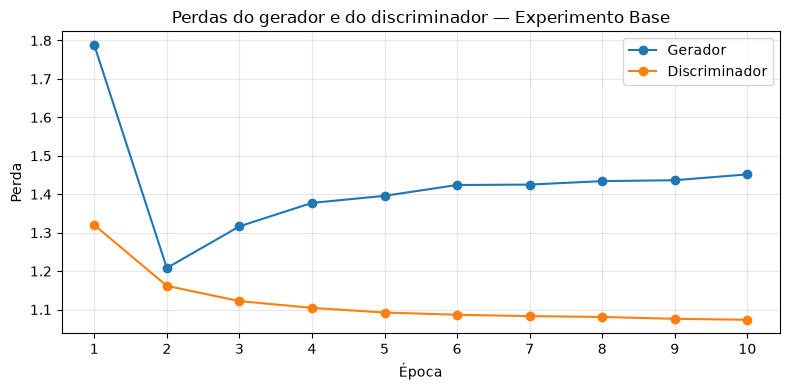

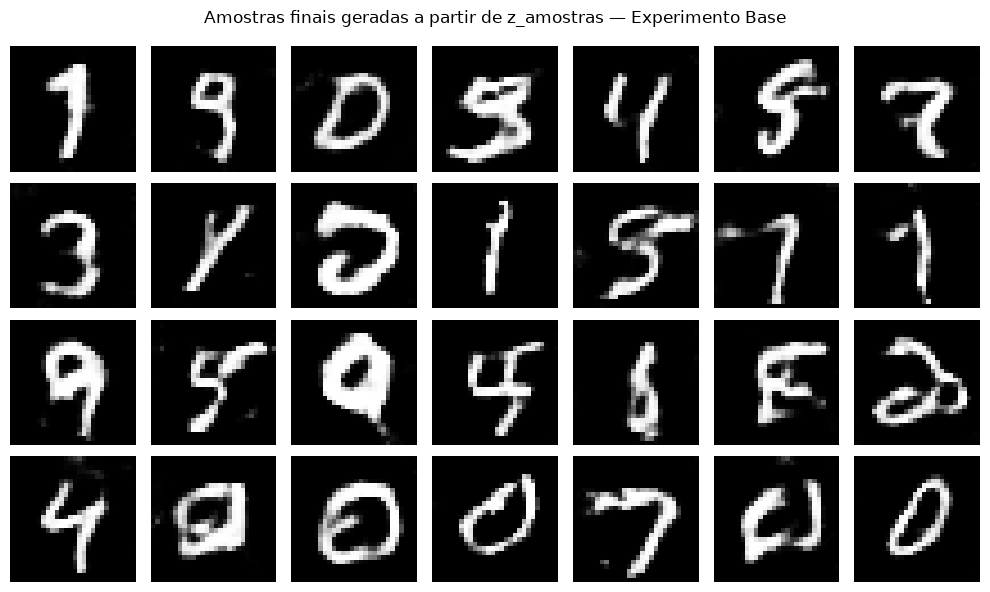

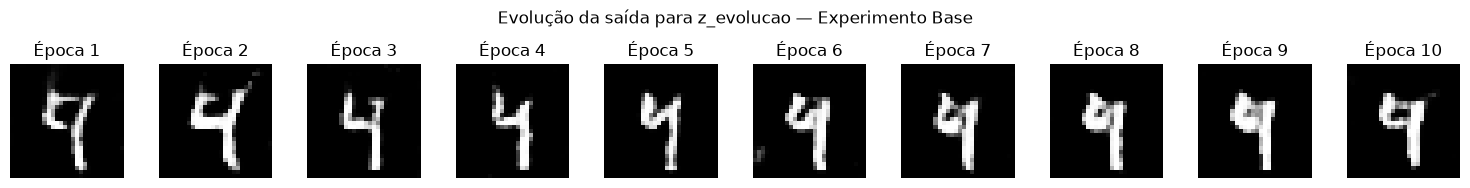

In [ ]:
visualizar_resultado_experimento(resultados["base"])

#### 2.10.3. Visualização de todos os experimentos


Experimento: Gerador reduzido (gerador_reduzido)


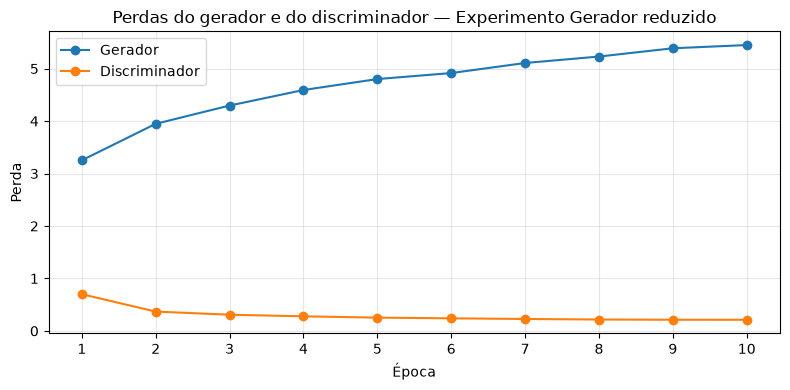

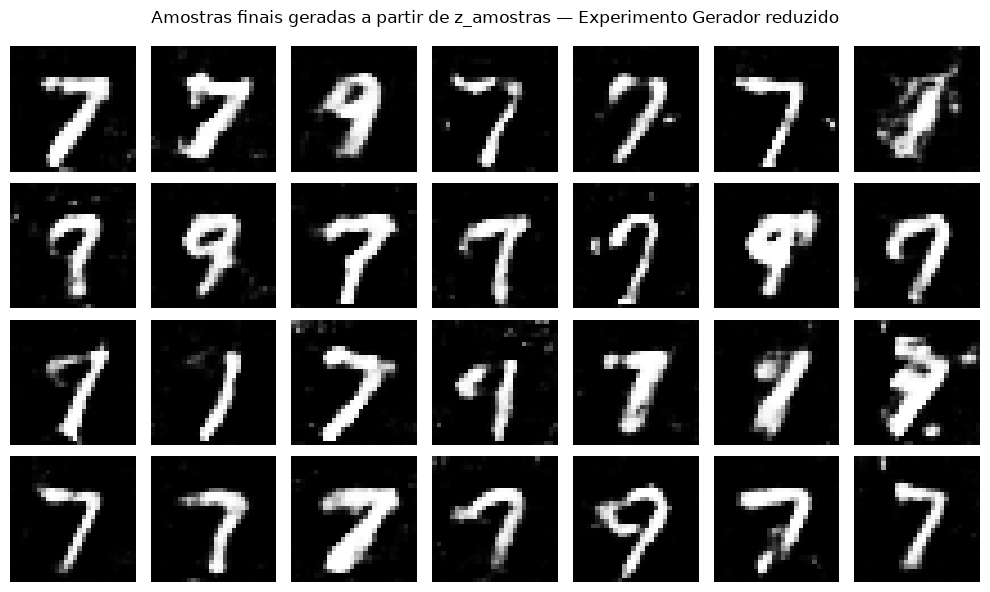

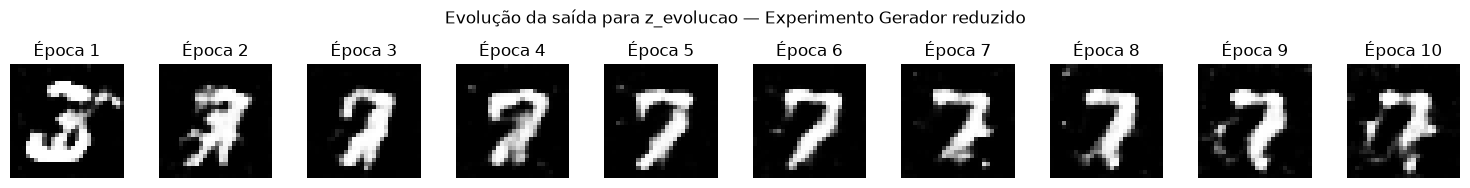


Experimento: Gerador ampliado (gerador_ampliado)


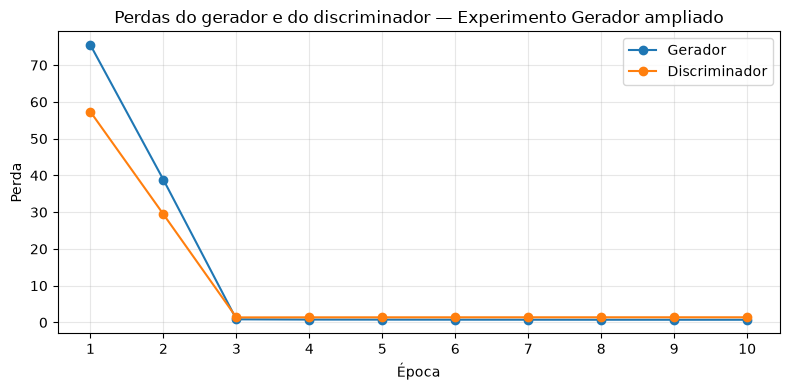

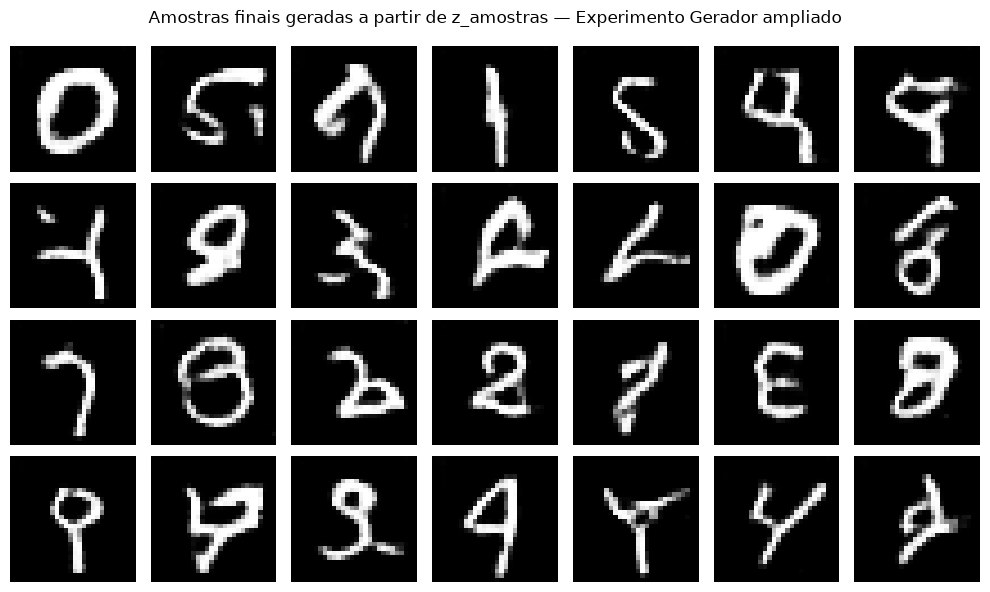

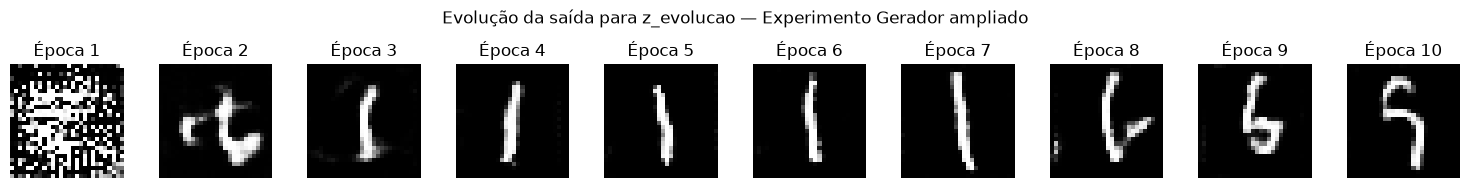


Experimento: Discriminador reduzido (discriminador_reduzido)


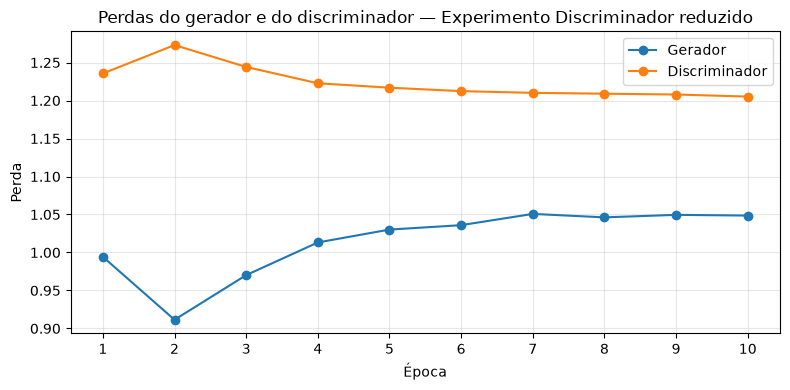

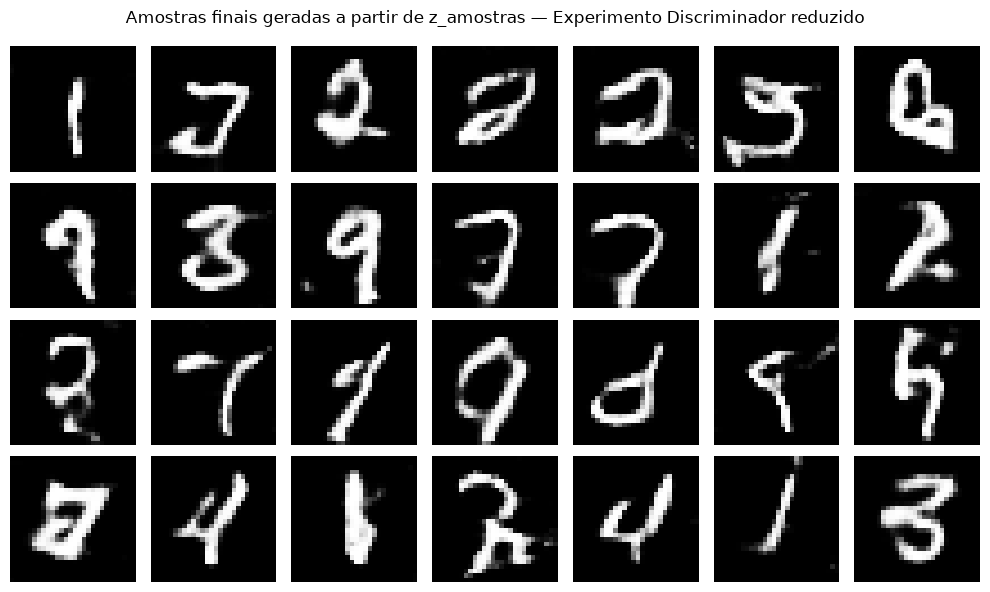

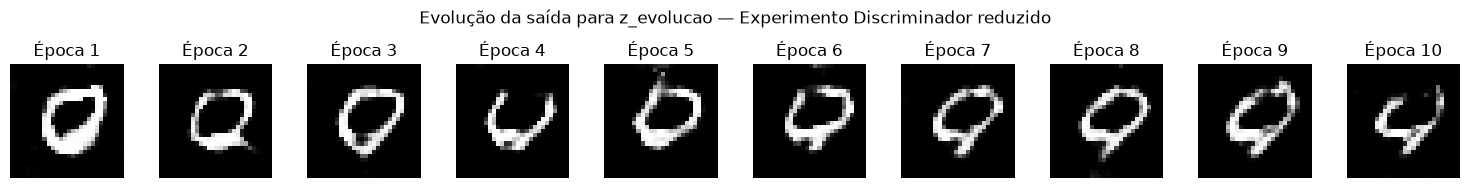


Experimento: Discriminador ampliado (discriminador_ampliado)


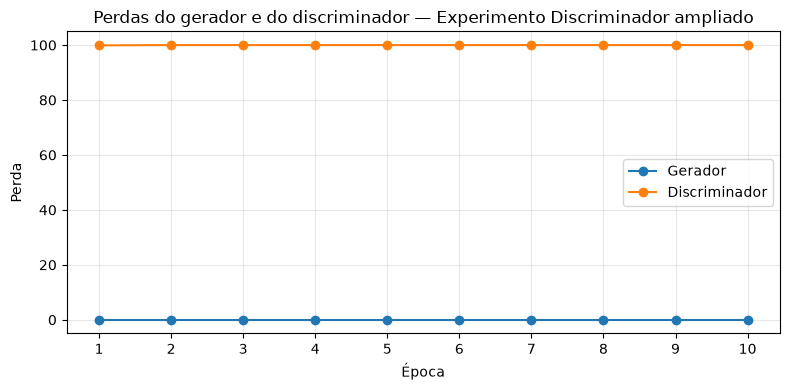

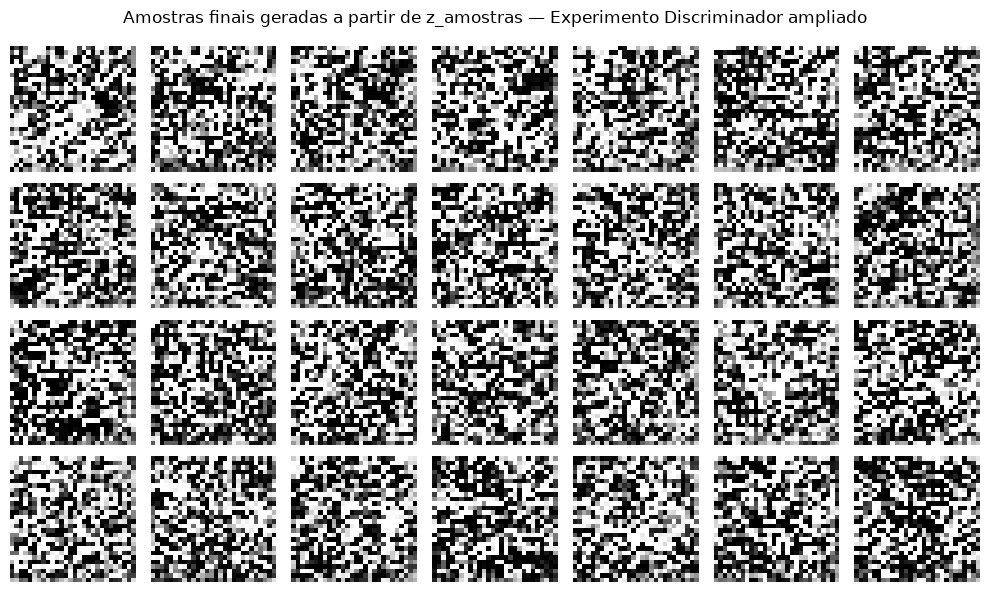

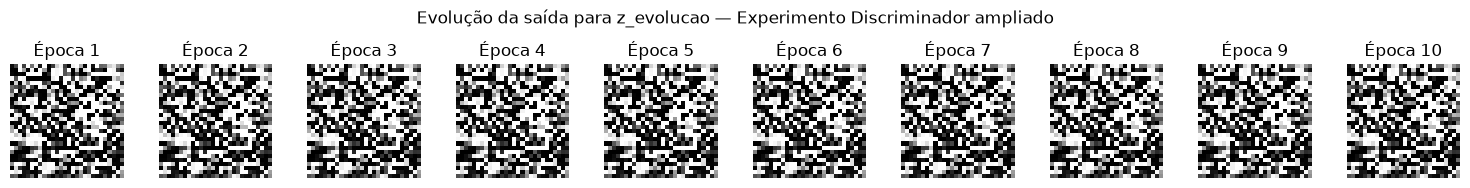


Experimento: Gerador e discriminador ampliados (ambos_ampliados)


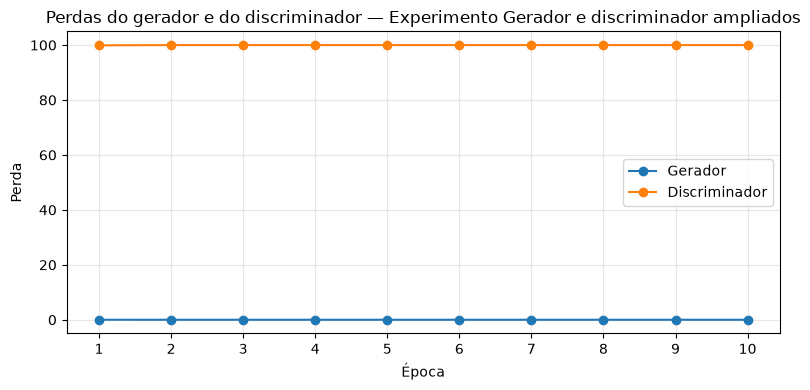

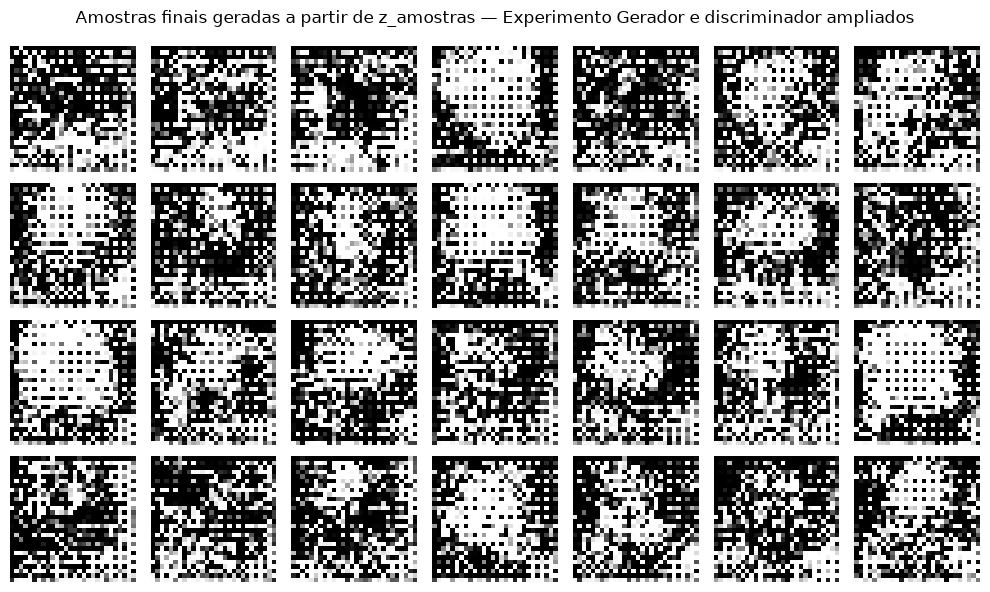

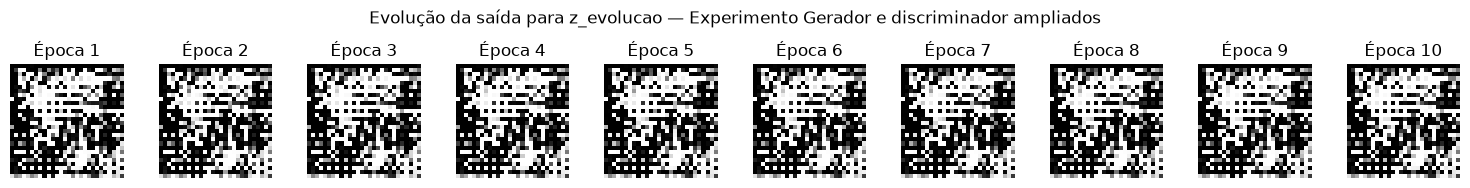


Experimento: LR gerador >> discriminador (lr_gerador_maior)


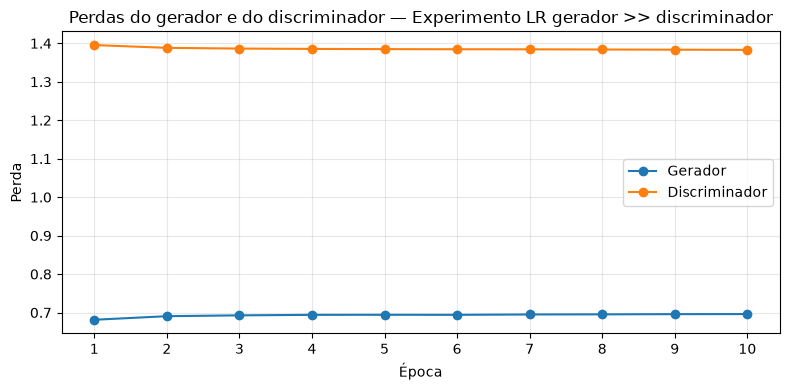

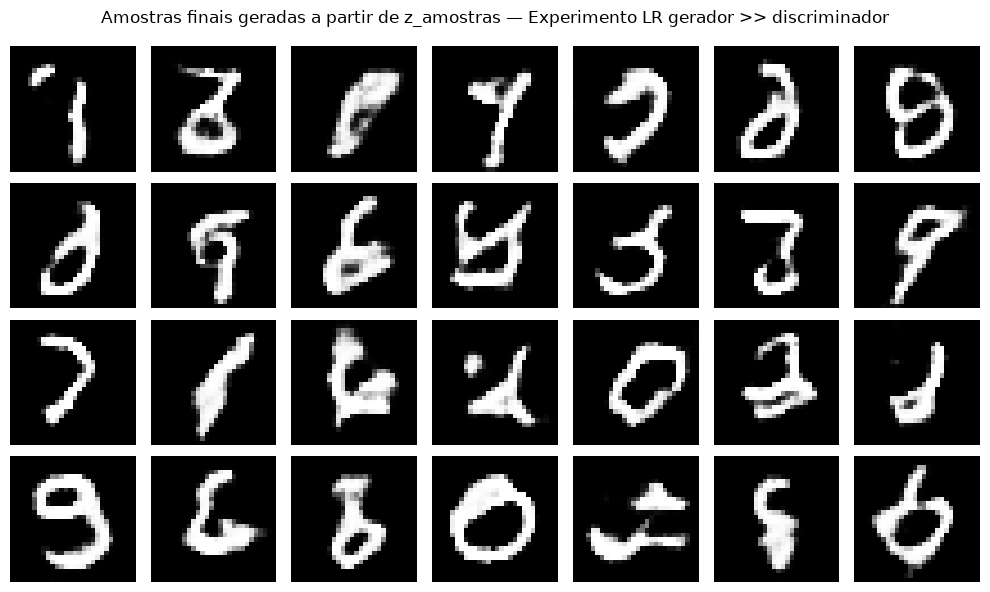

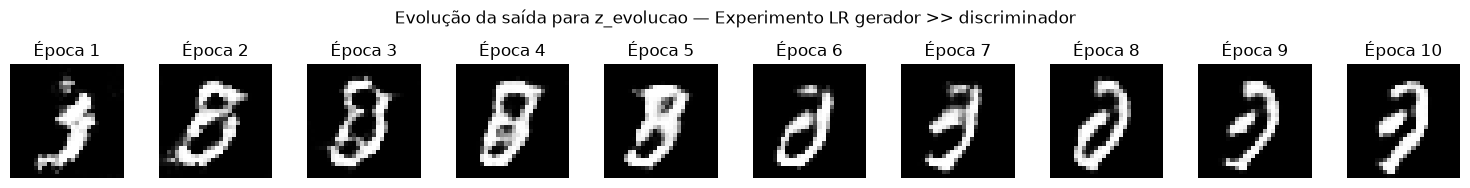


Experimento: LR gerador << discriminador (lr_discriminador_maior)


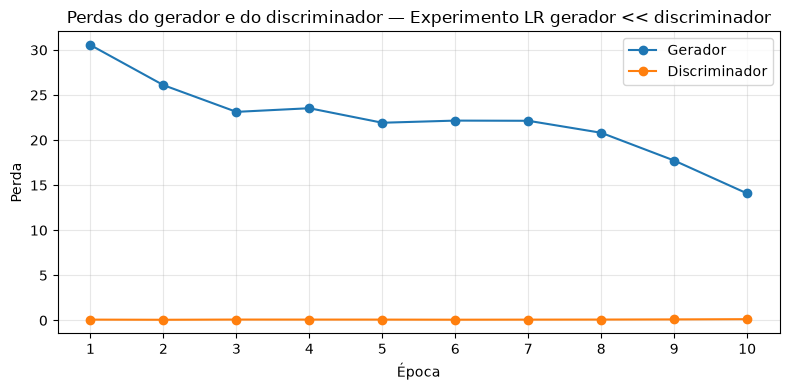

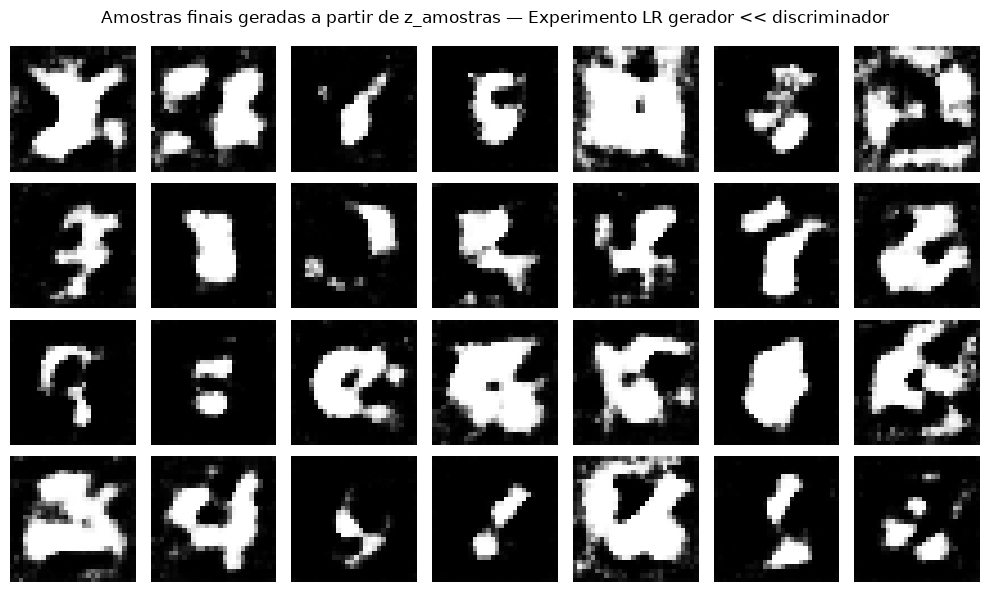

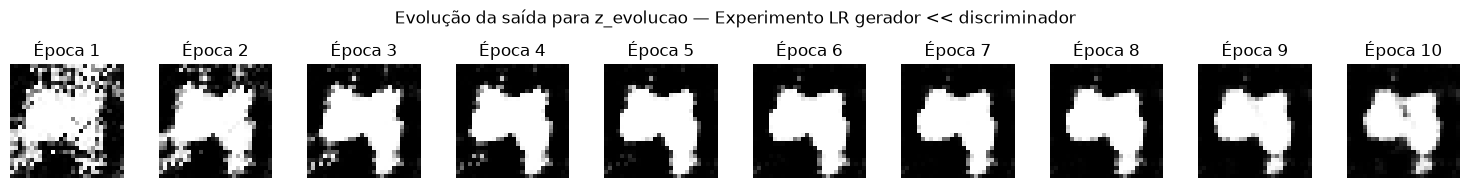


Experimento: LR ambos menores (lr_ambos_menores)


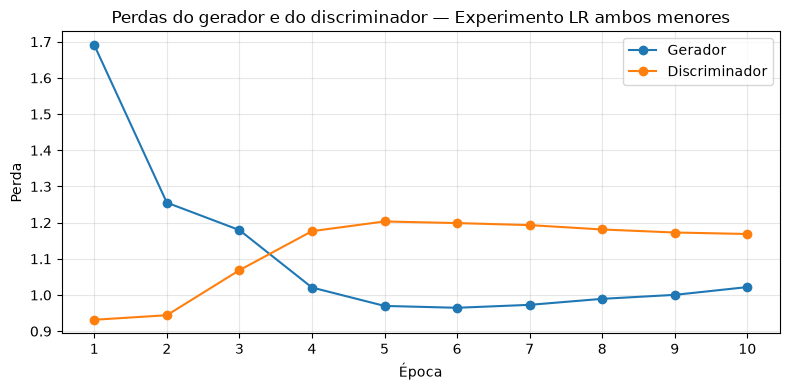

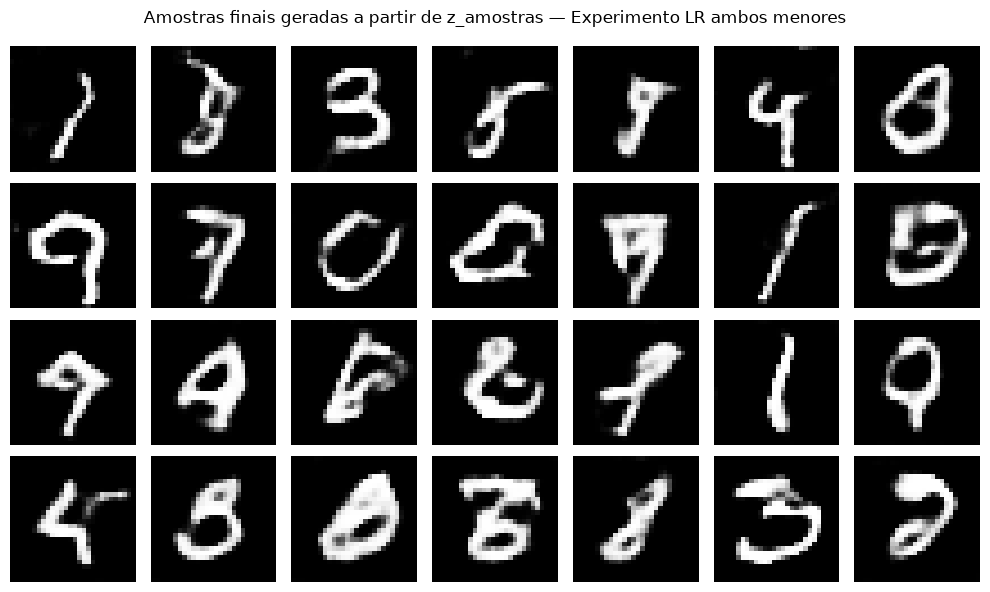

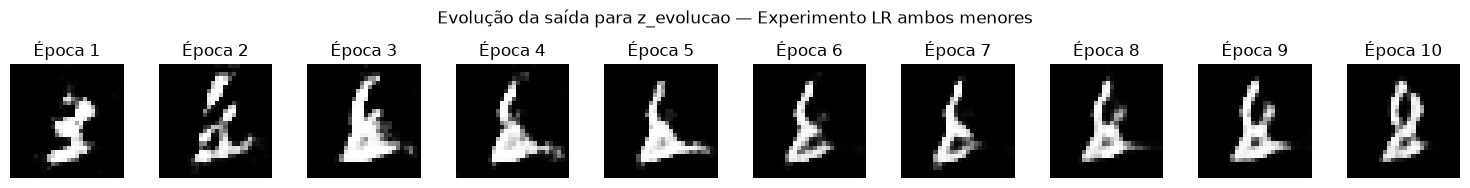


Experimento: SGD (sgd)


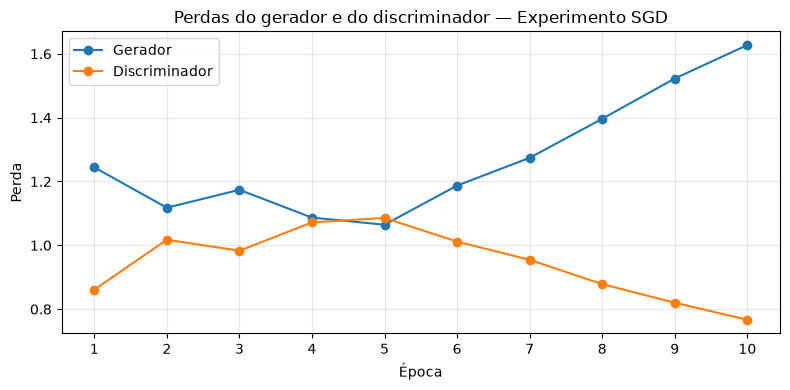

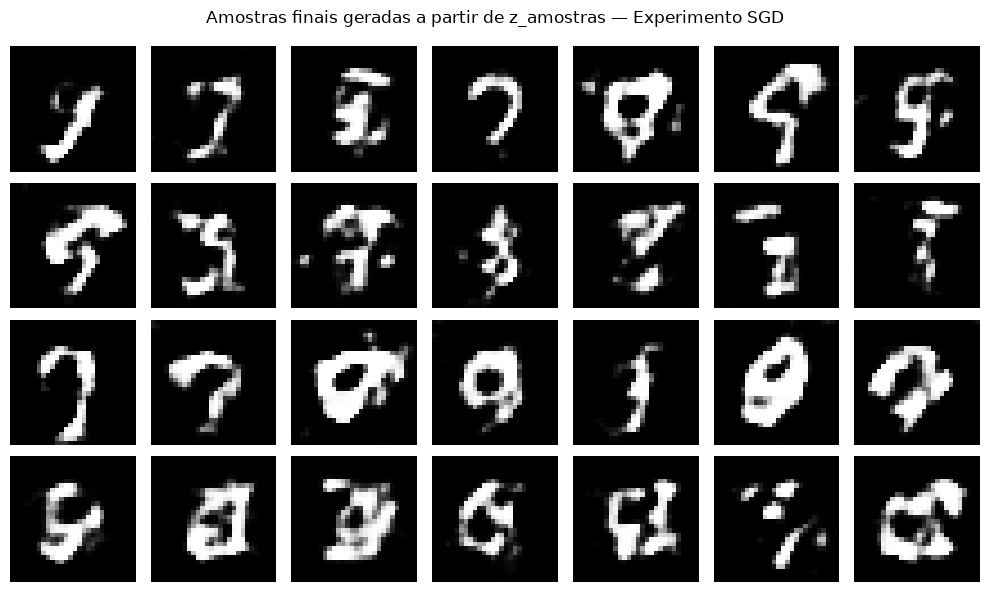

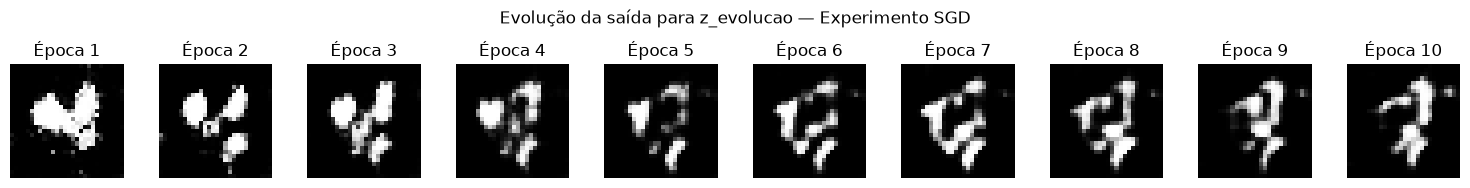

In [ ]:
for id_experimento, resultado in resultados.items():

    # O experimento base ja foi visualizado na validação
    if id_experimento == "base":
        continue

    print()
    print("=" * 80)
    print(f"Experimento: {resultado['config']['nome']} ({id_experimento})")
    print("=" * 80)

    visualizar_resultado_experimento(resultado)

### 2.11. Interpolações

#### 2.11.1. Reconstrução do gerador final

In [ ]:
def carregar_gerador_final(id_experimento, config, device):
    caminhos = obter_caminhos_experimento(id_experimento)

    checkpoint = torch.load(
        caminhos["checkpoint_final"],
        map_location="cpu",
        weights_only=False
    )

    assert checkpoint["id_experimento"] == id_experimento
    assert checkpoint["config"] == config

    gerador = Gerador(**config["gerador"])
    gerador.load_state_dict(checkpoint["gerador_state_dict"])
    gerador = gerador.to(device)
    gerador.eval()

    return gerador

#### 2.11.2. Interpolação entre `z_interp_1` e `z_interp_2`

In [ ]:
def interpolar_vetores_latentes(
    z_interp_1,
    z_interp_2,
    n_passos
):
    alphas = torch.linspace(
        0.0,
        1.0,
        steps=n_passos
    ).unsqueeze(1)

    return (
        (1.0 - alphas) * z_interp_1 +
        alphas * z_interp_2
    )

#### 2.11.3. Geração das imagens interpoladas

In [ ]:
def gerar_interpolacao(
    gerador,
    z_interp_1,
    z_interp_2,
    n_passos,
    device
):
    z_interpolados = interpolar_vetores_latentes(
        z_interp_1=z_interp_1,
        z_interp_2=z_interp_2,
        n_passos=n_passos
    )

    imagens = gerar_saida(
        gerador=gerador,
        z=z_interpolados,
        device=device
    )

    return imagens

#### 2.11.4. Visualização da interpolação

In [ ]:
def plotar_interpolacao(
    imagens,
    nome_experimento
):
    plt.figure(figsize=(20, 2))

    for indice, imagem in enumerate(imagens):
        plt.subplot(1, len(imagens), indice + 1)

        plt.imshow(
            preparar_imagem_para_plot(imagem),
            cmap="gray",
            vmin=0,
            vmax=1
        )

        plt.axis("off")

    plt.suptitle(
        f"Interpolação entre z_interp_1 e z_interp_2 — Experimento {nome_experimento}",
        y=1.02
    )

    plt.tight_layout()
    plt.show()

#### 2.11.5. Validação com o experimento base

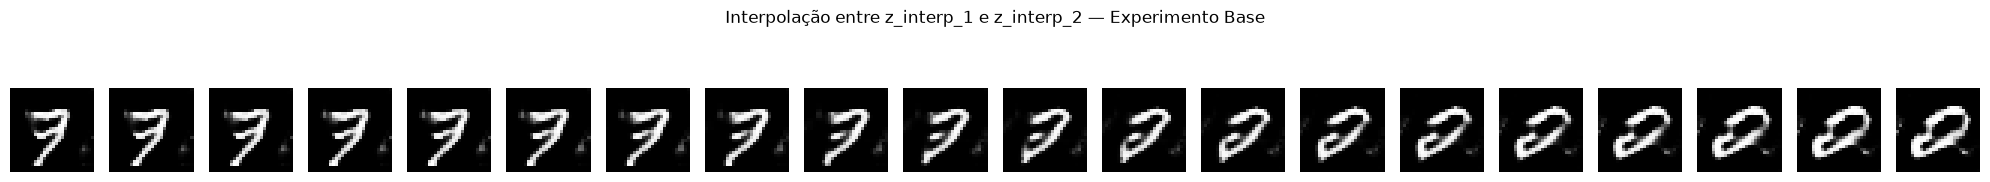

In [ ]:
gerador_base = carregar_gerador_final(
    id_experimento="base",
    config=experimentos["base"],
    device=device
)

imagens_interpolacao_base = gerar_interpolacao(
    gerador=gerador_base,
    z_interp_1=z_interp_1,
    z_interp_2=z_interp_2,
    n_passos=n_passos_interpolacao,
    device=device
)

assert imagens_interpolacao_base.shape == (
    n_passos_interpolacao,
    1,
    28,
    28
)

assert imagens_interpolacao_base.device.type == "cpu"

plotar_interpolacao(
    imagens=imagens_interpolacao_base,
    nome_experimento=experimentos["base"]["nome"]
)

#### 2.11.6. Interpolação para todos os experimentos

In [ ]:
interpolacoes = {}

for id_experimento, resultado in resultados.items():

    # O experimento base ja foi visualizado na validação
    if id_experimento == "base":
        continue
    
    gerador = carregar_gerador_final(
        id_experimento=id_experimento,
        config=resultado["config"],
        device=device
    )

    imagens_interpolacao = gerar_interpolacao(
        gerador=gerador,
        z_interp_1=z_interp_1,
        z_interp_2=z_interp_2,
        n_passos=n_passos_interpolacao,
        device=device
    )

    assert imagens_interpolacao.shape == (
        n_passos_interpolacao,
        1,
        28,
        28
    )

    assert imagens_interpolacao.device.type == "cpu"

    interpolacoes[id_experimento] = imagens_interpolacao

#### 2.11.7. Visualização das interpolações de todos os experimentos


Experimento: Gerador reduzido (gerador_reduzido)


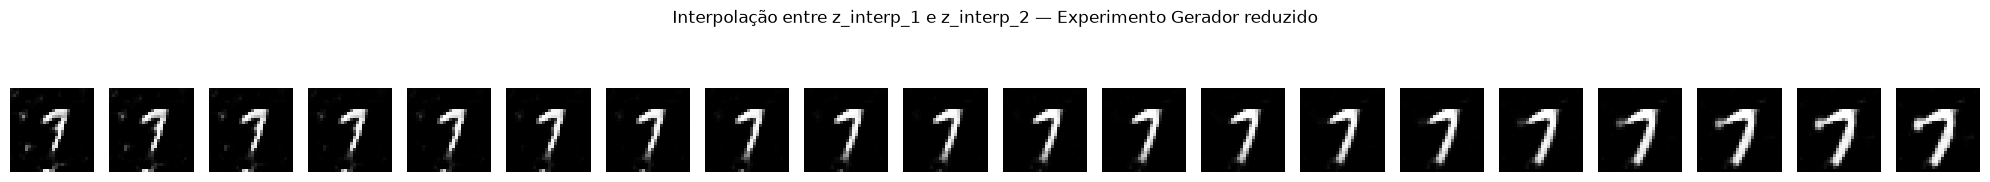


Experimento: Gerador ampliado (gerador_ampliado)


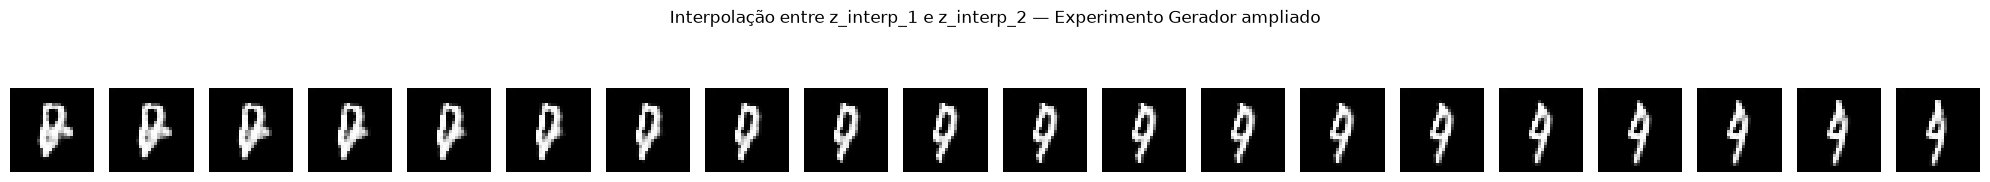


Experimento: Discriminador reduzido (discriminador_reduzido)


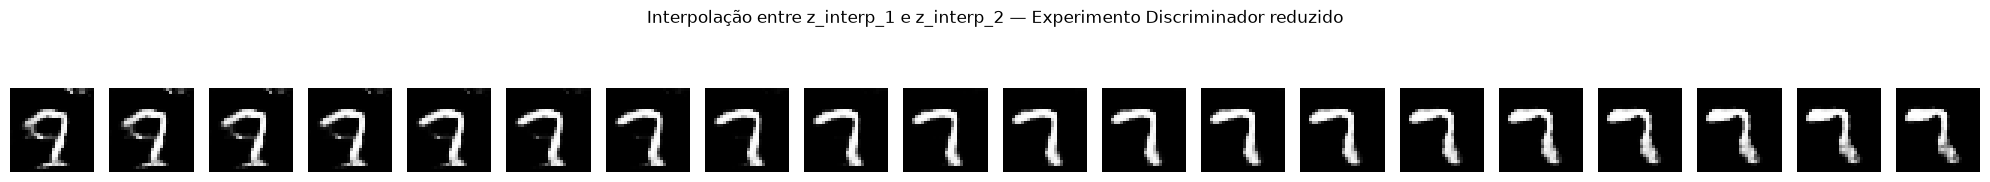


Experimento: Discriminador ampliado (discriminador_ampliado)


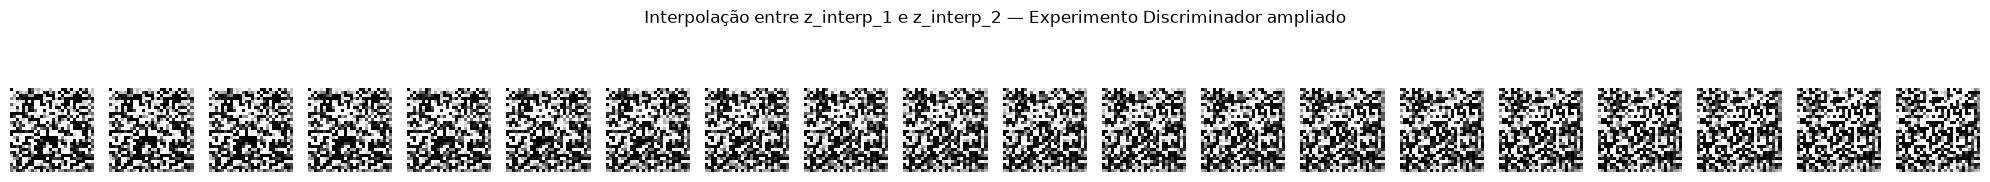


Experimento: Gerador e discriminador ampliados (ambos_ampliados)


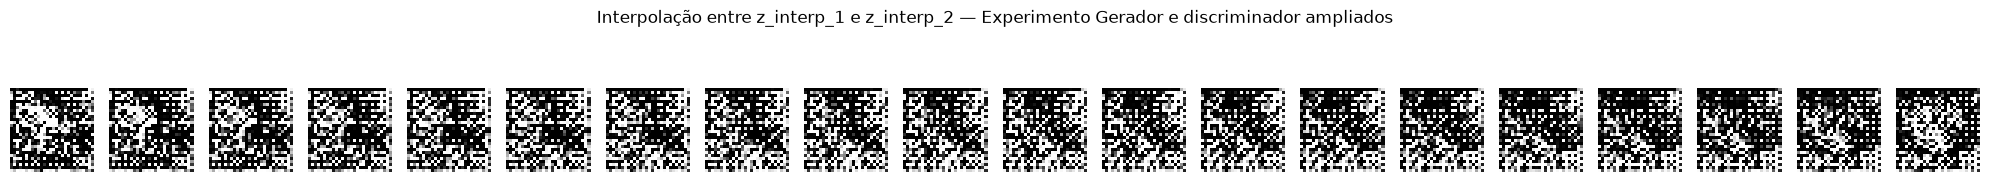


Experimento: LR gerador >> discriminador (lr_gerador_maior)


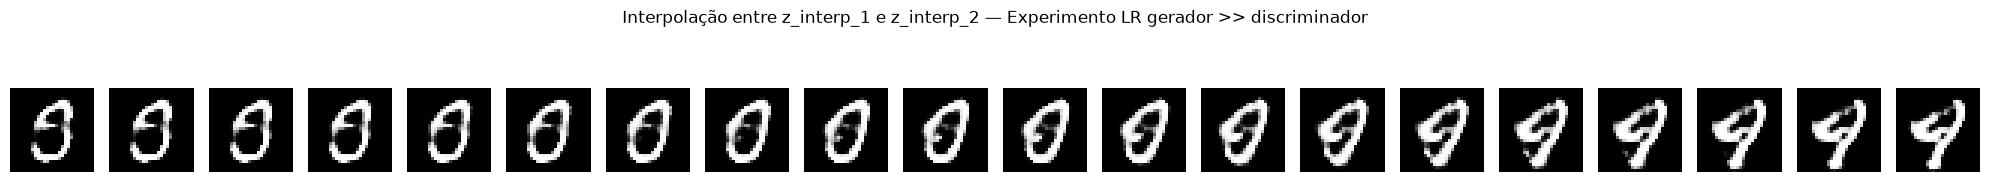


Experimento: LR gerador << discriminador (lr_discriminador_maior)


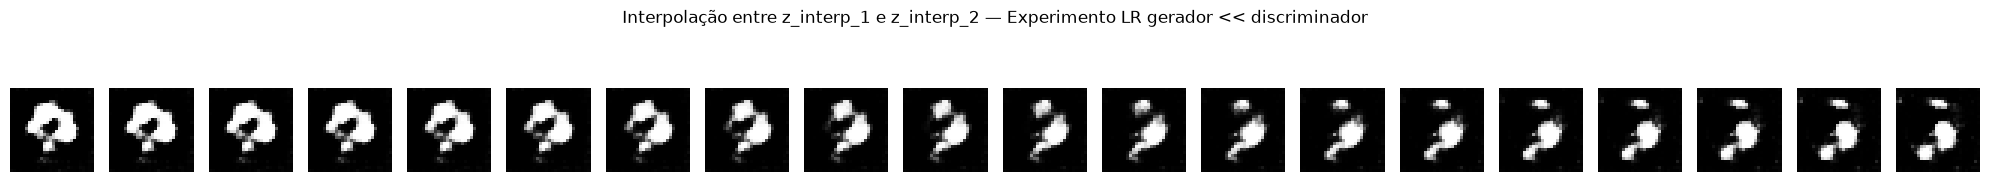


Experimento: LR ambos menores (lr_ambos_menores)


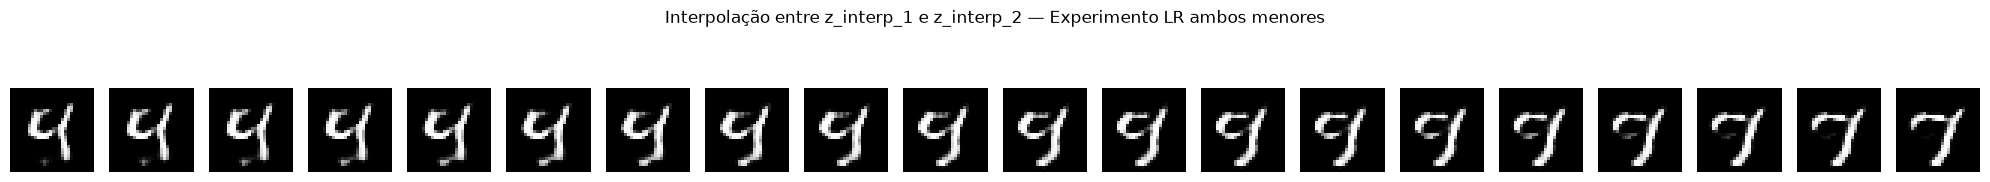


Experimento: SGD (sgd)


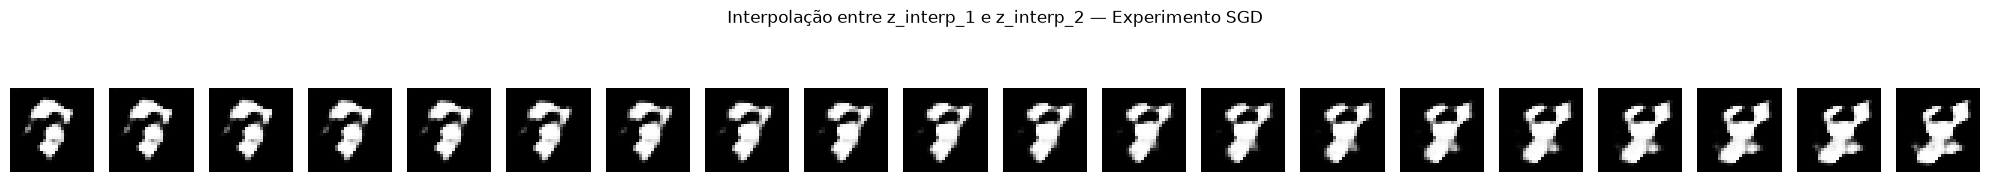

In [ ]:
for id_experimento, imagens_interpolacao in interpolacoes.items():

    nome_experimento = resultados[id_experimento]["config"]["nome"]

    print()
    print("=" * 80)
    print(f"Experimento: {nome_experimento} ({id_experimento})")
    print("=" * 80)

    plotar_interpolacao(
        imagens=imagens_interpolacao,
        nome_experimento=nome_experimento
    )

### 2.12. Resumo dos experimentos

#### 2.12.1. Criação de uma tabela resumindo os experimentos

In [ ]:
def criar_tabela_resumo(resultados):
    linhas = []

    for id_experimento, resultado in resultados.items():
        config = resultado["config"]
        config_treinamento = config["treinamento"]
        historico = resultado["historico"]

        gerador = Gerador(**config["gerador"])
        discriminador = Discriminador(**config["discriminador"])

        linhas.append({
            "Experimento": config["nome"],
            "Parâmetros G": contar_parametros(gerador),
            "Parâmetros D": contar_parametros(discriminador),
            "Otimizador": config_treinamento["otimizador"],
            "LR G": config_treinamento["lr_gerador"],
            "LR D": config_treinamento["lr_discriminador"],
            "Loss G final": historico["loss_gerador"][-1],
            "Loss D final": historico["loss_discriminador"][-1],
            "Score reais final": historico["score_reais"][-1],
            "Score falsos final": historico["score_falsos"][-1]
        })

    return pd.DataFrame(linhas)

#### 2.12.2. Exibição do resumo dos experimentos

In [ ]:
tabela_resumo = criar_tabela_resumo(resultados)

display(
    tabela_resumo.style
        .hide(axis="index")
        .format({
            "Parâmetros G": "{:,.0f}",
            "Parâmetros D": "{:,.0f}",
            "LR G": "{:.0e}",
            "LR D": "{:.0e}",
            "Loss G final": "{:.4f}",
            "Loss D final": "{:.4f}",
            "Score reais final": "{:.4f}",
            "Score falsos final": "{:.4f}"
        })
)

Experimento,Parâmetros G,Parâmetros D,Otimizador,LR G,LR D,Loss G final,Loss D final,Score reais final,Score falsos final
Base,"840,321","212,865",RMSprop,1e-03,1e-03,1.4517,1.0734,0.6620,0.3387
Gerador reduzido,"159,233","212,865",RMSprop,1e-03,1e-03,5.4494,0.2124,0.9500,0.0504
Gerador ampliado,"3,567,105","212,865",RMSprop,1e-03,1e-03,0.7260,1.3988,0.5044,0.4958
Discriminador reduzido,"840,321","42,225",RMSprop,1e-03,1e-03,1.0486,1.2052,0.5934,0.4064
Discriminador ampliado,"840,321","906,561",RMSprop,1e-03,1e-03,0.0000,100.0000,1.0000,1.0000
Gerador e discriminador ampliados,"3,567,105","906,561",RMSprop,1e-03,1e-03,0.0000,100.0000,1.0000,1.0000
LR gerador >> discriminador,"840,321","212,865",RMSprop,1e-03,1e-05,0.6961,1.3829,0.5012,0.4989
LR gerador << discriminador,"840,321","212,865",RMSprop,1e-05,1e-03,14.0794,0.1319,0.9742,0.0260
LR ambos menores,"840,321","212,865",RMSprop,1e-04,1e-04,1.0220,1.1687,0.5944,0.4070
SGD,"840,321","212,865",SGD,1e-03,1e-03,1.6274,0.7667,0.7298,0.2708


## **Seção 3 — WGAN condicional**

### 3.1. Preparações preliminares

#### 3.1.1. Instalar bibliotecas necessárias

In [ ]:
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib
!pip install scikit-learn

#### 3.1.2. Importações

In [ ]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader do PyTorch, que facilita o carregamento de dados em mini-lotes (batches).
import torch.nn.functional as F             # Importa funções comuns de ativação e perda do PyTorch, usadas fora do módulo nn.Module (ex.: ReLU, cross_entropy, etc.)
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
import random                               # Importa o módulo random para gerar números aleatórios.
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Ajusta a variável de ambiente para evitar erros ao carregar múltiplas bibliotecas MKL

#### 3.1.3. Configuração de matplotlib

In [ ]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

#### 3.1.4. Configuração de reprodutibilidade

In [ ]:

SEED = 42

random.seed(SEED)       # Define a semente aleatória para o Python
np.random.seed(SEED)    # Define a semente aleatória para o NumPy
torch.manual_seed(SEED) # Define a semente aleatória para o PyTorch

# Se o dispositivo for CUDA, define a semente aleatória para o dispositivo CUDA
# Para MPS não é necessário nenhuma outro ajuste da semente aleatória.
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

### 3.2. Preparação dos Dados

#### 3.2.1. Download dos datasets de treino e teste para Fashion MNIST

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Baixa os dados de treinamento a partir de conjuntos de dados públicos
training_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=True,              # Indica que este é o conjunto de dados de treinamento
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

# Baixa os dados de teste a partir de conjuntos de dados públicos
test_data = datasets.FashionMNIST(
    root="data",             # Diretório onde os dados serão armazenados
    train=False,             # Indica que este é o conjunto de dados de teste
    download=True,           # Baixa os dados automaticamente, caso ainda não estejam presentes
    transform=transform,     # Aplica a transformação ToTensor para converter as imagens em tensores
)

#### 3.2.2. Exibir alguns exemplos dos dados

Vamos mostrar um exemplo de cada classe, facilitando a compreensão basica dos dados. 

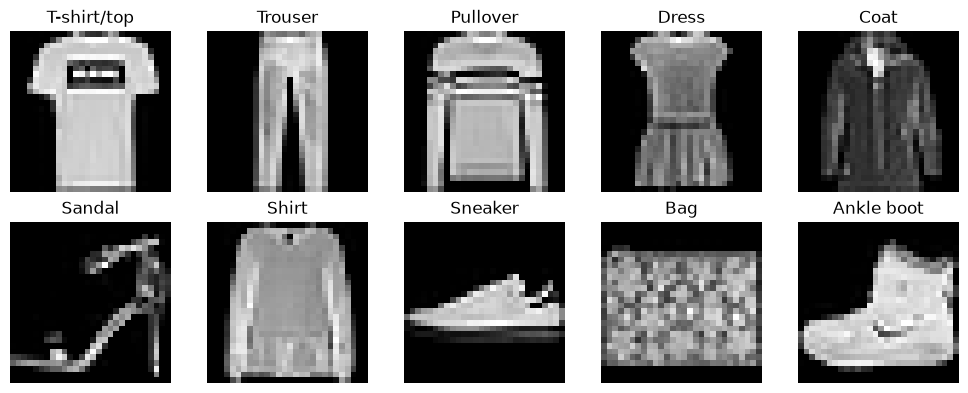

In [ ]:
# Lista com os nomes das classes do conjunto de dados Fashion MNIST, na mesma ordem dos índices
classes = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Dicionário para armazenar um exemplo por classe
examples = {}

# Itera sobre o dataset até obter um exemplo de cada classe
for img, label in training_data:
    if label not in examples:
        examples[label] = img.squeeze()  # remove o canal extra (1, 28, 28) -> (28, 28)
    if len(examples) == 10:
        break

# Plota os exemplos
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(examples[i], cmap="gray")
    plt.title(classes[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

#### 3.2.3. Criação dos DataLoaders

A seguir criaremos os DataLoaders para os dois conjuntos de dados (treino e teste). Utilizaremos um gerador de dados aleatórios independente para facilitar a reprodutibilidade do experimento.

In [ ]:
# Define um gerador de dados aleatórios específico para o dataloader, 
# assim deixamos explicito que o gerador de dados aleatórios do Dataloader
# é independente do gerador de dados aleatórios global do sistema (e do modelo).

data_generator = torch.Generator()
data_generator.manual_seed(SEED)

batch_size = 64                                                                                     # Define o tamanho do lote
train_dataloader = DataLoader(
    training_data, 
    batch_size=batch_size, 
    shuffle=True, 
    drop_last=True, 
    generator=data_generator)   # Cria o DataLoader para o conjunto de treinamento

# não precisa do generator, pois o test_data não é embaralhado
test_dataloader = DataLoader(
    test_data, 
    batch_size=batch_size)      # Cria o DataLoader para o conjunto de teste

# Itera sobre o DataLoader de teste para visualizar as formas dos dados
for X, y in test_dataloader:
    # Exibe a forma e o tipo do tensor de imagens
    # N = tamanho do lote, C = canais (1 para imagens em tons de cinza), H = altura, W = largura
    print(f"Forma de X [N, C, H, W]: {X.shape}, Tipo de dados em X: {X.dtype}")

    # Exibe a forma e o tipo dos rótulos (labels)
    print(f"Forma de y [N, ] : {y.shape}, Tipo de dados em y: {y.dtype}")

    break  # Encerra o loop após a primeira iteração, apenas para inspeção dos dados

Forma de X [N, C, H, W]: torch.Size([64, 1, 28, 28]), Tipo de dados em X: torch.float32
Forma de y [N, ] : torch.Size([64]), Tipo de dados em y: torch.int64


### 3.3. Definição das Redes Neurais

#### 3.3.1. Gerador

In [ ]:
class Gerador(nn.Module):

    def __init__(self, z_dim=100, n_classes=10):
        super().__init__()
        self.z_dim = z_dim
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Linear(z_dim+n_classes, 7*7*128),
            nn.Unflatten(dim=1, unflattened_size=(128, 7, 7)),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.ReLU(True),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Tanh()
        )

    def forward(self, x, labels):
        # Se labels contém índices de classe, converte para one-hot.
        # Isso vai permitir que o gerador use indices das classes ou one-hot encoding.
        # No segundo caso não precisamos transformar em one-hot novamente.
        if labels.dim() == 1:
            labels = F.one_hot(
                labels,
                num_classes=self.n_classes
            ).float()

        # Concatena o vetor de ruído com o vetor de rótulos
        x = torch.cat((x, labels), dim=1)

        return self.net(x)

#### 3.3.2. Crítico

In [ ]:
class Critico(nn.Module):

    def __init__(self, n_classes=10):
        super().__init__()
        self.n_classes = n_classes
        self.net = nn.Sequential(
            nn.Conv2d(1+n_classes, 64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(p=0.4),
            nn.Conv2d(64, 128, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(negative_slope=0.2),
            nn.Dropout(p=0.4),
            nn.Flatten(),
            nn.Linear(7*7*128, 1),
        )

    def forward(self, x, labels):

        # Durante o treinamento, os rótulos chegam normalmente como índices inteiros,
        # por exemplo: [2, 5, 1, ...]. Nesse caso, convertemos cada índice para um
        # vetor one-hot com uma posição para cada uma das 10 classes.
        if labels.dim() == 1:
            labels = F.one_hot(
                labels,
                num_classes=self.n_classes
            ).float()

        # Neste ponto, cada rótulo é representado por um vetor com n_classes valores:
        #
        #   [batch_size, n_classes]
        #
        # Como a entrada do crítico é uma imagem, precisamos transformar esse vetor
        # em canais adicionais que tenham a mesma altura e largura da imagem.
        #
        # Primeiro adicionamos duas dimensões espaciais:
        #
        #   [batch_size, n_classes]
        #                ↓
        #   [batch_size, n_classes, 1, 1]
        labels = labels[:, :, None, None]

        # Em seguida, expandimos cada valor do vetor de classe por toda a imagem.
        #
        # Por exemplo, para a classe 2:
        #
        #   [0, 0, 1, 0, ..., 0]
        #
        # teremos 10 canais 28x28:
        # - canais 0, 1, 3, ..., 9 preenchidos com 0;
        # - canal 2 preenchido com 1.
        #
        # Assim:
        #
        #   [batch_size, n_classes, 1, 1]
        #                ↓
        #   [batch_size, n_classes, 28, 28]
        
        labels = labels.expand(
            -1,
            -1,
            x.shape[2], #   x tem shape (batch_size, 1, 28, 28)
            x.shape[3]  #   x tem shape (batch_size, 1, 28, 28)
        )

        # Agora concatenamos os canais que representam a classe com o canal da imagem.
        #
        # imagem (x):
        #   [batch_size, 1, 28, 28]
        #
        # classe (labels):
        #   [batch_size, 10, 28, 28]
        #
        # entrada final do crítico:
        #   [batch_size, 11, 28, 28]
        #
        x = torch.cat((x, labels), dim=1)

        return self.net(x)

### 3.4. Treinamento

#### 3.4.1. Função de treinamento

Primeiro definimos a função responsável pelo treinamento do gerador e do crítico.

In [ ]:
def train_wgan(dataloader, gerador, critico, opt_gerador, opt_critico, device, epoch, z_dim, n_critic=5, clip_value=0.01):
    # Coloca o modelo em modo de treinamento
    gerador.train()
    critico.train()

    # Acumuladores usados para calcular as perdas médias da época.
    soma_perda_critico = 0.0
    soma_perda_gerador = 0.0
    num_passos_critico = 0

    # diferente do exemplo do professor, agora queremos os labels que o dataloader 
    # retorna para poder usar no treinamento condicional
    for batch, (real_data, labels) in enumerate(dataloader):
        batch_size = real_data.shape[0]
        real_data = real_data.to(device)
        labels = labels.to(device)

        # ========================================
        # Treinamento do CRÍTICO (n_critic vezes)
        # ========================================
        for _ in range(n_critic):
            # gera ruido aleatorio para o gerador
            z = torch.randn((batch_size, z_dim), device=device)
            # gera dados falsos com o gerador, adicionando os labels
            dados_falsos = gerador(z, labels).detach()

            # calcula a saida do critico para os dados reais e falsos, também usando os labels
            saida_reais = critico(real_data, labels)
            saida_falsos = critico(dados_falsos, labels)

            # calcula a perda do critico
            perda_critico = saida_falsos.mean() - saida_reais.mean()

            # calcula o gradiente da perda do critico
            opt_critico.zero_grad()
            perda_critico.backward()
            opt_critico.step()

            # Clipping dos pesos do crítico para satisfazer Lipschitz
            for p in critico.parameters():
                p.data.clamp_(-clip_value, clip_value)

            # Acumula todas as perdas dos passos do crítico.
            soma_perda_critico += perda_critico.item()
            num_passos_critico += 1            

        # ========================================
        # Treinamento do GERADOR (1 vez)
        # ========================================
        # gera ruido aleatorio para o gerador
        z = torch.randn((batch_size, z_dim), device=device)
        # gera dados falsos com o gerador, adicionando os labels
        dados_falsos = gerador(z, labels)
        # calcula a saida do critico para os dados falsos, também usando os labels
        saida_falsos = critico(dados_falsos, labels)

        # calcula a perda do gerador
        perda_gerador = -saida_falsos.mean()

        # calcula o gradiente da perda do gerador
        opt_gerador.zero_grad()
        perda_gerador.backward()
        opt_gerador.step()

        # Acumula uma perda do gerador para cada batch.
        soma_perda_gerador += perda_gerador.item()
        
        # ========================================
        # Log
        # ========================================
        if batch % 100 == 0 or batch == len(dataloader) - 1:
            print(
                f"[Época {epoch:03d}] "
                f"[Lote {batch:03d}/{len(dataloader)}] "
                f"Perda Crítico: {perda_critico.item():.4f} | "
                f"Perda Gerador: {perda_gerador.item():.4f}"
            )

    # Calcula as perdas médias da época.
    media_perda_critico = soma_perda_critico / num_passos_critico
    media_perda_gerador = soma_perda_gerador / len(dataloader)

    return media_perda_critico, media_perda_gerador

#### 3.4.2. Função de geração de dados a partir do gerador

Na sequencia, definimos uma função auxiliar que gera os dados a partir do gerador (em modo eval). Adaptamos a versão original do professor para suportar tanto a geração a partir de zeros (como no codigo original), quanto a utilização de labels e vetores latentes específicos. Tal flexibilidade foi adicionada para facilitar a criação de dados nas etapas posteriores ao treinamento, onde vamos querer gerar alguns vetores latentes específicos e trabalhar com eles.

In [ ]:
def gerar(gerador, device, z_dim=100, z=None, labels=None):
    # Coloca o modelo em modo de avaliação (desativa dropout, batchnorm, etc.)
    gerador.eval()

    # Se nenhum vetor latente for fornecido, usa um vetor fixo de zeros, como na versão original do código do professor.
    if z is None:
        z = torch.zeros((1, z_dim), device=device)
    else:
        # se o vetor latente for fornecido, garante que ele esteja no mesmo dispositivo em que o modelo está sendo executado.
        z = z.to(device)

    # Se nenhum rótulo for fornecido, sorteia aleatoriamente uma classe.
    # Isso permite gerar uma imagem condicional sem precisar informar explicitamente o rótulo a cada chamada.
    if labels is None:
        labels = torch.randint(0, gerador.n_classes, (1,), device=device)
    else:
        labels = labels.to(device)

    # Desativa o cálculo de gradientes para economizar memória
    # e acelerar a execução, já que estamos apenas gerando imagens.
    with torch.no_grad():
        dados_falsos = gerador(z, labels)

    # Move o resultado para a CPU e converte para NumPy,
    # pois o matplotlib não plota tensores em MPS/GPU diretamente.
    dados_falsos = dados_falsos.cpu().numpy().reshape(28, 28)

    return dados_falsos

#### 3.4.3. Preparação dos modelos para executar o treinamento.

In [ ]:
z_dim = 100
n_classes = len(classes)

# Inicializa os modelos
modelo_gerador = Gerador(z_dim, n_classes=n_classes)
# Inicializa os modelos
modelo_critico = Critico(n_classes=n_classes)

# tenta usar acelerador se disponível
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

modelo_gerador.to(device)
modelo_critico.to(device)

# Exibe qual dispositivo está sendo utilizado
print(f"Usando {device}.")

Usando mps.


#### 3.4.4. Exibe a arquitetura das redes do Gerador e do Critico.

In [ ]:
# Cria entradas apenas para exibir o summary das redes
z_summary = torch.randn((1, z_dim), device=device)
label_summary = torch.tensor([0], device=device)

imagem_summary = torch.randn((1, 1, 28, 28), device=device)

In [ ]:
# Gerador
print(modelo_gerador) # Imprime a arquitetura do modelo
summary(modelo_gerador, input_data=(z_summary, label_summary), device=device)

Gerador(
  (net): Sequential(
    (0): Linear(in_features=110, out_features=6272, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(128, 7, 7))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ConvTranspose2d(64, 1, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2), output_padding=(1, 1))
    (7): Tanh()
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Gerador                                  [1, 1, 28, 28]            --
├─Sequential: 1-1                        [1, 1, 28, 28]            --
│    └─Linear: 2-1                       [1, 6272]                 696,192
│    └─Unflatten: 2-2                    [1, 128, 7, 7]            --
│    └─BatchNorm2d: 2-3                  [1, 128, 7, 7]            256
│    └─ConvTranspose2d: 2-4              [1, 64, 14, 14]           204,864
│    └─ReLU: 2-5                         [1, 64, 14, 14]           --
│    └─BatchNorm2d: 2-6                  [1, 64, 14, 14]           128
│    └─ConvTranspose2d: 2-7              [1, 1, 28, 28]            1,601
│    └─Tanh: 2-8                         [1, 1, 28, 28]            --
Total params: 903,041
Trainable params: 903,041
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 42.11
Input size (MB): 0.00
Forward/backward pass size (MB): 0.31
Params size (MB): 3.61
Estimated Tota

In [ ]:
# Crítico
print(modelo_critico) # Imprime a arquitetura do modelo
summary(modelo_critico, input_data=(imagem_summary, label_summary), device=device)

Critico(
  (net): Sequential(
    (0): Conv2d(11, 64, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.4, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.4, inplace=False)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=6272, out_features=1, bias=True)
  )
)


Layer (type:depth-idx)                   Output Shape              Param #
Critico                                  [1, 1]                    --
├─Sequential: 1-1                        [1, 1]                    --
│    └─Conv2d: 2-1                       [1, 64, 14, 14]           17,664
│    └─LeakyReLU: 2-2                    [1, 64, 14, 14]           --
│    └─Dropout: 2-3                      [1, 64, 14, 14]           --
│    └─Conv2d: 2-4                       [1, 128, 7, 7]            204,928
│    └─LeakyReLU: 2-5                    [1, 128, 7, 7]            --
│    └─Dropout: 2-6                      [1, 128, 7, 7]            --
│    └─Flatten: 2-7                      [1, 6272]                 --
│    └─Linear: 2-8                       [1, 1]                    6,273
Total params: 228,865
Trainable params: 228,865
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 13.51
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.92
Estimated Total S

#### 3.4.5. Definição de Hiperparametros do treinamento.

In [ ]:
# Otimizadores
lr_gerador = 1e-4   # taxa de aprendizagem do gerador
lr_critico = 1e-4   # taxa de aprendizagem do crítico
optimizador_gerador = torch.optim.RMSprop(modelo_gerador.parameters(), lr=lr_gerador)
optimizador_critico = torch.optim.RMSprop(modelo_critico.parameters(), lr=lr_critico)

# Hyper-parametros
clip_value = 0.01
n_critic = 5

#### 3.4.6. Execução do laço principal de treinamento

In [ ]:
num_epochs = 100  # Define o número total de épocas (iterações completas sobre o conjunto de dados de treinamento)
evolucao_dado_falso = []
epocas_evolucao = []

historico_perda_critico = []
historico_perda_gerador = []

# Vetor latente fixo usado para acompanhar a evolução
# da mesma amostra durante todo o treinamento.
z_fixo = torch.randn((1, z_dim), device=device)

# Classe fixa usada junto com o vetor latente fixo.
classe_fixa = torch.tensor([0], device=device)

for epoca in range(1, num_epochs + 1):
    media_critico, media_gerador = train_wgan(
        dataloader=train_dataloader,
        gerador=modelo_gerador,
        critico=modelo_critico,
        opt_gerador=optimizador_gerador,
        opt_critico=optimizador_critico,
        device=device,
        epoch=epoca,
        z_dim=z_dim,
        n_critic=n_critic,
        clip_value=clip_value
    )
    historico_perda_critico.append(media_critico)
    historico_perda_gerador.append(media_gerador)

    if epoca % 5 == 0 or epoca == 1:
        evolucao_dado_falso.append(
            gerar(
                gerador=modelo_gerador,
                device=device,
                z=z_fixo,
                labels=classe_fixa
            )
        )

        epocas_evolucao.append(epoca)        
        
print("Fim!")  # Exibe mensagem final indicando que o treinamento terminou

[Época 001] [Lote 000/937] Perda Crítico: -0.2075 | Perda Gerador: 0.0515
[Época 001] [Lote 100/937] Perda Crítico: -4.8783 | Perda Gerador: -23.0870
[Época 001] [Lote 200/937] Perda Crítico: -2.5848 | Perda Gerador: -3.8805
[Época 001] [Lote 300/937] Perda Crítico: -1.8720 | Perda Gerador: 1.3367
[Época 001] [Lote 400/937] Perda Crítico: -3.9930 | Perda Gerador: 14.9808
[Época 001] [Lote 500/937] Perda Crítico: -2.2162 | Perda Gerador: -7.3813
[Época 001] [Lote 600/937] Perda Crítico: -0.7212 | Perda Gerador: -13.8879
[Época 001] [Lote 700/937] Perda Crítico: 0.0247 | Perda Gerador: -10.1297
[Época 001] [Lote 800/937] Perda Crítico: -0.7336 | Perda Gerador: -3.3828
[Época 001] [Lote 900/937] Perda Crítico: -0.3128 | Perda Gerador: -6.4688
[Época 001] [Lote 936/937] Perda Crítico: -0.8114 | Perda Gerador: -7.9038
[Época 002] [Lote 000/937] Perda Crítico: -0.4730 | Perda Gerador: -8.0878
[Época 002] [Lote 100/937] Perda Crítico: -0.3526 | Perda Gerador: -1.1816
[Época 002] [Lote 200/937

### 3.5. Resultados

#### 3.5.1. Geração de dados aleatórios e visualização preliminar

A seguir geramos alguns resultados aleatorios para uma avaliação preliminar do resultado obtido com o treinamento.

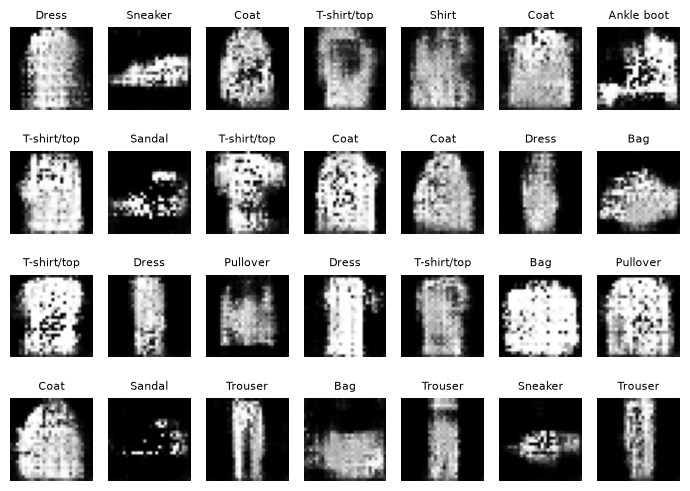

In [ ]:
# Define a função de gerar dados falsos de um vetores latentes aleatorios
def gerar_aleatorio(gerador, device, z_dim=100, n_images=20, labels=None):
    # Coloca o modelo em modo de avaliação
    gerador.eval()

    # Gera n_images vetores latentes aleatórios
    z = torch.randn((n_images, z_dim), device=device)

    # Se nenhum rótulo for fornecido, sorteia aleatoriamente
    # uma classe para cada imagem do lote.
    if labels is None:
        labels = torch.randint(0, gerador.n_classes, (n_images,), device=device)
    else:
        labels = labels.to(device)

    # Desativa o cálculo de gradientes, pois estamos apenas
    # gerando imagens para visualização.
    with torch.no_grad():
        dados_falsos = gerador(z, labels).detach().cpu().numpy()

    return dados_falsos, labels.cpu().numpy()

# Função para plotar várias imagens em um grid, exibindo
# também a classe usada para gerar cada imagem.
def plot_multiple_images(imagens, labels, classes, n_cols=7):

    n_rows = (len(imagens) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.3))
    for index, (img, label) in enumerate(zip(imagens, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(img.reshape(28, 28), cmap="gray")
        # Exibe o nome da classe correspondente ao rótulo.
        plt.title(classes[int(label)], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Gera um lote com imagens falsas
imagens, labels = gerar_aleatorio(
    modelo_gerador,
    device,
    z_dim=z_dim,
    n_images=28
)

# Chama a função para plotar as imagens
plot_multiple_images(
    imagens,
    labels,
    classes,
    n_cols=7
)

#### 3.5.2. Curvas de perda do Gerador e do Crítico ao longo das épocas 

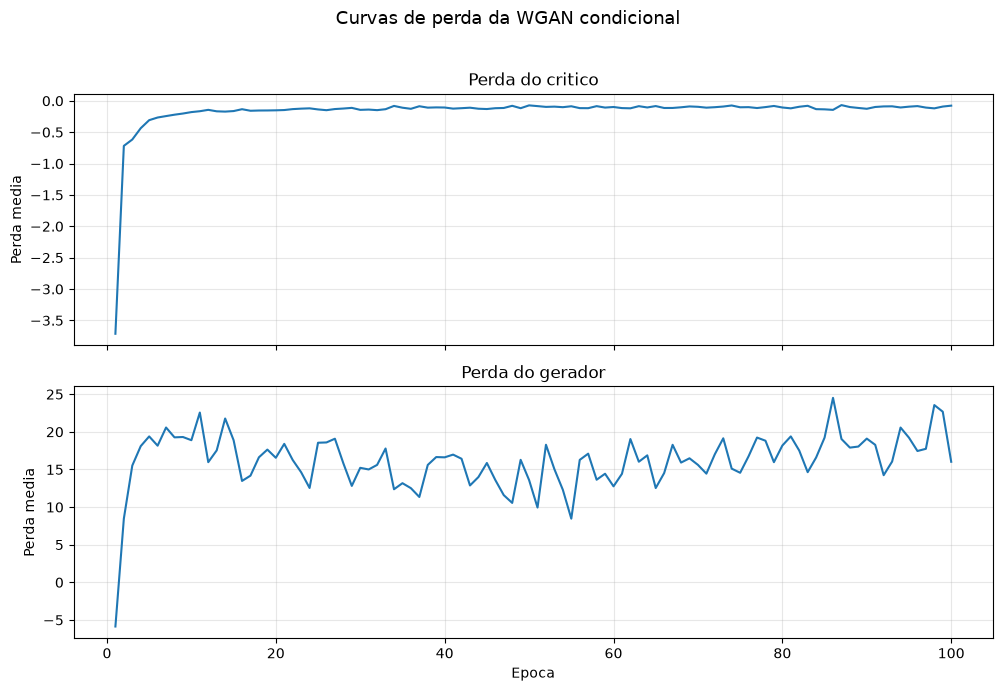

In [ ]:
# Gera o eixo X correspondente as epocas do treinamento.
epocas = range(1, len(historico_perda_gerador) + 1)

# Cria dois graficos, um para cada rede, permitindo visualizar
# adequadamente as diferentes escalas das perdas.
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True
)

# Plota a perda media do critico ao longo das epocas.
axes[0].plot(
    epocas,
    historico_perda_critico
)

axes[0].set_title("Perda do critico")
axes[0].set_ylabel("Perda media")
axes[0].grid(True, alpha=0.3)

# Plota a perda media do gerador ao longo das epocas.
axes[1].plot(
    epocas,
    historico_perda_gerador
)

axes[1].set_title("Perda do gerador")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Perda media")
axes[1].grid(True, alpha=0.3)

# Adiciona um titulo geral para os dois graficos.
fig.suptitle(
    "Curvas de perda da WGAN condicional",
    fontsize=13
)

# Ajusta o espacamento entre os elementos.
plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

plt.show()

#### 3.5.3. Evolução das saídas do gerador para um vetor latente fixo durante o treinamento

Agora vamos mostrar a evolução de um vetor latente fixado no inicio do treinamento e exibir sua evolução ao longo das épocas.

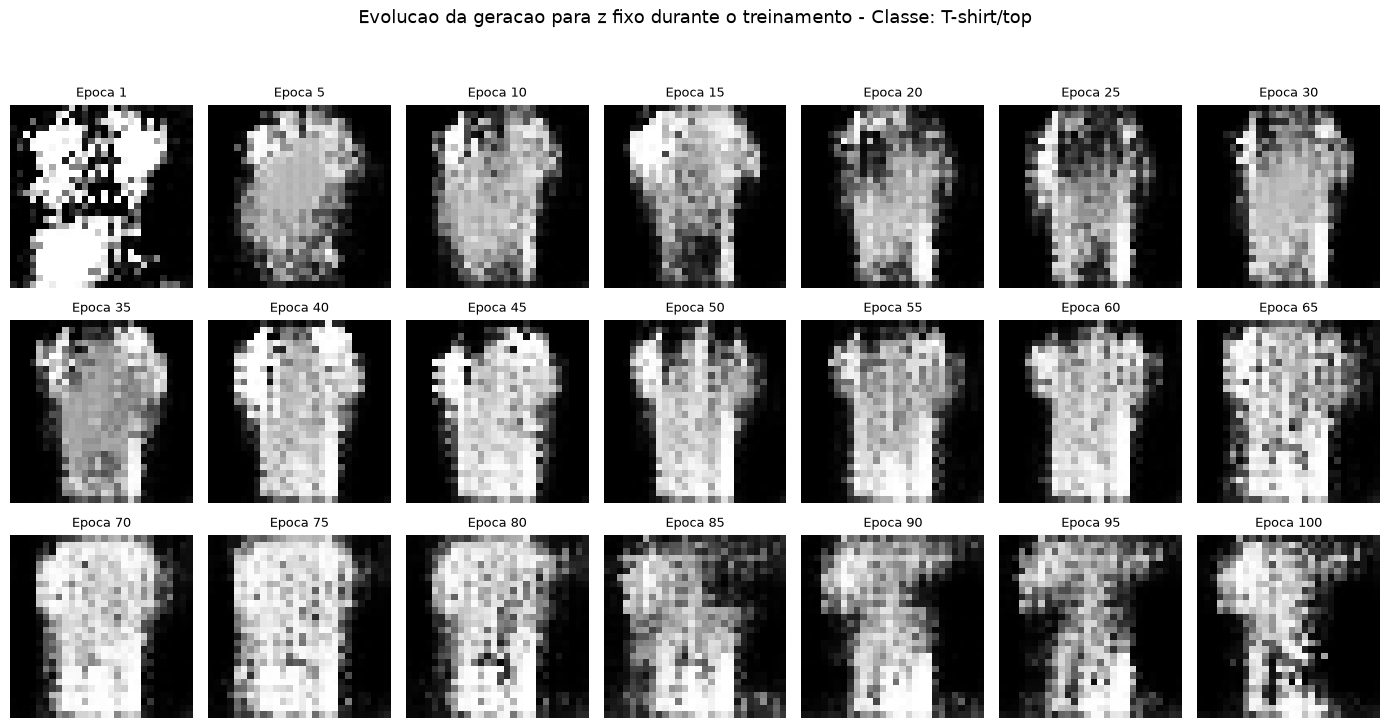

In [ ]:
# Lista com as imagens geradas para o mesmo vetor latente
# e a mesma classe em diferentes epocas do treinamento.
imagens = evolucao_dado_falso

# Define a quantidade de colunas da grade.
# Como temos 21 imagens (epocas 1, 5, 10, ..., 100),
# 7 colunas produzem uma grade com 3 linhas.
n_cols = 7

# Calcula automaticamente a quantidade de linhas necessaria
# para acomodar todas as imagens.
n_rows = (len(imagens) - 1) // n_cols + 1

# Cria a figura e os subplots onde cada imagem sera exibida.
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(14, n_rows * 2.5)
)

# Ajusta o espacamento entre os subplots e reserva
# espaco superior para o titulo geral.
plt.subplots_adjust(
    top=0.90,
    hspace=0.35,
    wspace=0.15
)

# Converte a matriz de eixos em um vetor unidimensional.
# Isso facilita percorrer todos os subplots em um unico loop.
axes = np.array(axes).reshape(-1)

# Percorre simultaneamente:
# - cada subplot;
# - cada imagem gerada;
# - a epoca correspondente.
for ax, img, epoca in zip(axes, imagens, epocas_evolucao):

    # Exibe a imagem usando sempre a mesma escala de valores.
    # Como a saida do gerador usa Tanh, os pixels estao no intervalo [-1, 1].
    # Fixar vmin e vmax evita que o matplotlib ajuste o contraste
    # individualmente para cada imagem.
    ax.imshow(
        img,
        cmap="gray",
        vmin=-1,
        vmax=1
    )

    # Exibe acima de cada imagem a epoca em que ela foi gerada.
    ax.set_title(
        f"Epoca {epoca}",
        fontsize=9
    )

    # Remove os eixos para deixar apenas a imagem visivel.
    ax.axis("off")

# Caso a quantidade de subplots seja maior que a quantidade
# de imagens, oculta os subplots que ficaram sem uso.
for ax in axes[len(imagens):]:
    ax.axis("off")

# Adiciona um titulo geral indicando que o vetor latente z
# e a classe foram mantidos fixos durante toda a evolucao.
fig.suptitle(
    f"Evolucao da geracao para z fixo durante o treinamento - Classe: {classes[classe_fixa.item()]}",
    fontsize=13
)

# Ajusta automaticamente o espacamento entre os elementos.
# O parametro rect reserva espaco superior para o titulo geral.
plt.tight_layout(
    rect=[0, 0, 1, 0.94]
)

plt.show()

#### 3.5.4. Geração de grade de amostras para as classes

In [ ]:
# Gera e plota uma grade com uma classe por linha.
# A primeira coluna mostra uma imagem real de referencia,
# e as demais colunas mostram amostras geradas para a mesma classe.
def plotar_grade_por_classe(
    gerador,
    classes,
    exemplos_reais,
    device,
    z_dim=100,
    n_cols_geradas=7
):
    # Coloca o gerador em modo de avaliacao.
    gerador.eval()

    n_classes = len(classes)

    # Numero total de colunas:
    # 1 coluna para a imagem real + n_cols_geradas para imagens geradas.
    n_cols_total = 1 + n_cols_geradas

    # Cria uma grade com uma linha por classe.
    fig, axes = plt.subplots(
        n_classes,
        n_cols_total,
        figsize=(n_cols_total * 1.5, n_classes * 1.5)
    )

    # Garante que axes seja tratado como matriz 2D.
    axes = np.array(axes).reshape(n_classes, n_cols_total)

    # Nao calcula gradientes, pois estamos apenas gerando imagens.
    with torch.no_grad():

        # Percorre todas as classes do Fashion-MNIST.
        for classe_idx, nome_classe in enumerate(classes):

            # =========================
            # Coluna 0: imagem real
            # =========================

            # Recupera a imagem real de referencia da classe atual.
            img_real = exemplos_reais[classe_idx]

            # Converte da faixa [-1, 1] para [0, 1] para visualizacao.
            img_real_plot = (img_real + 1.0) / 2.0

            axes[classe_idx, 0].imshow(
                img_real_plot,
                cmap="gray",
                vmin=0,
                vmax=1
            )
            axes[classe_idx, 0].axis("off")

            # =========================
            # Colunas seguintes: imagens geradas
            # =========================

            # Gera varios vetores latentes aleatorios para produzir
            # varias amostras da mesma classe.
            z = torch.randn((n_cols_geradas, z_dim), device=device)

            # Cria um vetor de labels contendo a mesma classe repetida
            # para todas as imagens geradas da linha atual.
            labels = torch.full(
                (n_cols_geradas,),
                classe_idx,
                device=device,
                dtype=torch.long
            )

            # Gera as imagens condicionadas pela classe atual.
            imagens_geradas = gerador(z, labels).cpu().numpy()

            # Exibe as imagens geradas nas colunas 1 em diante.
            for col in range(n_cols_geradas):
                img = imagens_geradas[col].reshape(28, 28)

                # Converte da faixa [-1, 1] para [0, 1].
                img_plot = (img + 1.0) / 2.0

                axes[classe_idx, col + 1].imshow(
                    img_plot,
                    cmap="gray",
                    vmin=0,
                    vmax=1
                )
                axes[classe_idx, col + 1].axis("off")

            # Exibe o nome da classe a esquerda da primeira imagem da linha.
            # Usamos text() em vez de set_ylabel(), pois axis("off")
            # tambem ocultaria o rotulo do eixo.
            axes[classe_idx, 0].text(
                -0.15,                       # Posicao horizontal, a esquerda da imagem
                0.5,                         # Centro vertical da imagem
                nome_classe,
                transform=axes[classe_idx, 0].transAxes,
                ha="right",
                va="center",
                fontsize=10,
                fontweight="bold",
                clip_on=False
            )

    # Coloca titulos apenas na primeira linha para identificar
    # claramente a coluna real e as colunas geradas.
    axes[0, 0].set_title("Real", fontsize=10)

    for col in range(1, n_cols_total):
        axes[0, col].set_title(f"Gerada {col}", fontsize=10)

    fig.suptitle(
        "Grade de amostras por classe: referencia real e imagens geradas",
        fontsize=13
    )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

In [ ]:
# Seleciona uma imagem real de referencia para cada classe.
def obter_exemplos_reais(dataset, n_classes):
    exemplos_reais = {}

    for img, label in dataset:
        if label not in exemplos_reais:
            exemplos_reais[label] = img.squeeze().cpu().numpy()

        if len(exemplos_reais) == n_classes:
            break

    return exemplos_reais

exemplos_reais = obter_exemplos_reais(
    training_data,
    n_classes=len(classes)
)

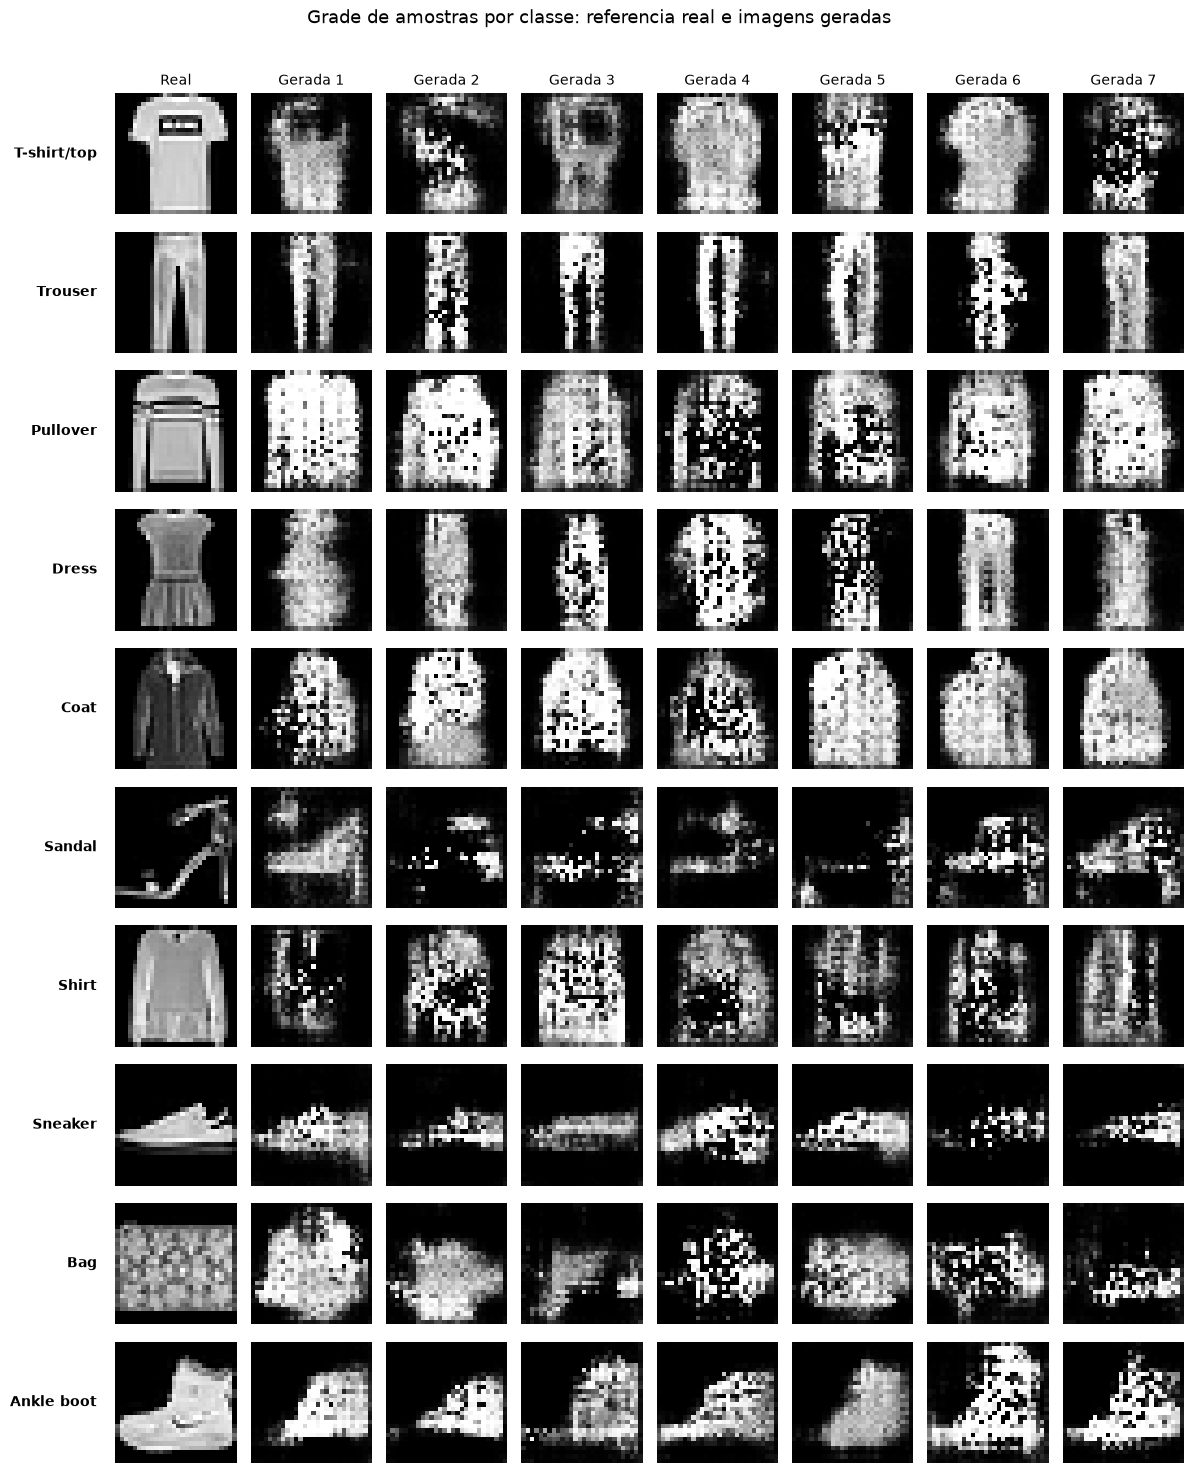

In [ ]:
plotar_grade_por_classe(
    gerador=modelo_gerador,
    classes=classes,
    exemplos_reais=exemplos_reais,
    device=device,
    z_dim=z_dim,
    n_cols_geradas=7
)

### 3.6. Interpolações no espaço latente

#### 3.6.1. Funções auxiliares

Primeiro definimos uma função auxiliar que permitirar plotar as interpolações utilizando o mesmo formato.

In [ ]:
# Funcao para plotar uma lista de imagens em uma unica linha.
def plotar_imagens(imagens, titulo=None):

    fig, eixos = plt.subplots(
        1,
        len(imagens),
        figsize=(len(imagens), 1.5)
    )

    # Se houver apenas uma imagem, garante que eixos seja iteravel.
    if len(imagens) == 1:
        eixos = [eixos]
        
    # Exibe as imagens na ordem em que foram geradas,
    # permitindo visualizar a transicao ao longo da interpolacao.
    for ax, img in zip(eixos, imagens):
        ax.imshow(img.reshape(28, 28), cmap="gray")
        ax.axis("off")

    # Adiciona um titulo opcional para identificar
    # o experimento de interpolacao realizado.
    if titulo is not None:
        fig.suptitle(titulo)

    plt.tight_layout()
    plt.show()

#### 3.6.2. Interpolação do vetor latente z fixo variando entre duas classes

In [ ]:
# Funcao que interpola entre duas classes, mantendo o vetor latente z fixo.
def interpolar_classes(gerador, c1, c2, n_classes, device, z_dim=100, steps=10, z=None):

    # Se nenhum vetor latente for fornecido, gera um vetor aleatorio.
    # Esse mesmo vetor sera mantido fixo durante toda a interpolacao.
    if z is None:
        z = torch.randn((1, z_dim), device=device)
    else:
        z = z.to(device)

    # Cria os vetores one-hot das duas classes extremas.
    # Exemplo:
    # c1 = 7 -> [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
    # c2 = 9 -> [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
    label_c1 = F.one_hot(
        torch.tensor([c1], device=device),
        num_classes=n_classes
    ).float()

    label_c2 = F.one_hot(
        torch.tensor([c2], device=device),
        num_classes=n_classes
    ).float()

    # Gera os valores de alpha no intervalo [0, 1].
    # Cada alpha define um ponto intermediario entre c1 e c2.
    alpha_valores = torch.linspace(0, 1, steps).to(device)

    imagens_interpoladas = []

    # Para cada valor de alpha, interpola entre os dois vetores one-hot
    # e gera a imagem correspondente usando sempre o mesmo z.
    for alpha in alpha_valores:

        # Interpolacao linear entre as classes:
        # alpha = 0   -> classe c1
        # alpha = 1   -> classe c2
        # valores intermediarios -> mistura entre c1 e c2
        label_interp = (1 - alpha) * label_c1 + alpha * label_c2

        # Gera uma imagem usando o mesmo z fixo e o rotulo interpolado.
        imagem = gerar(
            gerador=gerador,
            device=device,
            z=z,
            labels=label_interp
        )

        imagens_interpoladas.append(imagem)

    return imagens_interpoladas

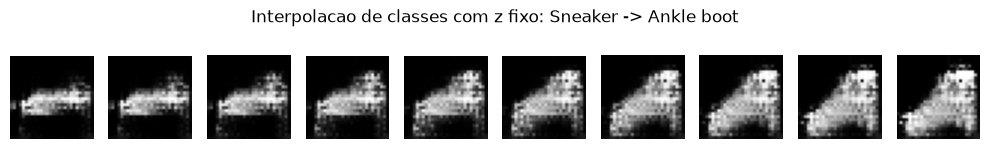

In [ ]:
# Escolhe duas classes para interpolar.
c1 = 7  # Sneaker
c2 = 9  # Ankle boot

# Gera as imagens interpoladas.
imagens = interpolar_classes(
    gerador=modelo_gerador,
    c1=c1,
    c2=c2,
    n_classes=n_classes,
    device=device,
    z_dim=z_dim,
    steps=10
)

# Plota as imagens lado a lado.
plotar_imagens(
    imagens,
    titulo=f"Interpolacao de classes com z fixo: {classes[c1]} -> {classes[c2]}"
)

#### 3.6.3. Interpolação com classe fixa e variação do vetor latente de z1 a z2

In [ ]:
# Interpola linearmente entre dois vetores latentes, mantendo a classe fixa durante toda a interpolacao.
def interpolar_z(
    gerador,
    classe,
    z_dim=100,
    steps=10,
    device="cpu"
):
    # Gera dois vetores latentes aleatorios que representam
    # os extremos da interpolacao.
    z1 = torch.randn((1, z_dim), device=device)
    z2 = torch.randn((1, z_dim), device=device)

    # Cria o rotulo da classe que sera mantida fixa durante
    # toda a interpolacao.
    label = torch.tensor([classe], device=device)

    # Coloca o gerador em modo de avaliacao.
    gerador.eval()

    # Valores de alpha entre 0 e 1 determinam os pontos
    # intermediarios entre z1 e z2.
    alpha_valores = torch.linspace(
        0,
        1,
        steps,
        device=device
    )

    imagens_interpoladas = []

    # Nao precisamos calcular gradientes, pois estamos apenas
    # gerando imagens para visualizacao.
    with torch.no_grad():

        for alpha in alpha_valores:

            # Interpolacao linear entre os dois vetores latentes:
            #
            # alpha = 0 -> z_interp = z1
            # alpha = 1 -> z_interp = z2
            #
            # Valores intermediarios produzem combinacoes lineares
            # entre os dois pontos do espaco latente.
            z_interp = (1 - alpha) * z1 + alpha * z2

            # Gera uma imagem usando o vetor latente interpolado,
            # mantendo sempre a mesma classe.
            imagem_gerada = gerador(z_interp, label)

            # Move o resultado para CPU e converte para NumPy
            # para posterior visualizacao com matplotlib.
            imagens_interpoladas.append(
                imagem_gerada.squeeze().cpu().numpy()
            )

    return imagens_interpoladas

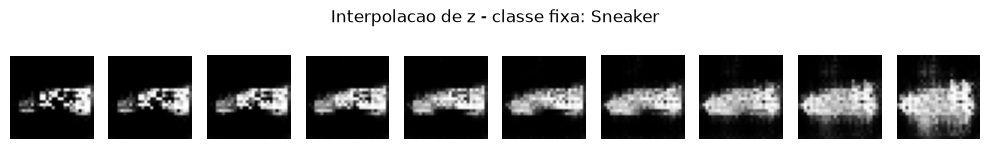

In [ ]:
# Escolhe a classe que sera mantida fixa durante a interpolacao.
classe = 7  # Exemplo: Sneaker

# Gera imagens interpoladas entre z1 e z2, mantendo a classe fixa.
imagens = interpolar_z(
    gerador=modelo_gerador,
    classe=classe,
    z_dim=z_dim,
    steps=10,
    device=device
)

# Plota as imagens lado a lado.
plotar_imagens(
    imagens,
    titulo=f"Interpolacao de z - classe fixa: {classes[classe]}"
)

#### 3.6.4. Interpolação simultânea entre [z1, c1] e [z2, c2]

In [ ]:
# Funcao que interpola simultaneamente entre dois vetores latentes
# e duas classes, gerando as imagens correspondentes.
def interpolar_z_e_classes(gerador, c1, c2, n_classes, device, z_dim=100, steps=10, z1=None, z2=None):

    # Se os vetores latentes nao forem fornecidos, gera dois vetores aleatorios.
    if z1 is None:
        z1 = torch.randn((1, z_dim), device=device)
    else:
        z1 = z1.to(device)

    if z2 is None:
        z2 = torch.randn((1, z_dim), device=device)
    else:
        z2 = z2.to(device)

    # Cria os vetores one-hot das duas classes extremas.
    label_c1 = F.one_hot(
        torch.tensor([c1], device=device),
        num_classes=n_classes
    ).float()

    label_c2 = F.one_hot(
        torch.tensor([c2], device=device),
        num_classes=n_classes
    ).float()

    # Valores de interpolacao no intervalo [0, 1].
    alpha_valores = torch.linspace(0, 1, steps).to(device)

    imagens_interpoladas = []

    # Para cada alpha, interpola simultaneamente:
    # - o vetor latente: z1 -> z2
    # - o vetor de classe: c1 -> c2
    for alpha in alpha_valores:

        # Interpola linearmente entre os vetores latentes.
        z_interp = (1 - alpha) * z1 + alpha * z2

        # Interpola linearmente entre os vetores one-hot das classes.
        label_interp = (1 - alpha) * label_c1 + alpha * label_c2

        # Gera a imagem correspondente ao ponto interpolado.
        imagem = gerar(
            gerador=gerador,
            device=device,
            z=z_interp,
            labels=label_interp
        )

        imagens_interpoladas.append(imagem)

    return imagens_interpoladas

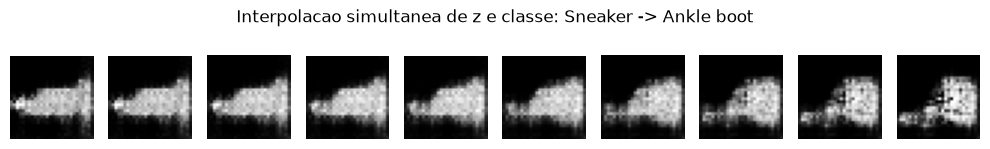

In [ ]:
# Escolhe duas classes para interpolar simultaneamente.
c1 = 7  # Sneaker
c2 = 9  # Ankle boot

# Gera as imagens interpoladas.
imagens = interpolar_z_e_classes(
    gerador=modelo_gerador,
    c1=c1,
    c2=c2,
    n_classes=n_classes,
    device=device,
    z_dim=z_dim,
    steps=10
)

# Plota as imagens lado a lado.
plotar_imagens(
    imagens,
    titulo=f"Interpolacao simultanea de z e classe: {classes[c1]} -> {classes[c2]}"
)

### 3.7. Fixação de vetor latente z e variação por todas as classes

In [ ]:
# Gera uma imagem para cada classe usando sempre o mesmo vetor latente z.
def gerar_z_fixo_por_classe(gerador, device, n_classes, z_dim=100, z=None):

    # Se nenhum vetor latente for fornecido, gera um vetor aleatorio.
    # Esse mesmo vetor sera reutilizado para todas as classes.
    if z is None:
        z = torch.randn((1, z_dim), device=device)
    else:
        z = z.to(device)

    imagens = []

    # Percorre todas as classes, alterando apenas o rotulo.
    for classe in range(n_classes):

        # Cria o rotulo correspondente a classe atual.
        label = torch.tensor(
            [classe],
            device=device
        )

        # Gera a imagem usando sempre o mesmo z,
        # variando exclusivamente o rotulo da classe.
        imagem = gerar(
            gerador=gerador,
            device=device,
            z=z,
            labels=label
        )

        imagens.append(imagem)

    return imagens

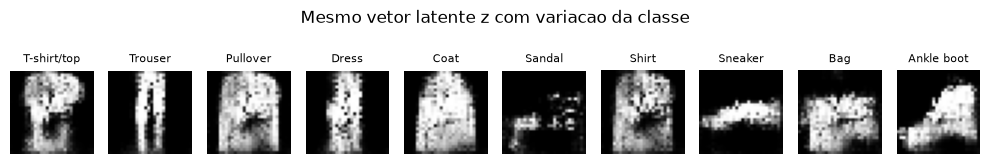

In [ ]:
# Gera uma imagem para cada uma das 10 classes
# mantendo o mesmo vetor latente z.
imagens = gerar_z_fixo_por_classe(
    gerador=modelo_gerador,
    device=device,
    n_classes=n_classes,
    z_dim=z_dim
)

# Cria uma linha com uma imagem para cada classe.
fig, eixos = plt.subplots(
    1,
    n_classes,
    figsize=(n_classes, 1.8)
)

# Exibe cada imagem junto com o nome da classe correspondente.
for classe, (ax, img) in enumerate(zip(eixos, imagens)):
    ax.imshow(
        img.reshape(28, 28),
        cmap="gray"
    )

    ax.set_title(
        classes[classe],
        fontsize=8
    )

    ax.axis("off")

# Adiciona um titulo geral indicando que apenas o rotulo foi alterado.
fig.suptitle(
    "Mesmo vetor latente z com variacao da classe",
    fontsize=12
)

plt.tight_layout()
plt.show()

### 3.7. Salvando

In [ ]:
os.makedirs("files", exist_ok=True)

torch.save(
    {
        "gerador_state_dict": modelo_gerador.state_dict(),
        "critico_state_dict": modelo_critico.state_dict(),

        "z_dim": z_dim,
        "n_classes": n_classes,
        "batch_size": batch_size,
        "n_critic": n_critic,
        "clip_value": clip_value,
        "lr_gerador": lr_gerador,
        "lr_critico": lr_critico,
        "num_epochs": num_epochs,
        "seed": SEED,

        "historico_perda_gerador": historico_perda_gerador,
        "historico_perda_critico": historico_perda_critico,
    },
    "files/wgan_condicional_checkpoint.pth"
)

### 3.7. Recuperando

In [ ]:
# Caminho do checkpoint salvo.
checkpoint_path = "files/wgan_condicional_checkpoint.pth"

# Carrega o checkpoint no dispositivo atualmente utilizado.
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

# Recupera os hiperparametros salvos.
z_dim = checkpoint["z_dim"]
n_classes = checkpoint["n_classes"]
batch_size = checkpoint["batch_size"]
n_critic = checkpoint["n_critic"]
clip_value = checkpoint["clip_value"]
lr_gerador = checkpoint["lr_gerador"]
lr_critico = checkpoint["lr_critico"]
num_epochs = checkpoint["num_epochs"]
SEED = checkpoint["seed"]

# Recria as arquiteturas dos modelos.
modelo_gerador = Gerador(
    z_dim=z_dim,
    n_classes=n_classes
).to(device)

modelo_critico = Critico(
    n_classes=n_classes
).to(device)

# Carrega os pesos treinados.
modelo_gerador.load_state_dict(
    checkpoint["gerador_state_dict"]
)

modelo_critico.load_state_dict(
    checkpoint["critico_state_dict"]
)

# Coloca os modelos em modo de avaliacao.
modelo_gerador.eval()
modelo_critico.eval()

# Recupera os historicos de perda.
historico_perda_gerador = checkpoint["historico_perda_gerador"]
historico_perda_critico = checkpoint["historico_perda_critico"]

print("Checkpoint carregado com sucesso.")
print(f"Gerador no device: {next(modelo_gerador.parameters()).device}")
print(f"Critico no device: {next(modelo_critico.parameters()).device}")

Checkpoint carregado com sucesso.
Gerador no device: mps:0
Critico no device: mps:0


## **Seção 4 — Precisão e Revocação de Variedades**

### 4.1. **Importações e Funções Auxiliares**

In [ ]:
!pip install prdc torchinfo torchmetrics

In [ ]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import Subset, DataLoader  # Subset permite criar subconjuntos de datasets, e DataLoader facilita o carregamento de dados em mini-lotes.
from torchvision import datasets            # Importa o módulo de conjuntos de dados do torchvision, que fornece acesso a conjuntos de dados populares como MNIST, CIFAR, etc. para visão computacional
from torchvision import transforms          # Importa o módulo de transforms do torchvision, usado para pré-processar imagens (conversão em tensor, normalização, etc.).
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import numpy as np                          # Importa a biblioteca NumPy, usada para operações numéricas eficientes com arrays e matrizes.
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
from IPython.display import Image           # Importa a classe Image do IPython, usada para exibir imagens diretamente dentro de notebooks.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).
from prdc import compute_prdc               # Importa a função compute_prdc, usada para calcular as métricas de Precisão e Revocação para modelos generativos.
import seaborn as sns                       # Importa a biblioteca de visualização seaborn.
import pandas as pd                         # Importa a biblioteca pandas, usada para manipulação e análise de dados em estruturas como DataFrames.

from torchmetrics.classification import MulticlassAccuracy

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # Define uma variável de ambiente para evitar conflitos de biblioteca durante a execução em alguns ambientes.

In [ ]:

# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline


In [ ]:

print("PyTorch version:", torch.__version__)            # Mostra a versão instalada do PyTorch
print("GPU Available:", torch.cuda.is_available())      # Indica se há GPU CUDA disponível

# Usa acelerador disponível (CUDA/MPS/XPU) ou então usa CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

# Exibe qual dispositivo está sendo utilizado
print(f"Usando {device}.")

torch.manual_seed(42)        # Fixa a semente para reprodutibilidade dos resultados gerados pelo PyTorch.
np.random.seed(42)           # Fixa a semente para gerar números aleatórios reprodutíveis no NumPy.

PyTorch version: 2.13.0
GPU Available: False
Usando mps.


In [ ]:
def create_noise(batch_size, z_dim, mode_z):           # Define a função create_noise para gerar vetores de ruído aleatório.
    if mode_z == 'uniform':                            # Caso o modo de geração seja "uniform":
        input_z = torch.rand(batch_size, z_dim)*2 - 1  # Gera amostras de ruído com distribuição uniforme em [-1, 1].
    elif mode_z == 'normal':                           # Caso o modo de geração seja "normal":
        input_z = torch.randn(batch_size, z_dim)       # Gera amostras de ruído com distribuição normal padrão N(0,1).
    return input_z                                     # Retorna o lote de vetores de ruído gerados (tensor de shape [batch_size, z_dim]).

### 4.2. **Hiperparâmetros**

In [ ]:
image_shape = (1, 28, 28)    # Formato das imagens do Fashion MNIST: 1 canal, 28x28 pixels.

z_dim = 100                  # Dimensão comum do vetor latente para GAN FC, DCGAN e WGAN.

hidden_size = 256            # Número de neurônios na camada oculta do gerador e discriminador do GAN FC.
hidden_channels = 64         # Número de canais na camada oculta do gerador e discriminador do DCGAN e WGAN.

batch_size = 64              # Define o tamanho do mini-lote (número de amostras processadas por iteração).
mode_z = 'normal'            # Define o modo de geração do ruído: 'uniform' (U[-1,1]) ou 'normal' (N(0,1)).

num_epochs = 50              # Numero de épocas de treinamento. Será utilizado por todos os modelos


### 4.3. **Definição dos modelos**

#### 4.3.1. **Hierarquia de Classes Base**

```
nn.Module
 │
 └─ RedeImagemBase
    │
    ├── GeradorBase
    │   ├── GeradorGANFC
    │   └── GeradorConvolucionalBase
    │       ├── GeradorDCGAN
    │       └── GeradorWGAN
    │
    └── AvaliadorBase
        ├── DiscriminadorGANFC
        └── AvaliadorConvolucionalBase
            ├── DiscriminadorDCGAN
            └── CriticoWGAN
```

##### 4.3.1.1.  RedeImagemBase

Classe base comum de toda a hierarquia. Define atributos comuns, validação de tamanho e forward comum.

In [ ]:
class RedeImagemBase(nn.Module):

    def __init__(self, image_shape=(1, 28, 28)):
        super().__init__()

        self.image_shape = image_shape
        self.image_channels, self.height, self.width = image_shape
        self.num_pixels = int(np.prod(image_shape))

        assert self.height == 28 and self.width == 28, \
            "Esta arquitetura foi definida para imagens 28x28."

    def forward(self, x):
        return self.net(x)

##### 4.3.1.2. GeradorBase

Classe base comum para todos os geradores. Define o atributo comum z_dim (dimensão do vetor latente para geração das imagens)

In [ ]:
class GeradorBase(RedeImagemBase):

    def __init__(self, z_dim=100, image_shape=(1, 28, 28)):
        super().__init__(image_shape=image_shape)

        self.z_dim = z_dim

##### 4.3.1.3. AvaliadorBase

Avaliador comum tanto para discriminadores quanto para criticos. Não define novos atributos, foi criada apenas para manter organização semântica da hierarquia.

In [ ]:
class AvaliadorBase(RedeImagemBase):

    def __init__(self, image_shape=(1, 28, 28)):
        super().__init__(image_shape=image_shape)

##### 4.3.1.4. GeradorConvolucionalBase

Base comum a todos os geradores convolucionais (DCGAN e WGAN). Define a arquitetura convolucional comum para geração das imagens. A diferenciação entre DCGAN ou WGAN se dará pelo uso do discriminador/critico, não pela arquitetura do gerador. Obviamente, como serão treinados com uma contraparte diferente, serão geradas redes com parametros diferentes (mas que compartilham a mesma arquitetura)

In [ ]:
class GeradorConvolucionalBase(GeradorBase):

    def __init__(
        self,
        z_dim=100,
        hidden_channels=64,
        image_shape=(1, 28, 28)
    ):
        super().__init__(z_dim=z_dim, image_shape=image_shape)

        # Define o gerador como uma rede sequencial.
        self.net = nn.Sequential(
            nn.Linear(                                               # Camada linear:
                self.z_dim,                                          #   - recebe o vetor latente de dimensão z_dim
                7 * 7 * hidden_channels * 2                          #   - projeta para hidden_channels*2 mapas de 7x7
            ),
            nn.Unflatten(                                            # Reorganiza o vetor linear em mapas de características:
                dim=1,                                               #   - preserva a dimensão do batch
                unflattened_size=(hidden_channels * 2, 7, 7)         #   - produz [hidden_channels*2, 7, 7]
            ),
            nn.BatchNorm2d(hidden_channels * 2),                     # Normaliza os mapas de características intermediários.

            nn.ConvTranspose2d(                                      # Primeira camada convolucional transposta:
                hidden_channels * 2,                                 #   - recebe hidden_channels*2 mapas de características
                hidden_channels,                                     #   - reduz para hidden_channels mapas de características
                kernel_size=5, stride=2, padding=2, output_padding=1 #   - aumenta a resolução espacial de 7x7 para 14x14
            ),

            nn.ReLU(True),                                           # Introduz não-linearidade após a primeira expansão espacial.
            nn.BatchNorm2d(hidden_channels),                         # Normaliza os mapas de características intermediários.

            nn.ConvTranspose2d(                                      # Segunda camada convolucional transposta:
                hidden_channels,                                     #   - recebe hidden_channels mapas de características
                self.image_channels,                                 #   - produz o número de canais da imagem de saída
                kernel_size=5, stride=2, padding=2, output_padding=1 #   - aumenta a resolução espacial de 14x14 para 28x28
            ),
            nn.Tanh()                                                # Normaliza os pixels gerados para a faixa [-1, 1].
        )

##### 4.3.1.5. AvaliadorConvolucionalBase

Base comum a todos os avaliadores convolucionais (discriminadores e criticos). Define a arquitetura convolucional comum para avaliação das imagens. A diferenciação entre discriminador (DCGAN) ou crítico (WGAN) se dará pelo parametro sigmoid = True / sigmoid = False.

In [ ]:
class AvaliadorConvolucionalBase(AvaliadorBase):

    def __init__(
        self,
        hidden_channels=64,
        image_shape=(1, 28, 28),
        dropout=0.4,
        negative_slope=0.2,
        sigmoid=False
    ):
        super().__init__(image_shape=image_shape)

        self.sigmoid = sigmoid # mantem a informação no atributo para evitar ter que inspecionar a ultima camada para saber o tipo de saida.

        # Define o avaliador como uma rede sequencial.
        self.net = nn.Sequential(
            nn.Conv2d(                                      # Primeira camada convolucional:
                self.image_channels,                        #   - recebe os canais da imagem de entrada
                hidden_channels,                            #   - produz hidden_channels mapas de características
                kernel_size=5, stride=2, padding=2),        #   - reduz a resolução espacial de 28x28 para 14x14
            nn.LeakyReLU(negative_slope=negative_slope),    # Introduz não-linearidade preservando gradiente para valores negativos.
            nn.Dropout(p=dropout),                          # Aplica dropout para reduzir sobreajuste do avaliador.
            nn.Conv2d(                                      # Segunda camada convolucional:
                hidden_channels,                            #   - recebe hidden_channels mapas de características
                hidden_channels * 2,                        #   - dobra o número de mapas de características
                kernel_size=5, stride=2, padding=2),        #   - reduz a resolução espacial de 14x14 para 7x7
            nn.LeakyReLU(negative_slope=negative_slope),    # Introduz não-linearidade preservando gradiente para valores negativos.
            nn.Dropout(p=dropout),                          # Aplica dropout antes da etapa totalmente conectada.
            nn.Flatten(),                                   # Converte os mapas [hidden_channels*2, 7, 7] em um vetor por amostra.
            nn.Linear(7 * 7 * hidden_channels * 2, 1),      # Reduz as características extraídas para uma única saída escalar.
            *([nn.Sigmoid()] if sigmoid else [])            # Adiciona Sigmoid apenas quando a saída deve representar probabilidade.
        )

#### 4.3.2.  **GAN (Fully Connected)**

##### 4.3.2.1. GeradorGANFC

O GeradorBase não define a arquitetura da rede, logo, temos que definir nossa arquitetura Fully Connected aqui.

In [ ]:
class GeradorGANFC(GeradorBase):

    def __init__(self, z_dim=100, hidden_size=256, image_shape=(1, 28, 28)):
        super().__init__(z_dim=z_dim, image_shape=image_shape)

        # Define o gerador como uma rede sequencial.
        self.net = nn.Sequential(                         
            nn.Linear(                             # Primeira Camada Fully Connected:
                self.z_dim,                        #   - recebe o vetor latente de dimensão z_dim
                hidden_size),                      #   - projeta para uma representação oculta de dimensão hidden_size
            nn.LeakyReLU(),                        # Introduz não-linearidade e reduz o risco de "neurônios mortos".
            nn.Linear(                             # Segunda Camada Fully Connected:
                hidden_size,                       #   - recebe vetor de dimensão hidden_size
                self.num_pixels),                  #   - projeta para o numero de pixels da imagem.
            nn.Tanh(),                             # Limita os pixels gerados à faixa [-1, 1], compatível com a normalização dos dados reais.
            nn.Unflatten(                          # Reorganiza o vetor de pixels no formato original da imagem:
                dim=1,                             #   - preserva a dimensão do batch
                unflattened_size=self.image_shape  #   - produz imagens no formato [1, 28, 28]
            )

        )


##### 4.3.2.2. DiscriminadorGANFC

O AvaliadorBase não define a arquitetura da rede, logo, temos que definir a arquitetura do nosso discriminador Fully Connected aqui.

In [ ]:
class DiscriminadorGANFC(AvaliadorBase):

    def __init__(self, hidden_size=256, image_shape=(1, 28, 28)):
        super().__init__(image_shape=image_shape)

        # Define o discriminador como uma rede sequencial.
        self.net = nn.Sequential(
            nn.Flatten(),                  # Converte cada imagem em um vetor de pixels, preservando a dimensão do batch.
            nn.Linear(                     # Camada linear:
                self.num_pixels,           #   - entrada com o número total de pixels np.prod(image_shape) (tipicamente 28*28 = 784)
                hidden_size),              #   - saída com hidden_size neuronios
            nn.LeakyReLU(),                # Função de ativação LeakyReLU para introduzir não-linearidade.
            nn.Dropout(p=0.5),             # Camada de dropout com probabilidade de 50%.
            nn.Linear(hidden_size, 1),     # Camada linear final que reduz para uma única saída escalar.
            nn.Sigmoid()                   # Função sigmoide: comprime a saída para [0,1], interpretada como probabilidade de ser real.
        )

#### 4.3.3.  **DCGAN (Deep Convolutional GAN)**

##### 4.3.3.1. GeradorDCGAN

A arquitetura do GeradorConvolucionalBase já define completamente a arquitetura da rede, não precisamos modificar nada. Criamos a classe apenas para manter a nomenclatura da hierarquia homogênea. E se no futuro precisarmos de algum ajuste específico não precisamos tocar o código que utiliza a classe.

In [ ]:
# cria classe para manter padrao de nomenclatura regular com outras redes
class GeradorDCGAN(GeradorConvolucionalBase):
    pass

##### 4.3.3.2. DiscriminadorDCGAN

A arquitetura do AvaliadorConvolucionalBase já define completamente a arquitetura da rede, precisamos apenas indicar o parametro sigmoid=True para caracterizar o discriminador com saida em forma de probabilidade. Assim mantemos a nomenclatura da hierarquia homogênea.

In [ ]:
# Extende AvaliadorConvolucionalBase *COM* sigmoid na ultima camada (sigmoid=True)
class DiscriminadorDCGAN(AvaliadorConvolucionalBase):

    def __init__(
        self,
        hidden_channels=64,
        image_shape=(1, 28, 28),
        dropout=0.4,
        negative_slope=0.2
    ):
        super().__init__(
            hidden_channels=hidden_channels,
            image_shape=image_shape,
            dropout=dropout,
            negative_slope=negative_slope,
            sigmoid=True                       # Importante sigmoid=True para gerar probabilidades na saida
        )

#### 4.3.4. **WGAN (convolucional)**


##### 4.3.4.1. GeradorWGAN

A arquitetura do GeradorConvolucionalBase já define completamente a arquitetura da rede, não precisamos modificar nada. Criamos a classe apenas para manter a nomenclatura da hierarquia homogênea. E se no futuro precisarmos de algum ajuste específico não precisamos tocar o código que utiliza a classe.

In [ ]:
# cria classe para manter padrao de nomenclatura regular com outras redes
class GeradorWGAN(GeradorConvolucionalBase):
    pass

##### 4.3.4.2. CriticoWGAN

A arquitetura do AvaliadorConvolucionalBase já define completamente a estrutura da rede. Para o crítico da WGAN, utilizamos sigmoid=False, fazendo com que a saída seja um escore escalar não limitado, em vez de uma probabilidade. A caracterização como crítico WGAN deve ser completada pela função objetivo e pelo procedimento de treinamento específicos da WGAN.

In [ ]:
# Extende AvaliadorConvolucionalBase *SEM* sigmoid na ultima camada (sigmoid=False)
class CriticoWGAN(AvaliadorConvolucionalBase):

    def __init__(
        self,
        hidden_channels=64,
        image_shape=(1, 28, 28),
        dropout=0.4,
        negative_slope=0.2
    ):
        super().__init__(
            hidden_channels=hidden_channels,
            image_shape=image_shape,
            dropout=dropout,
            negative_slope=negative_slope,
            sigmoid=False
        )

### 4.4. **Dados**

#### 4.4.1. **Leitura**

In [ ]:
image_path = './data/'                          # Define o diretório raiz onde o conjunto de dados Fashion MNIST será armazenado.

transform = transforms.Compose([                # Define uma sequência de transformações a serem aplicadas às imagens do dataset.
    transforms.ToTensor(),                      # Converte as imagens PIL em tensores PyTorch.
    transforms.Lambda(lambda x: x * 2 - 1),     # Normaliza os valores dos pixels da faixa [0, 1] para [-1, 1].
])

fashion_mnist_dataset = datasets.FashionMNIST(
                    root=image_path,            # Cria o objeto do dataset Fashion MNIST.
                    train=True,                 # Define que serão carregadas as imagens do conjunto de treinamento.
                    transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                    download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

fashion_mnist_test = datasets.FashionMNIST(
                    root=image_path,            # Cria o objeto do dataset Fashion MNIST.
                    train=False,                # Define que serão carregadas as imagens do conjunto de teste.
                    transform=transform,        # Aplica as transformações definidas acima a cada imagem carregada.
                    download=True)              # Faz o download do dataset caso ele não esteja presente no diretório especificado.

print(f'fashion_mnist_dataset | fashion_mnist_test: {type(fashion_mnist_dataset)} | {type(fashion_mnist_test)}.')

example, label = next(iter(fashion_mnist_dataset))         # Obtém o primeiro par (imagem, rótulo) do dataset MNIST.
print(f'Min: {example.min()} Max: {example.max()}')        # Exibe os valores mínimo e máximo do tensor da imagem (após normalização).
print(example.shape)                                       # Exibe o formato do tensor da imagem (para Fashion MNIST: [1, 28, 28]).

fashion_mnist_dataset | fashion_mnist_test: <class 'torchvision.datasets.mnist.FashionMNIST'> | <class 'torchvision.datasets.mnist.FashionMNIST'>.
Min: -1.0 Max: 1.0
torch.Size([1, 28, 28])


#### 4.4.2. **Criação dos Datasets**

In [ ]:
fashion_mnist_dl = DataLoader(
    fashion_mnist_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

### 4.5. **Treinamento dos Modelos Generativos**

#### 4.5.1. **Criação de Função de Perda**

In [ ]:
def criar_funcoes_perda(tipo):

    if tipo == 'bce':
        bce = nn.BCELoss()

        def perda_avaliador(saida_real, saida_fake):
            labels_real = torch.ones_like(saida_real)
            labels_fake = torch.zeros_like(saida_fake)

            loss_real = bce(saida_real, labels_real)
            loss_fake = bce(saida_fake, labels_fake)

            return loss_real + loss_fake

        def perda_gerador(saida_fake):
            labels_real = torch.ones_like(saida_fake)
            return bce(saida_fake, labels_real)

    elif tipo == 'wasserstein':

        def perda_avaliador(saida_real, saida_fake):
            return saida_fake.mean() - saida_real.mean()

        def perda_gerador(saida_fake):
            return -saida_fake.mean()

    else:
        raise ValueError(f'Tipo de perda não suportado: {tipo}')

    return perda_avaliador, perda_gerador

#### 4.5.2. **Criação de Otimizadores**

In [ ]:
def criar_otimizador(modelo, tipo, lr):

    if tipo == 'adam':
        return torch.optim.Adam(
            modelo.parameters(),
            lr=lr
        )

    elif tipo == 'rmsprop':
        return torch.optim.RMSprop(
            modelo.parameters(),
            lr=lr
        )

    raise ValueError(f'Otimizador não suportado: {tipo}')

#### 4.5.3. **Função de Treinamento do Gerador**

In [ ]:
def treinar_gerador(batch_size_atual, experimento):

    gerador = experimento['gerador']
    avaliador = experimento['avaliador']
    optimizer = experimento['g_optimizer']
    perda_fn = experimento['perda_gerador']

    optimizer.zero_grad(set_to_none=True)

    # Evita calcular gradientes dos parâmetros do avaliador durante o treino do gerador.
    for parametro in avaliador.parameters():
        parametro.requires_grad_(False)

    input_z = create_noise(
        batch_size_atual,
        z_dim,
        mode_z
    ).to(device)

    imagens_fake = gerador(input_z)
    saida_fake = avaliador(imagens_fake)

    loss = perda_fn(saida_fake)

    loss.backward()
    optimizer.step()

    # Reabilita os gradientes para o próximo treinamento do avaliador.
    for parametro in avaliador.parameters():
        parametro.requires_grad_(True)

    return loss.item()

#### 4.5.4. **Função de Treinamento do Avaliador**

In [ ]:
def treinar_avaliador(x, experimento):

    gerador = experimento['gerador']
    avaliador = experimento['avaliador']
    optimizer = experimento['a_optimizer']
    perda_fn = experimento['perda_avaliador']

    optimizer.zero_grad(set_to_none=True)

    x = x.to(device)
    batch_size_atual = x.size(0)

    # Gera amostras falsas sem calcular gradientes para o gerador.
    input_z = create_noise(
        batch_size_atual,
        z_dim,
        mode_z
    ).to(device)

    with torch.no_grad():
        imagens_fake = gerador(input_z)

    # Avalia imagens reais e geradas.
    saida_real = avaliador(x)
    saida_fake = avaliador(imagens_fake)

    # Calcula a perda conforme a estratégia do experimento.
    loss = perda_fn(saida_real, saida_fake)

    loss.backward()
    optimizer.step()

    # Weight clipping utilizado pela WGAN clássica.
    clip_value = experimento['clip_value']

    if clip_value is not None:
        with torch.no_grad():
            for parametro in avaliador.parameters():
                parametro.clamp_(-clip_value, clip_value)

    return (
        loss.item(),
        saida_real.detach().mean().item(),
        saida_fake.detach().mean().item()
    )

#### 4.5.5. **Função de Treinamento de um Experimento Completo**

In [ ]:
def treinar_experimento(
    nome,
    experimento,
    dataloader,
    num_epochs
):

    historico = {
        'g_loss': [],
        'a_loss': [],
        'saida_real': [],
        'saida_fake': []
    }

    n_critic = experimento['n_critic']
    critic_steps = 0

    for epoch in range(1, num_epochs + 1):

        a_losses = []
        g_losses = []
        saidas_real = []
        saidas_fake = []

        for x, _ in dataloader:

            a_loss, saida_real, saida_fake = treinar_avaliador(
                x,
                experimento
            )

            a_losses.append(a_loss)
            saidas_real.append(saida_real)
            saidas_fake.append(saida_fake)

            critic_steps += 1

            # GAN/DCGAN: n_critic = 1
            # WGAN: n_critic = 5
            if critic_steps % n_critic == 0:
                g_loss = treinar_gerador(
                    x.size(0),
                    experimento
                )

                g_losses.append(g_loss)

        historico['a_loss'].append(np.mean(a_losses))
        historico['g_loss'].append(np.mean(g_losses))
        historico['saida_real'].append(np.mean(saidas_real))
        historico['saida_fake'].append(np.mean(saidas_fake))

        print(
            f'{nome} | Época {epoch:03d} | '
            f'G/A: {historico["g_loss"][-1]:.4f}/'
            f'{historico["a_loss"][-1]:.4f} | '
            f'Real: {historico["saida_real"][-1]:.4f} | '
            f'Fake: {historico["saida_fake"][-1]:.4f}'
        )

    return historico

#### 4.5.6. **Definição dos Experimentos**

Cria dicionário comum contendo todos os experimentos.

In [ ]:
experimentos = {

    'GAN FC': {
        'gerador': GeradorGANFC(
            z_dim=z_dim,
            hidden_size=hidden_size,
            image_shape=image_shape
        ).to(device),

        'avaliador': DiscriminadorGANFC(
            hidden_size=hidden_size,
            image_shape=image_shape
        ).to(device),

        'tipo_perda': 'bce',

        'otimizador_gerador': {
            'tipo': 'adam',
            'lr': 1e-3
        },

        'otimizador_avaliador': {
            'tipo': 'adam',
            'lr': 1e-3
        },

        'n_critic': 1,
        'clip_value': None
    },

    'DCGAN': {
        'gerador': GeradorDCGAN(
            z_dim=z_dim,
            hidden_channels=hidden_channels,
            image_shape=image_shape
        ).to(device),

        'avaliador': DiscriminadorDCGAN(
            hidden_channels=hidden_channels,
            image_shape=image_shape,
            dropout=0.4,
            negative_slope=0.2
        ).to(device),

        'tipo_perda': 'bce',

        'otimizador_gerador': {
            'tipo': 'adam',
            'lr': 1e-3
        },

        'otimizador_avaliador': {
            'tipo': 'adam',
            'lr': 1e-3
        },

        'n_critic': 1,
        'clip_value': None
    },

    'WGAN': {
        'gerador': GeradorWGAN(
            z_dim=z_dim,
            hidden_channels=hidden_channels,
            image_shape=image_shape
        ).to(device),

        'avaliador': CriticoWGAN(
            hidden_channels=hidden_channels,
            image_shape=image_shape,
            dropout=0.4,
            negative_slope=0.2
        ).to(device),

        'tipo_perda': 'wasserstein',

        'otimizador_gerador': {
            'tipo': 'rmsprop',
            'lr': 1e-4
        },

        'otimizador_avaliador': {
            'tipo': 'rmsprop',
            'lr': 1e-4
        },

        'n_critic': 5,
        'clip_value': 0.01
    }
}

#### 4.5.7. **Inicializa função de perda e otimizador de cada experimento**

In [ ]:
for experimento in experimentos.values():

    perda_avaliador, perda_gerador = criar_funcoes_perda(
        experimento['tipo_perda']
    )

    experimento['perda_avaliador'] = perda_avaliador
    experimento['perda_gerador'] = perda_gerador

    experimento['g_optimizer'] = criar_otimizador(
        experimento['gerador'],
        **experimento['otimizador_gerador']
    )

    experimento['a_optimizer'] = criar_otimizador(
        experimento['avaliador'],
        **experimento['otimizador_avaliador']
    )

#### 4.5.8. **Tabela Hiperparâmetros dos Experimentos**

Os três modelos utilizam `z_dim=100`, ruído normal, `batch_size=64`, `image_shape=(1,28,28)` e 50 épocas. A seguir são exibidos em uma tabela os hiperparametros específicos de cada experimento. A definição dos valores ocorre junto com a definição da variável ```experimentos```. A tabela abaixo é utilizada apenas para facilitar a visualização dos valores.

In [ ]:
tabela_experimentos = pd.DataFrame([
    {
        'Modelo': 'GAN FC',
        'Arquitetura': 'Fully Connected',
        'hidden_size': hidden_size,
        'hidden_channels': '-',
        'Perda': experimentos['GAN FC']['tipo_perda'],
        'Otimizador': experimentos['GAN FC']['otimizador_gerador']['tipo'],
        'Learning rate': experimentos['GAN FC']['otimizador_gerador']['lr'],
        'n_critic': experimentos['GAN FC']['n_critic'],
        'clip_value': (
            experimentos['GAN FC']['clip_value']
            if experimentos['GAN FC']['clip_value'] is not None
            else '-'
        )
    },
    {
        'Modelo': 'DCGAN',
        'Arquitetura': 'Convolucional',
        'hidden_size': '-',
        'hidden_channels': hidden_channels,
        'Perda': experimentos['DCGAN']['tipo_perda'],
        'Otimizador': experimentos['DCGAN']['otimizador_gerador']['tipo'],
        'Learning rate': experimentos['DCGAN']['otimizador_gerador']['lr'],
        'n_critic': experimentos['DCGAN']['n_critic'],
        'clip_value': (
            experimentos['DCGAN']['clip_value']
            if experimentos['DCGAN']['clip_value'] is not None
            else '-'
        )
    },
    {
        'Modelo': 'WGAN',
        'Arquitetura': 'Convolucional',
        'hidden_size': '-',
        'hidden_channels': hidden_channels,
        'Perda': experimentos['WGAN']['tipo_perda'],
        'Otimizador': experimentos['WGAN']['otimizador_gerador']['tipo'],
        'Learning rate': experimentos['WGAN']['otimizador_gerador']['lr'],
        'n_critic': experimentos['WGAN']['n_critic'],
        'clip_value': (
            experimentos['WGAN']['clip_value']
            if experimentos['WGAN']['clip_value'] is not None
            else '-'
        )
    }
])

display(tabela_experimentos)

,Modelo,Arquitetura,hidden_size,hidden_channels,Perda,Otimizador,Learning rate,n_critic,clip_value
0,GAN FC,Fully Connected,256,-,bce,adam,0.0010,1,-
1,DCGAN,Convolucional,-,64,bce,adam,0.0010,1,-
2,WGAN,Convolucional,-,64,wasserstein,rmsprop,0.0001,5,0.01


#### 4.5.9. **Treinamento dos Experimentos**

In [ ]:
resultados_treinamento = {}

for nome, experimento in experimentos.items():

    print(f'\nTreinando {nome}...\n')

    resultados_treinamento[nome] = treinar_experimento(
        nome=nome,
        experimento=experimento,
        dataloader=fashion_mnist_dl,
        num_epochs=num_epochs
    )


Treinando GAN FC...

GAN FC | Época 001 | G/A: 2.7161/0.3170 | Real: 0.9298 | Fake: 0.1686
GAN FC | Época 002 | G/A: 1.7119/0.6267 | Real: 0.8136 | Fake: 0.2526
GAN FC | Época 003 | G/A: 1.4166/0.9033 | Real: 0.7069 | Fake: 0.3181
GAN FC | Época 004 | G/A: 1.2422/1.0170 | Real: 0.6616 | Fake: 0.3483
GAN FC | Época 005 | G/A: 1.3099/1.0438 | Real: 0.6518 | Fake: 0.3482
GAN FC | Época 006 | G/A: 1.1957/1.0960 | Real: 0.6339 | Fake: 0.3708
GAN FC | Época 007 | G/A: 1.1591/1.1278 | Real: 0.6209 | Fake: 0.3804
GAN FC | Época 008 | G/A: 1.0638/1.1862 | Real: 0.5956 | Fake: 0.4025
GAN FC | Época 009 | G/A: 1.0226/1.2027 | Real: 0.5872 | Fake: 0.4126
GAN FC | Época 010 | G/A: 0.9880/1.2230 | Real: 0.5787 | Fake: 0.4202
GAN FC | Época 011 | G/A: 0.9694/1.2397 | Real: 0.5735 | Fake: 0.4251
GAN FC | Época 012 | G/A: 0.9351/1.2595 | Real: 0.5634 | Fake: 0.4342
GAN FC | Época 013 | G/A: 0.9256/1.2577 | Real: 0.5637 | Fake: 0.4353
GAN FC | Época 014 | G/A: 0.9498/1.2553 | Real: 0.5665 | Fake: 0.434

### 4.6. **Grade de Imagens**

#### 4.6.1. Define tamanho da grade e gera o ruído

In [ ]:
num_samples = 25

torch.manual_seed(42)

z_amostras = create_noise(
    num_samples,
    z_dim,
    mode_z
).to(device)

#### 4.6.2. Função para plotar a grade de um modelo

In [ ]:
@torch.no_grad()
def plotar_grade_amostras(
    gerador,
    z,
    titulo,
    nrows=5,
    ncols=5
):
    gerador.eval()

    imagens = gerador(z)                  # Gera imagens no formato [B, 1, 28, 28].
        # Compatibilidade com o GeradorGANFC treinado antes da adição do nn.Unflatten().
    if imagens.ndim == 2:
        imagens = imagens.view(-1, 1, 28, 28)
        
    imagens = (imagens + 1) / 2           # Converte os pixels da faixa [-1, 1] para [0, 1].
    imagens = imagens.cpu()

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(7, 7)
    )

    for i, ax in enumerate(axes.flat):
        ax.imshow(
            imagens[i].squeeze(),
            cmap='gray'
        )
        ax.axis('off')

    fig.suptitle(titulo, fontsize=16)
    plt.tight_layout()
    plt.show()

#### 4.6.3. Exibição da grade de todos os modelos

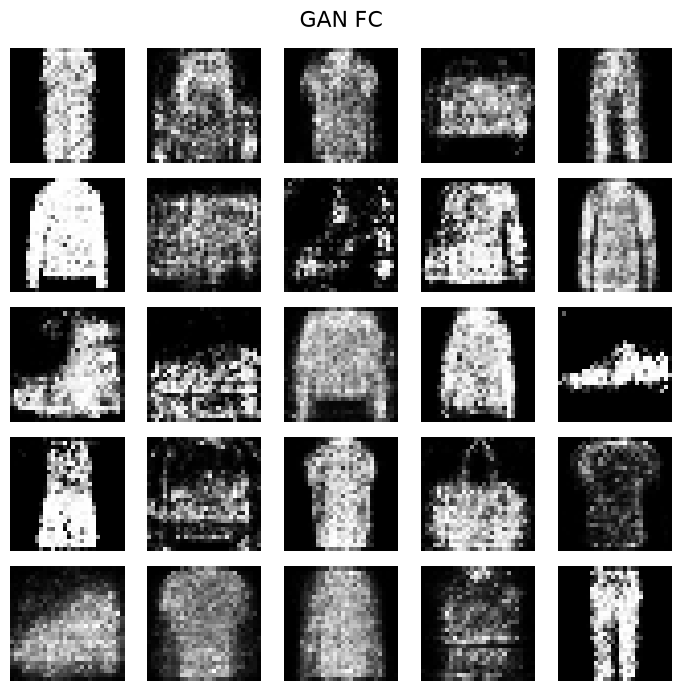

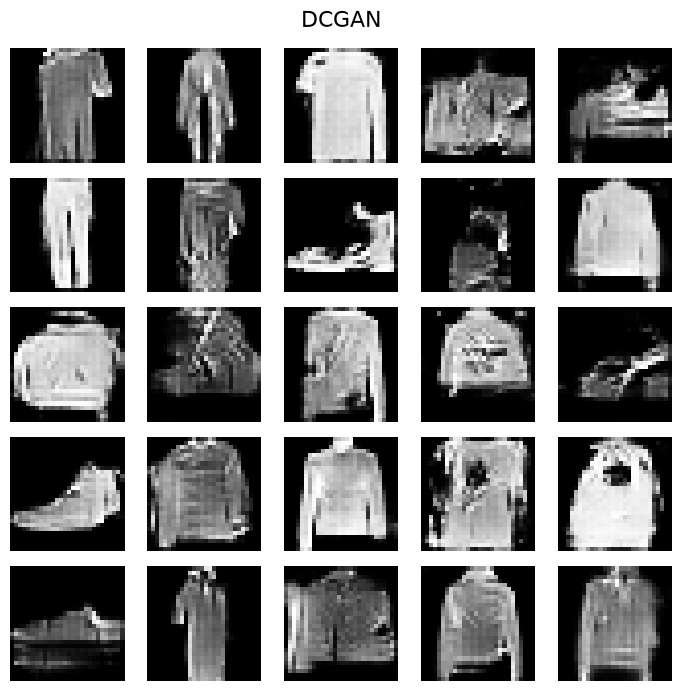

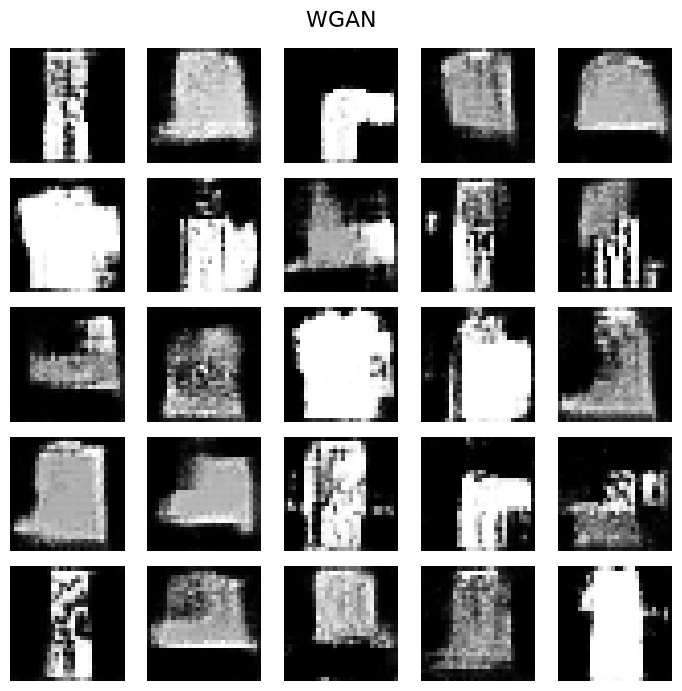

In [ ]:
for nome, experimento in experimentos.items():

    plotar_grade_amostras(
        gerador=experimento['gerador'],
        z=z_amostras,
        titulo=nome
    )

### 4.7. **Classificador**

#### 4.7.1. Estrutura do Classificador

In [ ]:
# Extrator de features
feature_extractor = nn.Sequential(
    nn.Conv2d(1, 32, 3), 
    nn.ReLU(), 
    nn.MaxPool2d(2),             # -> (B,32,13,13)
    nn.Conv2d(32, 64, 3), 
    nn.ReLU(), 
    nn.MaxPool2d(2),             # -> (B,64,5,5)
    nn.Conv2d(64, 128, 3), 
    nn.ReLU(),                   # -> (B,128,3,3)
    nn.AdaptiveAvgPool2d(1),     # -> (B,128,1,1)
    nn.Flatten()                 # -> (B,128)
).to(device)

# Cabeça classificadora
classifier_head = nn.Sequential(
    nn.Linear(128, 10)           # -> (B,10)
).to(device)

# Modelo completo
classifier_model = nn.Sequential(
    feature_extractor,
    classifier_head
).to(device)

#### 4.7.2. Função de Perda, Otimizador e Dataloaders

In [ ]:
loss_fn = nn.CrossEntropyLoss(reduction='sum')
optimizer = torch.optim.Adam(classifier_model.parameters(), lr=1e-3)

train_dl = DataLoader(
    fashion_mnist_dataset,
    batch_size=128,
    shuffle=True,
    drop_last=True
)

test_dl = DataLoader(
    fashion_mnist_test,
    batch_size=512,
    shuffle=False,
    drop_last=False
)

#### 4.7.3. Treinamento do Classificador

In [ ]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    model.train()                                              # Coloca o modelo em modo de treinamento.
    total_loss = 0.0                                           # Acumulador da perda total.
    total = 0                                                  # Número total de exemplos processados.
    accuracy = MulticlassAccuracy(num_classes=10,              # Métrica de acurácia para as 10 classes do Fashion MNIST.
        average='micro')                                       # Calcula a acurácia global considerando todos os exemplos.
    accuracy = accuracy.to(device)   
    for x, y in dataloader:                                    # Itera pelos lotes de dados.
        x, y = x.to(device), y.to(device)                      # Move entradas e rótulos para o dispositivo.
        optimizer.zero_grad(set_to_none=True)                  # Zera gradientes acumulados.
        logits = model(x)                                      # Calcula as predições do modelo.
        loss = loss_fn(logits, y)                              # Calcula a perda.
        loss.backward()                                        # Calcula os gradientes.
        optimizer.step()                                       # Atualiza os parâmetros.
        total_loss += loss.item()                              # Acumula a perda do lote.
        total += x.size(0)                                     # Acumula o número de exemplos.
        accuracy.update(logits, y)                             # Atualiza a métrica de acurácia.

    return (
        total_loss / total,
        accuracy.compute().item()
    )

In [ ]:
@torch.no_grad()
def evaluate(dataloader, model, loss_fn):
    model.eval()                                               # Coloca o modelo em modo de avaliação.
    total_loss = 0.0
    total = 0
    accuracy = MulticlassAccuracy(
        num_classes=10, 
        average='micro')                                       # Calcula a acurácia global considerando todos os exemplos.
    accuracy = accuracy.to(device)
    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total_loss += loss.item()
        total += x.size(0)
        accuracy.update(logits, y)

    return (
        total_loss / total,
        accuracy.compute().item()
    )

In [ ]:
n_epocas = 20

for ep in range(n_epocas):
    tr_loss, tr_acc = train_one_epoch(
        train_dl,
        classifier_model,
        loss_fn,
        optimizer
    )
    te_loss, te_acc = evaluate(
        test_dl,
        classifier_model,
        loss_fn
    )
    print(
        f'Época {ep + 1}/{n_epocas} | '
        f'Treinamento: perda={tr_loss:.4f} acc={tr_acc:.3f} | '
        f'Teste: perda={te_loss:.4f} acc={te_acc:.3f}'
    )

Época 1/20 | Treinamento: perda=0.7470 acc=0.728 | Teste: perda=0.6044 acc=0.774
Época 2/20 | Treinamento: perda=0.4993 acc=0.816 | Teste: perda=0.4689 acc=0.832
Época 3/20 | Treinamento: perda=0.4274 acc=0.846 | Teste: perda=0.4280 acc=0.845
Época 4/20 | Treinamento: perda=0.3803 acc=0.862 | Teste: perda=0.3865 acc=0.862
Época 5/20 | Treinamento: perda=0.3519 acc=0.874 | Teste: perda=0.3641 acc=0.868
Época 6/20 | Treinamento: perda=0.3272 acc=0.882 | Teste: perda=0.3520 acc=0.874
Época 7/20 | Treinamento: perda=0.3100 acc=0.887 | Teste: perda=0.3621 acc=0.864
Época 8/20 | Treinamento: perda=0.2937 acc=0.895 | Teste: perda=0.3161 acc=0.886
Época 9/20 | Treinamento: perda=0.2837 acc=0.897 | Teste: perda=0.3417 acc=0.876
Época 10/20 | Treinamento: perda=0.2715 acc=0.903 | Teste: perda=0.3141 acc=0.887
Época 11/20 | Treinamento: perda=0.2584 acc=0.905 | Teste: perda=0.3201 acc=0.886
Época 12/20 | Treinamento: perda=0.2524 acc=0.909 | Teste: perda=0.2958 acc=0.894
Época 13/20 | Treinamento

#### 4.7.4. Funções de apoio para extração de features

In [ ]:
@torch.no_grad()
def get_features(
    dataset,
    feature_extractor,
    N: int,
    batch_size: int = 512
) -> np.ndarray:

    feature_extractor.eval()                               # Coloca o extrator de características em modo de avaliação.

    N_eff = min(N, len(dataset))                           # Garante que N não ultrapasse o tamanho do dataset.

    subset = Subset(
        dataset,
        range(N_eff)
    )                                                      # Seleciona os primeiros N exemplos do dataset.

    loader = DataLoader(
        subset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False
    )                                                      # Cria um DataLoader sem embaralhar ou descartar amostras.

    feats_list = []                                        # Lista para acumular os vetores de características.

    for x, _ in loader:
        x = x.to(device)
        emb = feature_extractor(x)                         # Extrai features de dimensão 128.
        feats_list.append(
            emb.detach().cpu().numpy().astype(np.float32)
        )

    return np.concatenate(feats_list, axis=0)              # Retorna array de shape (N, 128).

In [ ]:
@torch.no_grad()
def get_features_from_generator(
    gen_model,
    feature_extractor,
    N: int,
    *,
    z_dim: int = z_dim,
    mode_z: str = mode_z,
    batch: int = 512,
    z_samples=None,
    image_shape=(1, 28, 28)
) -> np.ndarray:

    gen_model.eval()                                                # Coloca o gerador em modo de avaliação.
    feature_extractor.eval()                                        # Coloca o extrator em modo de avaliação.

    feats = []                                                      # Lista para acumular as features.
    processed = 0                                                   # Número de amostras já processadas.

    while processed < N:
        cur = min(batch, N - processed)                             # Define o tamanho do lote atual.
        
        if z_samples is None:
            z = create_noise(cur, z_dim, mode_z).to(device)         # Gera novos vetores latentes.
        else:
            z = z_samples[processed:processed + cur].to(device)     # Usa os vetores latentes previamente definidos.

        imgs = gen_model(z)                                         # Gera imagens sintéticas.
        emb = feature_extractor(imgs)                               # Extrai as características das imagens geradas.
        feats.append(
            emb.detach().cpu().numpy().astype(np.float32)
        )
        processed += cur

    return np.concatenate(feats, axis=0)                            # Retorna array no formato (N, D).

### 4.8. **Cálculo de MPR**

#### 4.8.1. Definição de parâmetros base para as variações do cálculo de MPR

In [ ]:
N_mpr = 10_000
batch_mpr = 512
ks_mpr = list(range(1, 11))

#### 4.8.2. Criação do conjunto de features extraídas de dados reais

In [ ]:

# Conjunto real exigido pelo enunciado: Fashion-MNIST de teste.
real_features = get_features(
    dataset=fashion_mnist_test,
    feature_extractor=feature_extractor,
    N=N_mpr,
    batch_size=batch_mpr
)

print("real_features shape:", real_features.shape)

real_features shape: (10000, 128)


#### 4.8.3. Criação do ruído a ser utilizado na geração de imagens

O mesmo ruído será utilizado para calcular as features dos três modelos.

In [ ]:
torch.manual_seed(42)

z_mpr = create_noise(
    N_mpr,
    z_dim,
    mode_z
)

#### 4.8.4. Criação das Imagens a partir dos modelos generativos e do ruído

In [ ]:
fake_features_por_modelo = {}

for nome, experimento in experimentos.items():

    fake_features_por_modelo[nome] = get_features_from_generator(
        gen_model=experimento['gerador'],
        feature_extractor=feature_extractor,
        N=N_mpr,
        z_dim=z_dim,
        mode_z=mode_z,
        batch=batch_mpr,
        z_samples=z_mpr,
        image_shape=image_shape
    )

    print(
        f'{nome}: '
        f'{fake_features_por_modelo[nome].shape}'
    )

GAN FC: (10000, 128)
DCGAN: (10000, 128)
WGAN: (10000, 128)


#### 4.8.5. Função de calculo do MPR para um dado K, Features reais e geradas

In [ ]:
def mpr_curve_by_k(real_feats, fake_feats, ks):

    precision = []
    recall = []

    for k in ks:

        print(f'Calculando MPR para k={k}...')

        metrics = compute_prdc(
            real_features=real_feats,
            fake_features=fake_feats,
            nearest_k=k
        )

        precision.append(metrics['precision'])
        recall.append(metrics['recall'])

    return np.array(recall), np.array(precision)

#### 4.8.6. Execução do cálculo de MPR para cada experimento

In [ ]:
mpr_por_modelo = {}

for nome, fake_features in fake_features_por_modelo.items():

    print(f'\n{nome}')

    recall, precision = mpr_curve_by_k(
        real_features,
        fake_features,
        ks_mpr
    )

    mpr_por_modelo[nome] = {
        'recall': recall,
        'precision': precision
    }


GAN FC
Calculando MPR para k=1...
Num real: 10000 Num fake: 10000
Calculando MPR para k=2...
Num real: 10000 Num fake: 10000
Calculando MPR para k=3...
Num real: 10000 Num fake: 10000
Calculando MPR para k=4...
Num real: 10000 Num fake: 10000
Calculando MPR para k=5...
Num real: 10000 Num fake: 10000
Calculando MPR para k=6...
Num real: 10000 Num fake: 10000
Calculando MPR para k=7...
Num real: 10000 Num fake: 10000
Calculando MPR para k=8...
Num real: 10000 Num fake: 10000
Calculando MPR para k=9...
Num real: 10000 Num fake: 10000
Calculando MPR para k=10...
Num real: 10000 Num fake: 10000

DCGAN
Calculando MPR para k=1...
Num real: 10000 Num fake: 10000
Calculando MPR para k=2...
Num real: 10000 Num fake: 10000
Calculando MPR para k=3...
Num real: 10000 Num fake: 10000
Calculando MPR para k=4...
Num real: 10000 Num fake: 10000
Calculando MPR para k=5...
Num real: 10000 Num fake: 10000
Calculando MPR para k=6...
Num real: 10000 Num fake: 10000
Calculando MPR para k=7...
Num real: 100

#### 4.8.7. Construção da Curva de MPR dos Experimentos

In [ ]:
def plot_mpr_curves(resultados, ks, title='Curva MPR variando k'):

    plt.figure(figsize=(8, 7))

    for nome, metricas in resultados.items():

        recall = metricas['recall']
        precision = metricas['precision']

        plt.plot(
            recall,
            precision,
            marker='o',
            label=nome
        )

        for r, p, k in zip(recall, precision, ks):
            plt.text(
                r,
                p,
                str(k),
                fontsize=8
            )

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.xlabel('Revocação')
    plt.ylabel('Precisão')
    plt.title(title)

    plt.grid(True)
    plt.legend()

    plt.show()

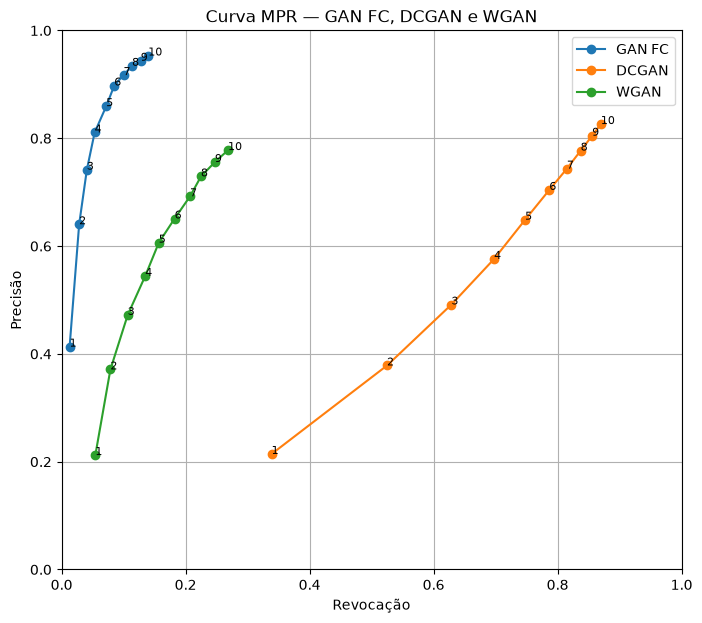

In [ ]:
plot_mpr_curves(
    mpr_por_modelo,
    ks_mpr,
    title='Curva MPR — GAN FC, DCGAN e WGAN'
)

#### 4.8.8. Calculo de MPR com variação de N e K

In [ ]:
def mpr_sweep_Nk(
    real_features,
    fake_features,
    Ns=(1000, 2500, 5000, 7500, 10000),
    ks=(3, 5, 10),
    *,
    model_name
) -> pd.DataFrame:

    linhas = []

    for N in Ns:

        real_feats_N = real_features[:N]
        fake_feats_N = fake_features[:N]

        for k in ks:

            metrics = compute_prdc(
                real_features=real_feats_N.astype(np.float32),
                fake_features=fake_feats_N.astype(np.float32),
                nearest_k=k
            )

            linhas.append({
                'modelo': model_name,
                'N': int(N),
                'k': int(k),
                'precision': float(metrics['precision']),
                'recall': float(metrics['recall'])
            })

            print(
                f'[modelo={model_name}] '
                f'N={N} | k={k} -> '
                f'Precisão={metrics["precision"]:.4f} | '
                f'Revocação={metrics["recall"]:.4f}'
            )

    return pd.DataFrame(linhas)

In [ ]:
Ns_sweep = [1000, 2500, 5000, 7500, 10000]
ks_sweep = [3, 5, 10]

dfs_mpr = []

for nome, fake_features in fake_features_por_modelo.items():

    df_modelo = mpr_sweep_Nk(
        real_features=real_features,
        fake_features=fake_features,
        Ns=Ns_sweep,
        ks=ks_sweep,
        model_name=nome
    )

    dfs_mpr.append(df_modelo)

df_mpr = pd.concat(
    dfs_mpr,
    ignore_index=True
)

display(df_mpr)

Num real: 1000 Num fake: 1000
[modelo=GAN FC] N=1000 | k=3 -> Precisão=0.8200 | Revocação=0.0670
Num real: 1000 Num fake: 1000
[modelo=GAN FC] N=1000 | k=5 -> Precisão=0.9130 | Revocação=0.1340
Num real: 1000 Num fake: 1000
[modelo=GAN FC] N=1000 | k=10 -> Precisão=0.9780 | Revocação=0.2820
Num real: 2500 Num fake: 2500
[modelo=GAN FC] N=2500 | k=3 -> Precisão=0.7900 | Revocação=0.0652
Num real: 2500 Num fake: 2500
[modelo=GAN FC] N=2500 | k=5 -> Precisão=0.8968 | Revocação=0.0980
Num real: 2500 Num fake: 2500
[modelo=GAN FC] N=2500 | k=10 -> Precisão=0.9704 | Revocação=0.1928
Num real: 5000 Num fake: 5000
[modelo=GAN FC] N=5000 | k=3 -> Precisão=0.7766 | Revocação=0.0472
Num real: 5000 Num fake: 5000
[modelo=GAN FC] N=5000 | k=5 -> Precisão=0.8856 | Revocação=0.0804
Num real: 5000 Num fake: 5000
[modelo=GAN FC] N=5000 | k=10 -> Precisão=0.9572 | Revocação=0.1630
Num real: 7500 Num fake: 7500
[modelo=GAN FC] N=7500 | k=3 -> Precisão=0.7625 | Revocação=0.0425
Num real: 7500 Num fake: 75

,modelo,N,k,precision,recall
0,GAN FC,1000,3,0.820000,0.067000
1,GAN FC,1000,5,0.913000,0.134000
2,GAN FC,1000,10,0.978000,0.282000
3,GAN FC,2500,3,0.790000,0.065200
4,GAN FC,2500,5,0.896800,0.098000
5,GAN FC,2500,10,0.970400,0.192800
6,GAN FC,5000,3,0.776600,0.047200
7,GAN FC,5000,5,0.885600,0.080400
8,GAN FC,5000,10,0.957200,0.163000
9,GAN FC,7500,3,0.762533,0.042533


#### 4.8.9. Exibição das Curvas de Precisão de Revocação com variação de N e K

In [ ]:
def plot_mpr_df(df: pd.DataFrame):

    modelos = df['modelo'].unique().tolist()                                      # Lista os nomes únicos de modelos presentes no DataFrame
    n_models = len(modelos)                                                       # Conta quantos modelos distintos existem

    fig, axes = plt.subplots(                                                     # Cria figura com subplots
        n_models, 2,                                                              # n_models linhas, 2 colunas (Precisão e Revocação)
        figsize=(12, 4 * n_models),                                               # Ajusta o tamanho da figura proporcional ao número de modelos
        dpi=110,                                                                  # Define resolução em pontos por polegada
        constrained_layout=True                                                   # Ajusta automaticamente os espaçamentos
    )

    if n_models == 1:                                                             # Caso haja apenas 1 modelo
        axes = np.array([axes])                                                   # Garante que axes seja indexável como array bidimensional

    for i, modelo in enumerate(modelos):                                          # Itera sobre cada modelo
        df_model = df[df['modelo'] == modelo].copy()                              # Filtra o DataFrame apenas para esse modelo

        ax_left = axes[i, 0]                                                      # Eixo à esquerda para precisão
        sns.lineplot(                                                             # Plota curva de precisão
            data=df_model, x='N', y='precision',
            hue='k', marker='o', ax=ax_left
        )
        ax_left.set_title(f'Precisão vs N ({modelo})')                            # Título do gráfico de precisão
        ax_left.set_xlabel('N (número de imagens reais = geradas)')               # Rótulo eixo X
        ax_left.set_ylabel('Precisão')                                            # Rótulo eixo Y
        ax_left.grid(True, linestyle='--', alpha=0.4)                             # Ativa grade com estilo tracejado
        ax_left.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')     # Legenda deslocada para a direita

        ax_right = axes[i, 1]                                                     # Eixo à direita para revocação
        sns.lineplot(                                                             # Plota curva de revocação
            data=df_model, x='N', y='recall',
            hue='k', marker='o', ax=ax_right
        )
        ax_right.set_title(f'Revocação vs N ({modelo})')                          # Título do gráfico de revocação
        ax_right.set_xlabel('N (número de imagens reais = geradas)')              # Rótulo eixo X
        ax_right.set_ylabel('Revocação')                                          # Rótulo eixo Y
        ax_right.grid(True, linestyle='--', alpha=0.4)                            # Ativa grade com estilo tracejado
        ax_right.legend(loc='center left', bbox_to_anchor=(1, 0.5), title='k')    # Legenda deslocada para a direita

    plt.show()                                                                    # Exibe a figura final com todos os subplots

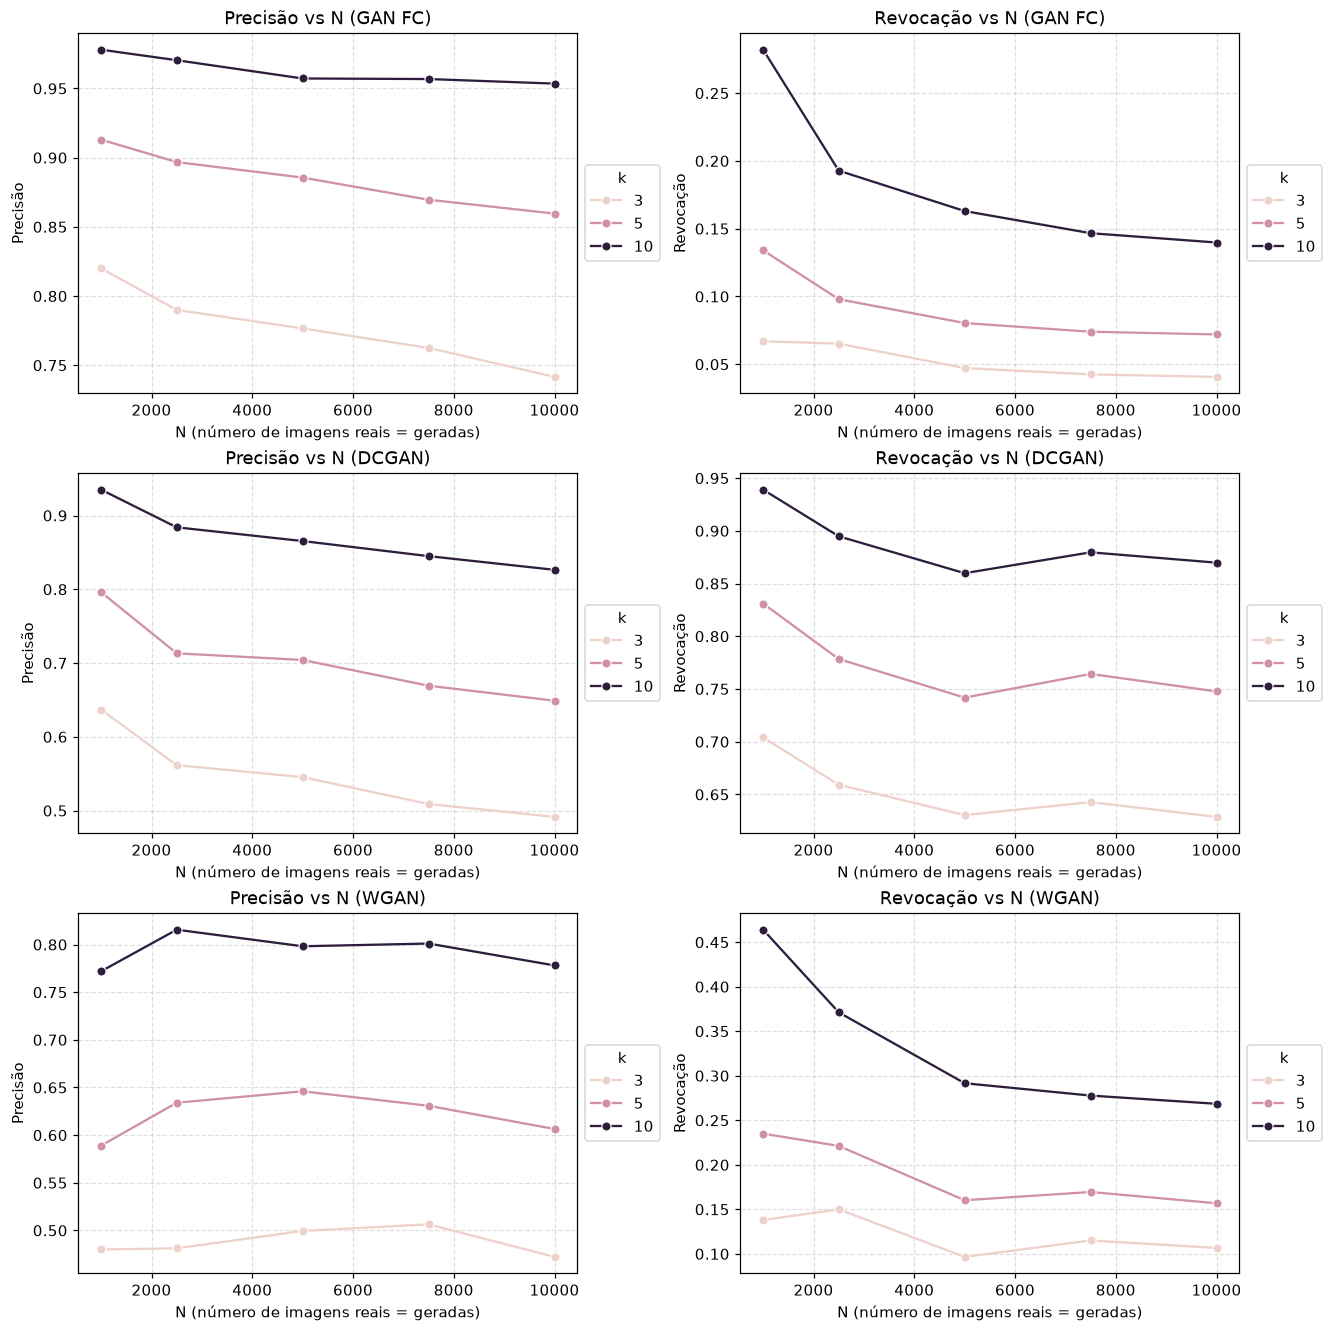

In [ ]:
plot_mpr_df(df_mpr)

## **Seção 5 — Modelos auto-regressivos com RNNs**

### 5.1. **Preparações Preliminares**

#### 5.1.1. **Importações**

In [1]:

import os                                           # módulo para interagir com o sistema de arquivos (criar pastas, ler arquivos, etc.)
import json                                         # para carregar e salvar dados em formato JSON
import re                                           # expressões regulares para manipulação e validação de strings
import string                                       # utilitários para strings (como lista de pontuações, letras, etc.)
from collections import Counter                     # estrutura de dados para contagem rápida de itens
import numpy as np                                  # biblioteca para cálculo numérico e operações com arrays
import torch                                        # PyTorch: framework de aprendizado profundo
import torch.nn as nn                               # módulos de construção de redes neurais (camadas, funções de perda, etc.)
from torch.utils.data import Dataset, DataLoader    # abstrações para datasets e carregamento de dados (batching, shuffle)
import torch.nn.functional as F                     # funções de ativação, perda e utilitários funcionais
from torchinfo import summary                       # para exibir o resumo ("summary") da arquitetura do modelo em PyTorch
from tqdm.auto import tqdm                          # barra de progresso adaptada ao ambiente (notebook/terminal) para loops longos
from torch.utils.data import random_split           # utilitário para dividir um Dataset em subconjuntos (ex.: treinamento/teste)
import matplotlib.pyplot as plt                     # biblioteca para gerar gráficos (ex.: curva de perda por época)
import gdown                                        # utilitário para baixar arquivos do Google Drive via link público
from pathlib import Path                            # para manipulação de caminhos de arquivos

/Users/gilcesarf/git/repositories/imd/imd3004-202602/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 5.1.2. Hiperparametros e outras constantes do laboratório

In [50]:
SEED          = 42      # Semente para garantir a reprodutibilidade dos resultados
VOCAB_SIZE    = 10_000  # tamanho máximo do vocabulário (número de tokens distintos considerados)
MAX_LEN       = 200     # comprimento máximo de cada sequência de entrada (número de tokens)
EMBEDDING_DIM = 100     # dimensão dos vetores de embedding que representam cada token
N_UNITS       = 128     # número de unidades (neurônios) na camada recorrente (LSTM/GRU/RNN)
BATCH_SIZE    = 32      # tamanho do lote (batch) usado em cada atualização de gradiente
EPOCHS        = 25      # número de épocas de treinamento (passadas completas pelo conjunto de treino)
LEARNING_RATE = 1e-3    # taxa de aprendizado do otimizador (passo de atualização dos parâmetros)

#### 5.1.3. Definição do dispositivo de computação

In [49]:

DEVICE = ( # dispositivo de computação: tipo de acelerador (GPU/MPS) se disponível, caso contrário "cpu"
    torch.accelerator.current_accelerator().type
    if torch.accelerator.is_available()
    else "cpu"
)

### 5.2. **Dados**

#### 5.2.1. Download dos dados

In [3]:
url = 'https://drive.google.com/file/d/1gzDjjou1lbCU87H_rDg5mhAJlkqTTqgn/view?usp=sharing'  # URL pública do arquivo no Google Drive
os.makedirs("data/", exist_ok=True)
output = 'data/full_format_recipes.json'                                                    # nome do arquivo local onde o JSON será salvo
if not os.path.isfile(output):                                                              # verifica se o arquivo ainda não existe no diretório atual
    print(f"Arquivo '{output}' não encontrado. Fazendo download...")                        # informa que o download será realizado
    gdown.download(
        url=url, 
        output=output, 
        quiet=False, 
    )                         # baixa o arquivo do Google Drive para o caminho especificado
else:
    print(f"Arquivo '{output}' já existe. Pulando download.")                               # informa que o arquivo já existe e evita novo download

with open(output) as json_data:           # abre o arquivo JSON de receitas em modo leitura
    recipe_data = json.load(json_data)    # carrega o conteúdo do arquivo como uma lista de dicionários


Arquivo 'data/full_format_recipes.json' já existe. Pulando download.


#### 5.2.2. Limpeza e preparação do dataset

##### 5.2.2.1. Filtra apenas os dados que possuem os campos `title` e `directions` diferente de vazio.

In [4]:
filtered_data = [                                                   # lista de strings (uma por receita) que será usada como corpus de texto
    "Recipe for " + x["title"] + " | " + " ".join(x["directions"])  # monta um texto único: título + '|' + instruções concatenadas
    for x in recipe_data                                            # percorre cada dicionário de receita carregado do JSON original
    if "title" in x                                                 # garante que a chave "title" existe no dicionário
    and x["title"] is not None                                      # garante que o título não é nulo
    and "directions" in x                                           # garante que a chave "directions" existe no dicionário
    and x["directions"] is not None                                 # garante que as instruções não são nulas
]

##### 5.2.2.2. Criação da Classe EpicuriousRecipesDataset

In [5]:
class EpicuriousRecipesDataset(Dataset):
    """
    Dataset de receitas do Epicurious para modelagem auto-regressiva.

    Esta classe:
    - normaliza e tokeniza textos de receitas (título + instruções),
    - constrói um vocabulário limitado ao `vocab_size` mais frequentes,
    - codifica cada texto como uma sequência fixa de IDs (com padding/truncamento),
    - fornece pares (x, y) para treinamento auto-regressivo, com y deslocado em 1 token.

    Parameters
    ----------
    texts : list of str
        Lista de textos brutos de entrada (uma string por receita).
    vocab_size : int, optional
        Tamanho máximo do vocabulário (incluindo os tokens especiais) (default = 10_000).
    max_len : int, optional
        Comprimento máximo das sequências (em tokens) usado para cada exemplo (default = 200).

    Attributes
    ----------
    max_len : int
        Comprimento máximo das sequências (sem contar o deslocamento extra, internamente usa max_len + 1).
    pad_id : int
        Índice reservado para o token de padding ``<PAD>``.
    unk_id : int
        Índice reservado para o token desconhecido ``<UNK>``.
    cleaned : list of str
        Lista de textos após normalização (pontuação separada e minúsculas).
    itos : list of str
        Vocabulário na ordem índice → token (index-to-string).
    stoi : dict
        Dicionário de token → índice (string-to-index).
    data : list of torch.Tensor
        Lista de tensores de inteiros com IDs de tokens, já com padding/truncamento aplicado.
    """
    def __init__(self, texts, vocab_size=10_000, max_len=200):
        """
        Inicializa o dataset de receitas para modelagem auto-regressiva.

        Parameters
        ----------
        texts : list of str
            Lista de textos brutos (uma string por receita), tipicamente "título | instruções".
        vocab_size : int, optional
            Tamanho máximo do vocabulário, incluindo os tokens especiais <PAD> e <UNK> (default = 10_000).
        max_len : int, optional
            Comprimento máximo da sequência de entrada (em tokens) usada por exemplo; internamente
            é construída uma sequência de tamanho ``max_len + 1`` para formar os pares (x, y) (default = 200).

            Exemplo
            -------
            Suponha `max_len = 4`. Depois de tokenizar/pad/truncar, para uma receita
            temos internamente uma sequência de 5 tokens:

                seq = [t0, t1, t2, t3, t4]  (tamanho = max_len + 1 = 5)

            A partir dela, construímos:

                x = seq[:-1] = [t0, t1, t2, t3]  (tamanho = max_len = 4)
                y = seq[1:]  = [t1, t2, t3, t4]  (tamanho = max_len = 4)

            Ou seja, para treinamento do modelo auto-regressivo, cada exemplo é um par:

                entrada: (x(0), x(1), ..., x(max_len - 1)) = (t0, t1, t2, t3)
                alvo:    (x(1), x(2), ..., x(max_len))     = (t1, t2, t3, t4)

        """

        self.cleaned = [self._pad_punct(text) for text in texts]         # gera lista de textos normalizados (minúsculas, pontuação e espaços tratados)

        # construção do vocabulário
        self.itos, self.stoi = self._build_vocab(self.cleaned,           # constrói o vocabulário a partir dos textos normalizados, retornando mapeamentos índice→token (itos) e token→índice (stoi)
                                                vocab_size,
                                                pad_token="<PAD>",
                                                unk_token="<UNK>")
        self.pad_id = self.stoi["<PAD>"]                                # índice (= 0) reservado para o token de padding <PAD> (usado para preencher sequências curtas até o comprimento fixo)
        self.unk_id = self.stoi["<UNK>"]                                # índice (= 1) reservado para o token desconhecido <UNK> ( usado quando um token não existe no vocabulário aprendido)

        self.max_len = max_len                                          # comprimento máximo da sequência (número de tokens considerados por exemplo)
        self.data = self._encode_and_pad()                              # codifica textos normalizados em IDs e aplica padding/truncamento para max_len + 1

    @staticmethod
    def _pad_punct(s: str) -> str:
        """
        Normaliza uma string (letras minúsculas, tratamento sistemático da pontuação e de espaços).

        Parameters
        ----------
        s : str
            String a ser normalizada.

        Returns
        -------
        str
            String normalizada.
        """
        s = re.sub(f"([{re.escape(string.punctuation)}])", r" \1 ", s)  # insere espaço ao redor de cada sinal de pontuação
        s = re.sub(" +", " ", s).lower()                                # reduz múltiplos espaços a um único espaço e converte todas as letras para minúsculas
        return s

    @staticmethod
    def _build_vocab(cleaned_texts, vocab_size, pad_token="<PAD>", unk_token="<UNK>"):
        """
        Constrói o vocabulário a partir de uma lista de textos normalizados.

        Parameters
        ----------
        cleaned_texts : list of str
            Lista de strings normalizadas.
        vocab_size : int
            Tamanho máximo do vocabulário (incluindo tokens especiais).
        pad_token : str, optional
            Token especial usado para padding (default = "<PAD>").
        unk_token : str, optional
            Token especial usado para tokens desconhecidos (default = "<UNK>").

        Returns
        -------
        itos : list of str
            Lista de tokens na ordem índice → token.
        stoi : dict
            Dicionário token → índice.
        """

        # contabiliza a frequência global de cada token no corpus
        counter = Counter()                                             # contador de frequência de tokens no corpus
        for text in cleaned_texts:                                      # percorre cada texto normalizado
            counter.update(text.split())                                # atualiza o contador com os tokens desse texto

        # seleciona os tokens mais comuns, reservando 2 posições para pad_token e unk_token
        most_common = counter.most_common(vocab_size - 2)               # pega os (vocab_size-2) tokens mais frequentes

        # lista que mapeia índice -> token
        itos = [pad_token, unk_token] + [w for w, _ in most_common]     # cria lista de tokens na ordem dos índices

        # dicionário que mapeia token -> índice
        stoi = {w: i for i, w in enumerate(itos)}                       # cria mapeamento inverso de token para índice

        return itos, stoi

    def _encode_and_pad(self):
            """
            Converte os textos normalizados em sequências de IDs com tamanho fixo (max_len + 1).

            Usa:
            - self.cleaned : lista de textos normalizados;
            - self.stoi    : dicionário token → índice;
            - self.pad_id  : índice do token <PAD>;
            - self.unk_id  : índice do token <UNK>;
            - self.max_len : comprimento máximo da sequência de entrada.

            Returns
            -------
            list of torch.Tensor
                Lista de tensores de inteiros com IDs de tokens,
                todos com comprimento ``self.max_len + 1``.
            """

            data = []                                                           # lista que armazenará as sequências tokenizadas como tensores

            for text in self.cleaned:                                           # percorre cada texto normalizado

                tokens = text.split()                                           # divide o texto em tokens por espaço

                ids = [self.stoi.get(t, self.unk_id) for t in tokens]           # converte tokens em IDs, usando unk_id quando token não está no vocabulário

                if len(ids) < (self.max_len + 1):                               # verifica se a sequência é menor que o tamanho desejado (max_len + 1)
                    ids += [self.pad_id] * ((self.max_len + 1) - len(ids))      # se a sequência for curta, completa a sequência com <PAD> até o comprimento fixo (max_len + 1)
                else:
                    ids = ids[: (self.max_len + 1)]                             # se a sequência for longa, recorta a sequência para o tamanho máximo permitido (max_len + 1 )

                data.append(torch.tensor(ids, dtype=torch.long))                # converte a sequência para tensor de inteiros (IDs de tokens) e adiciona à lista
            return data

    def __len__(self):
        """
        Retorna o número de exemplos disponíveis no dataset.

        Returns
        -------
        int
            Quantidade de sequências armazenadas em ``self.data``.
        """
        return len(self.data)  # número total de exemplos (sequências) no dataset

    def __getitem__(self, idx):
        """
        Retorna o par (x, y) no índice especificado, para treinamento auto-regressivo.

        Para uma sequência interna de tamanho ``max_len + 1``, este método produz:
        - x: tokens de posição 0 até max_len - 1
        - y: tokens de posição 1 até max_len

        Ou seja, y é a mesma sequência de x deslocada em 1 passo para a direita, o que
        permite treinar o modelo a prever o próximo token a cada posição.

        Parameters
        ----------
        idx : int
            Índice do exemplo desejado no dataset.

        Returns
        -------
        x : torch.Tensor
            Tensor de inteiros de forma ``[max_len]`` contendo os tokens de entrada.
        y : torch.Tensor
            Tensor de inteiros de forma ``[max_len]`` contendo os tokens-alvo (sequência deslocada).
        """
        seq = self.data[idx]   # sequência completa de IDs para este exemplo (tamanho max_len + 1)
        x = seq[:-1]           # entrada: todos os tokens exceto o último (posição 0 até max_len - 1)
        y = seq[1:]            # alvo: todos os tokens exceto o primeiro (posição 1 até max_len)
        return x, y            # retorna o par (x, y) = (entrada, alvo) para modelagem auto-regressiva


##### 5.2.2.3.  Instanciação do Dataset a partir dos dados filtrados

In [6]:
ds = EpicuriousRecipesDataset(
    filtered_data,
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN
)

##### 5.2.2.4. Separação dos datasets de treino e teste

In [7]:
N = len(ds)                                                # número total de exemplos disponíveis no dataset completo
N_train = int(0.9 * N)                                     # define 90% dos exemplos para o conjunto de treinamento
N_test  = N - N_train                                      # define os 10% restantes para o conjunto de teste

train_ds, test_ds = random_split(
    dataset=ds,
    lengths=[N_train, N_test],                             # tamanhos desejados para os subconjuntos (treinamento e teste)
    generator=torch.Generator().manual_seed(SEED)          # fixa a semente para obter sempre o mesmo split (reprodutibilidade)
)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)   # DataLoader de treinamento: agrupa exemplos em lotes e embaralha a cada época
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)  # DataLoader de teste: agrupa exemplos em lotes, mantendo a ordem fixa


### 5.3. Redes Neurais ( `RNNModel` )

A classe fornecida como exemplo pelo professor no laboratório foi ligeiramente adaptada para permitir instanciação dos três diferentes tipos de camada recorrente: RNN clássica, LSTM e GRU. Dessa forma simplificaremos o loop de treinamento e configuração dos experimentos, permitindo também num único loop de treinamento executar os três experimentos solicitados.

In [8]:
class RNNModel(nn.Module):
    """
    Modelo auto-regressivo baseado em redes neurais recorrentes.

    A arquitetura é composta por:
    1. uma camada de embedding, que transforma índices de tokens em vetores densos;
    2. uma camada recorrente, que pode ser LSTM, GRU ou RNN clássica;
    3. uma camada linear, que projeta os estados ocultos para o vocabulário.

    Parameters
    ----------
    vocab_size : int
        Tamanho do vocabulário.
    embedding_dim : int
        Dimensão dos vetores de embedding.
    hidden_size : int
        Número de unidades da camada recorrente.
    rnn_type : str
        Tipo de camada recorrente utilizada: "lstm", "gru" ou "rnn".
    """

    def __init__(
        self,
        vocab_size: int,
        embedding_dim: int,
        hidden_size: int,
        rnn_type: str
    ) -> None:

        super().__init__()

        # Camada de embedding: transforma cada índice de token em um vetor
        # denso de dimensão embedding_dim. O índice 0 corresponde ao padding.
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # Camada recorrente. A arquitetura utilizada é determinada por rnn_type,
        # mantendo os mesmos valores de entrada e hidden_size para permitir uma
        # comparação direta entre LSTM, GRU e RNN clássica.
        if rnn_type == "lstm":

            self.rnn = nn.LSTM(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                batch_first=True
            )

        elif rnn_type == "gru":

            self.rnn = nn.GRU(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                batch_first=True
            )

        elif rnn_type == "rnn":

            self.rnn = nn.RNN(
                input_size=embedding_dim,
                hidden_size=hidden_size,
                nonlinearity="tanh",
                batch_first=True
            )

        else:
            raise ValueError(
                f"Tipo de RNN inválido: {rnn_type}. "
                'Use "lstm", "gru" ou "rnn".'
            )

        # Camada linear final: projeta, para cada posição da sequência,
        # o estado oculto produzido pela camada recorrente para o espaço
        # do vocabulário.
        self.fc = nn.Linear(
            in_features=hidden_size,
            out_features=vocab_size
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Executa a propagação direta do modelo.

        Parameters
        ----------
        x : torch.Tensor
            Tensor contendo índices de tokens com shape (B, S), onde
            B é o tamanho do lote e S é o comprimento da sequência.

        Returns
        -------
        torch.Tensor
            Logits com shape (B, S, V), onde V é o tamanho do vocabulário.
        """

        # Converte os índices dos tokens em embeddings:
        # (B, S) -> (B, S, embedding_dim).
        emb = self.embedding(x)

        # Processa toda a sequência pela camada recorrente.
        # A saída contém um estado oculto para cada posição:
        # (B, S, embedding_dim) -> (B, S, hidden_size).
        #
        # O segundo valor retornado corresponde aos estados finais da camada
        # recorrente e não é necessário para a previsão token a token.
        output, _ = self.rnn(emb)

        # Projeta cada estado oculto para o vocabulário:
        # (B, S, hidden_size) -> (B, S, vocab_size).
        logits = self.fc(output)

        return logits

### 5.4. Treinamento

#### 5.4.1. Cálculo do negativo da logaritmo da verossimilhança (negative log-likelihood - NLL)

In [9]:
def compute_nll(logits, targets, loss_fn):
    """
    Calcula o negativo do logaritmo da verossimilhança (negative log-likelihood - NLL) agregada sobre todos os tokens do batch,
    reformatando logits e alvos para o shape esperado por CrossEntropyLoss.

    Parameters
    ----------
    logits : torch.Tensor
        Tensor de logits com shape [B, L, V], onde:
        B = batch_size, L = comprimento da sequência, V = tamanho do vocabulário.
    targets : torch.Tensor
        Tensor de alvos com shape [B, L], contendo IDs de tokens.
    loss_fn : torch.nn.Module
        Instância de função de perda (ex.: nn.CrossEntropyLoss)

    Returns
    -------
    torch.Tensor
        Escalar com a perda NLL agregada de acordo com o `reduction` da loss_fn.
    """
    B, L, V = logits.shape                          # B: batch_size, L: seq_len, V: vocab_size
    loss = loss_fn(
        logits.view(B * L, V),   # reshape de [B, L, V] -> [N, C], onde:
                                    #   N = B*L (um "exemplo" por token do lote)
                                    #   C = V   (número de classes = tamanho do vocabulário)
                                    # CrossEntropyLoss espera entradas nesse formato [N, C].
        targets.view(B * L)      # reshape de [B, L] -> [N], com:
                                    #   N = B*L (um rótulo inteiro para cada token do lote)
                                    # CrossEntropyLoss espera alvos 1D [N] alinhados com as linhas de input.
    )
    return loss

#### 5.4.2. Função que executa o treinamento de um modelo específico ( instância de `RNNModel` )

In [10]:
def train_autoregressive_model(model, train_dl):
    """
    Treina um modelo auto-regressivo (LSTM/GRU/RNN clássica) em um DataLoader de pares (x, y).

    Cada exemplo do DataLoader deve ter o formato:
    - x: tensor [B, L] com IDs de tokens de entrada;
    - y: tensor [B, L] com IDs de tokens-alvo, deslocados em 1 passo no tempo
         (ou seja, y contém os "próximos tokens" que o modelo deve prever).

    A função treina o modelo por EPOCHS épocas e devolve, para cada época,
    a perda média de treinamento (NLL média por token não-PAD, de acordo com CrossEntropyLoss).

    Parameters
    ----------
    model : torch.nn.Module
        Modelo recorrente (por exemplo, LSTM, GRU ou RNN clássica) que recebe
        tensores [B, L] e retorna logits [B, L, V], onde V é o tamanho do vocabulário.
    train_dl : torch.utils.data.DataLoader
        DataLoader que produz lotes (x_batch, y_batch) de tensores inteiros com IDs
        de tokens de entrada e de tokens-alvo.

    Returns
    -------
    list of float
        Lista contendo a perda média de treinamento em cada época.
    """

    model.to(DEVICE)                                                        # garante que o modelo está no mesmo dispositivo dos lotes (CPU ou GPU)

    loss_fn = nn.CrossEntropyLoss(ignore_index=0, reduction="mean")         # função de perda: entropia cruzada ignorando o token <PAD> (ID 0) no cálculo da média

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)      # otimizador Adam com taxa de aprendizado definida em LEARNING_RATE

    epoch_losses = []                                                       # lista para armazenar a perda média de cada época


    pbar = tqdm(range(1, EPOCHS + 1), desc="Época", unit="época") # barra de progresso sobre as épocas

    for epoch in pbar:                                      # loop externo sobre as épocas de treinamento

        model.train()                                                       # coloca o modelo em modo de treinamento
        running_loss = 0.0                                                  # acumulador da perda ao longo dos lotes desta época

        for x_batch, y_batch in train_dl:                                   # loop interno sobre os lotes produzidos pelo DataLoader de treino

            x_batch = x_batch.to(DEVICE)                                    # envia o lote de entradas para o dispositivo (forma: [B, L])
            y_batch = y_batch.to(DEVICE)                                    # envia o lote de alvos para o dispositivo (forma: [B, L])

            logits = model(x_batch)                                         # obtém logits do modelo: [B, L, V] (um vetor de logits por token)
            loss = compute_nll(logits, y_batch, loss_fn)                    # calcula a NLL agregada de acordo com o reduction da loss_fn (aqui: média por token não-PAD)
            loss.backward()                                                 # calcula gradientes da loss em relação aos parâmetros do modelo
            optimizer.step()                                                # atualiza os parâmetros do modelo usando os gradientes
            optimizer.zero_grad()                                           # zera gradientes acumulados de iterações anteriores

            running_loss += loss.item()                                     # acumula o valor escalar da perda deste lote

        avg_loss = running_loss / len(train_dl)                             # perda média da época (média das losses de todos os lotes)
        epoch_losses.append(avg_loss)                                       # armazena a perda média desta época

        # print(f"Epoch {epoch:>2}, train loss: {avg_loss:.4f}")              # imprime o progresso do treinamento

        pbar.set_postfix({"função de perda": f"{avg_loss:.4f}"})            # atualiza o texto da barra de progresso com a loss da época

    return epoch_losses                                                     # retorna a lista com a perda média de cada época

#### 5.4.3. Exibição das top K palavras mais prováveis em um passo qualquer

In [11]:
def print_probs_pt(info, itos, top_k=5):
    """
    Mostra, para cada passo de geração, as top_k palavras mais prováveis
    de acordo com o vetor de probabilidades armazenado.

    Parameters
    ----------
    info : list of dict
        Lista retornada por TextGenerator.generate(), onde cada item contém:
        - "prompt": texto gerado até aquele passo;
        - "word_probs": vetor numpy com probabilidades sobre o vocabulário;
        - "selected_idx": índice do token selecionado naquele passo;
        - "selected_word": token selecionado naquele passo.

    itos : list of str
        Lista índice -> token (index-to-string) usada para mapear IDs de volta a palavras.
    top_k : int, optional
        Número de tokens mais prováveis a serem exibidos em cada passo.
        (default = 5)
    """
    for step in info:                                      # percorre cada passo registrado na geração
        prompt = step["prompt"]                            # texto corrente até aquele passo
        word_probs = step["word_probs"]                    # vetor numpy com probabilidade de cada token


        idx_sorted = np.argsort(word_probs)[::-1][:top_k]  # obtém os índices dos top_k tokens mais prováveis (ordem decrescente de probabilidade)
        p_sorted = word_probs[idx_sorted]                  # probabilidades correspondentes aos índices top_k

        print(f"\nPROMPT: {prompt}")
        for idx, p in zip(idx_sorted, p_sorted):           # percorre cada token entre os mais prováveis
            token = itos[idx]                              # converte índice em token de texto
            print(f"{token:<15} {p*100:6.2f}%")            # imprime token justificado e probabilidade em porcentagem
        print("--------\n")                                # separador visual entre passos

#### 5.4.4. Cálculo da Perplexidade média por token para um modelo específico ( instância de `RNNModel` )

In [12]:
def compute_perplexity(model, data_loader):
    """
    Calcula a perplexidade de um modelo auto-regressivo em um conjunto de dados.

    A função percorre todos os lotes do data_loader, acumula a soma do NLL
    sobre todos os tokens não-PAD e, ao final, computa:

        avg_nll = NLL média por token
        perplexity = exp(avg_nll)

    Parameters
    ----------
    model : torch.nn.Module
        Modelo já treinado que recebe tensores [B, L] e retorna logits [B, L, V].
    data_loader : torch.utils.data.DataLoader
        DataLoader com lotes (x_batch, y_batch) usados para avaliação.

    Returns
    -------
    tuple of float
        avg_nll : NLL média por token não-PAD.
        ppl     : perplexidade correspondente (exp(avg_nll)).
    """

    model.eval()                                               # coloca o modelo em modo de avaliação
    total_loss = torch.tensor(0.0, device=DEVICE)              # acumula a soma da NLL sobre todos os tokens não-PAD
    total_tokens = torch.tensor(0.0, device=DEVICE)            # acumula o número total de tokens não-PAD usados no cálculo

    loss_fn = nn.CrossEntropyLoss(ignore_index=0,              # entropia cruzada ignorando o token <PAD> (ID 0)
                                  reduction="sum")             # reduction="sum": retorna a soma da NLL sobre os tokens válidos do lote

    with torch.no_grad():                                      # bloco sem cálculo de gradiente (apenas avaliação)
        for x_batch, y_batch in data_loader:                   # percorre todos os lotes (x, y) do data_loader
            x_batch = x_batch.to(DEVICE)                       # move o lote de entradas para o dispositivo
            y_batch = y_batch.to(DEVICE)                       # move o lote de alvos para o dispositivo

            logits = model(x_batch)                            # obtém logits do modelo: [B, L, V]

            loss = compute_nll(logits, y_batch, loss_fn)       # NLL somada sobre todos os tokens não-PAD do lote (escalares)

            total_loss += loss                                 # acumula a soma das perdas de todos os lotes
            total_tokens += (y_batch != 0).sum()               # acumula quantos tokens não são <PAD> (ID 0) em todo o data_loader

    avg_nll = total_loss / total_tokens                        # NLL média por token não-PAD em todo o conjunto avaliado
    ppl = torch.exp(avg_nll)                                   # perplexidade = exp(NLL média por token)

    return avg_nll.item(), ppl.item()                          # devolve valores escalares em float (para impressão / logging)

#### 5.4.5. Salvamento e Recuperação de Checkpoints

##### 5.4.5.1. Garante que o diretório de checkpoints existe

In [13]:
# Diretório utilizado para armazenar os checkpoints dos modelos treinados.
CHECKPOINT_DIR = Path("checkpoints")

# Cria o diretório e seus diretórios-pai caso ainda não existam.
# O parâmetro exist_ok=True evita erro quando o diretório já existe.
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

##### 5.4.5.2. Retorna o nome do checkpoint conforme o tipo de modelo

In [14]:
def get_rnn_checkpoint_path(rnn_type):
    """
    Retorna o caminho do checkpoint correspondente a um modelo
    recorrente do Laboratório 5.

    Parameters
    ----------
    rnn_type : str
        Tipo da camada recorrente utilizada: "lstm", "gru" ou "rnn".

    Returns
    -------
    pathlib.Path
        Caminho do arquivo utilizado para persistir o checkpoint.
    """

    # Utiliza o identificador do laboratório como prefixo para evitar
    # colisões com checkpoints de experimentos passados ou futuros.
    return CHECKPOINT_DIR / f"lab5-{rnn_type}.pt"

##### 5.4.5.3. Salva um checkpoint

In [15]:
def save_rnn_checkpoint(rnn_type, model, results):
    """
    Salva o estado de um modelo recorrente e os resultados obtidos
    durante seu treinamento e avaliação.

    O checkpoint contém os pesos treinados, os parâmetros necessários
    para reconstruir a arquitetura e as métricas utilizadas nas análises
    posteriores. Os resultados da geração de texto não são armazenados,
    pois podem ser reproduzidos rapidamente a partir do modelo treinado.

    Parameters
    ----------
    rnn_type : str
        Tipo da camada recorrente utilizada: "lstm", "gru" ou "rnn".
    model : torch.nn.Module
        Modelo treinado que será armazenado.
    results : dict
        Resultados obtidos durante o treinamento e a avaliação.
    """

    # Agrupa em um único objeto todas as informações necessárias para
    # reconstruir o modelo e recuperar os resultados do treinamento.
    checkpoint = {

        # Identifica a arquitetura recorrente utilizada.
        "rnn_type": rnn_type,

        # Armazena os hiperparâmetros necessários para reconstruir
        # exatamente a arquitetura do modelo.
        "vocab_size": VOCAB_SIZE,
        "embedding_dim": EMBEDDING_DIM,
        "hidden_size": N_UNITS,

        # Armazena somente os parâmetros aprendidos pelo modelo.
        # O state_dict evita serializar diretamente a implementação
        # completa da classe.
        "model_state_dict": model.state_dict(),

        # Histórico utilizado para reconstruir as curvas de treinamento.
        "losses": results.get("losses"),

        # Métricas calculadas sobre o conjunto de teste.
        "nll": results.get("nll"),
        "ppl": results.get("ppl"),

        # Quantidade de parâmetros treináveis do modelo.
        "num_params": results.get("num_params")
    }

    # Obtém o caminho padronizado do checkpoint do Laboratório 5.
    checkpoint_path = get_rnn_checkpoint_path(rnn_type)

    # Persiste o checkpoint no disco.
    torch.save(
        checkpoint,
        checkpoint_path
    )

    print(f"Checkpoint salvo: {checkpoint_path}")

##### 5.4.5.4. Recupera um checkpoint

In [16]:
def load_rnn_checkpoint(rnn_type):
    """
    Carrega um checkpoint e reconstrói o modelo recorrente correspondente.

    O modelo é inicialmente reconstruído na CPU e, depois que seus pesos
    são restaurados, é movido para o dispositivo configurado no notebook.

    Parameters
    ----------
    rnn_type : str
        Tipo da camada recorrente utilizada: "lstm", "gru" ou "rnn".

    Returns
    -------
    model : RNNModel
        Modelo reconstruído com os pesos obtidos durante o treinamento.
    results : dict
        Resultados armazenados durante o treinamento e a avaliação.
    """

    # Obtém o caminho padronizado do checkpoint do Laboratório 5.
    checkpoint_path = get_rnn_checkpoint_path(rnn_type)

    # Carrega inicialmente o checkpoint na CPU para que o arquivo
    # não dependa do dispositivo utilizado durante o treinamento.
    checkpoint = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    # Reconstrói a arquitetura utilizando os mesmos hiperparâmetros
    # registrados quando o modelo foi treinado.
    model = RNNModel(
        vocab_size=checkpoint["vocab_size"],
        embedding_dim=checkpoint["embedding_dim"],
        hidden_size=checkpoint["hidden_size"],
        rnn_type=checkpoint["rnn_type"]
    )

    # Restaura os parâmetros aprendidos durante o treinamento.
    model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    # Move o modelo para o dispositivo configurado na execução atual.
    model = model.to(DEVICE)

    # Reconstrói a estrutura esperada pelo restante do notebook.
    results = {
        "model": model,
        "losses": checkpoint["losses"],
        "nll": checkpoint["nll"],
        "ppl": checkpoint["ppl"],
        "num_params": checkpoint["num_params"]
    }

    return model, results

#### 5.4.6. Execução do treinamento

##### 5.4.6.1. Inicialização de variáveis

In [17]:
# Tipos de redes recorrentes que serão comparados.
RNN_TYPES = ["lstm", "gru", "rnn"]

# Dicionário que concentra os modelos e os resultados produzidos
# por cada uma das arquiteturas recorrentes.
resultados_rnn = {}

##### 5.4.6.2. Treinamento dos modelos

In [18]:
# Executa o mesmo experimento para LSTM, GRU e RNN clássica.
for rnn_type in RNN_TYPES:

    # Obtém o caminho padronizado do checkpoint correspondente
    # ao modelo recorrente atual.
    checkpoint_path = get_rnn_checkpoint_path(rnn_type)

    print("\n" + "=" * 70)
    print(f"MODELO: {rnn_type.upper()}")
    print("=" * 70)

    # Verifica se este experimento já foi executado anteriormente.
    # Quando o checkpoint existe, o treinamento é evitado e os pesos
    # e resultados armazenados são simplesmente restaurados.
    if checkpoint_path.exists():

        print(f"Checkpoint encontrado: {checkpoint_path}")
        print("Carregando modelo treinado...")

        # Reconstrói o modelo e recupera os resultados armazenados
        # durante a execução anterior.
        model, results = load_rnn_checkpoint(
            rnn_type
        )

        # Restaura a mesma estrutura de dados utilizada quando o
        # treinamento é realizado diretamente nesta execução.
        resultados_rnn[rnn_type] = results

        print("Modelo carregado com sucesso.")

    else:

        print("Checkpoint não encontrado.")
        print(f"Treinando modelo {rnn_type.upper()}...")

        # Reinicia a semente imediatamente antes da criação de cada
        # modelo para tornar sua inicialização reproduzível e atender
        # ao requisito de utilizar a mesma semente nos experimentos.
        torch.manual_seed(SEED)

        # Cria uma nova instância utilizando os mesmos hiperparâmetros
        # para todos os experimentos. Apenas o tipo da camada recorrente
        # é alterado entre LSTM, GRU e RNN clássica.
        model = RNNModel(
            vocab_size=VOCAB_SIZE,
            embedding_dim=EMBEDDING_DIM,
            hidden_size=N_UNITS,
            rnn_type=rnn_type
        ).to(DEVICE)

        # Treina o modelo utilizando o mesmo conjunto de treinamento
        # e os mesmos hiperparâmetros definidos para os três experimentos.
        losses = train_autoregressive_model(
            model,
            train_dl
        )

        # Calcula a NLL média e a perplexidade sobre o mesmo conjunto
        # de teste utilizado na avaliação das três arquiteturas.
        test_nll, test_ppl = compute_perplexity(
            model,
            test_dl
        )

        # Conta somente os parâmetros que participam do treinamento.
        # Essa informação também será utilizada posteriormente na
        # comparação com os modelos MiniGPT do Laboratório 6.
        num_params = sum(
            parameter.numel()
            for parameter in model.parameters()
            if parameter.requires_grad
        )

        # Armazena em memória o modelo e todos os resultados necessários
        # para reconstruir posteriormente as análises e os gráficos.
        resultados_rnn[rnn_type] = {
            "model": model,
            "losses": losses,
            "nll": test_nll,
            "ppl": test_ppl,
            "num_params": num_params
        }

        # Salva imediatamente o experimento depois que o treinamento
        # e a avaliação terminam. Caso a execução seja interrompida
        # durante outro modelo, este não precisará ser treinado novamente.
        save_rnn_checkpoint(
            rnn_type,
            model,
            resultados_rnn[rnn_type]
        )

    # Recupera os resultados independentemente de terem sido produzidos
    # nesta execução ou restaurados de um checkpoint anterior.
    results = resultados_rnn[rnn_type]

    # Exibe as principais métricas para confirmar o resultado carregado
    # ou recém-calculado para a arquitetura atual.
    print(
        f"\n{rnn_type.upper():4s} | "
        f"NLL: {results['nll']:.4f} | "
        f"PPL: {results['ppl']:.2f} | "
        f"Parâmetros: {results['num_params']:,}"
    )


MODELO: LSTM
Checkpoint não encontrado.
Treinando modelo LSTM...


Época: 100%|██████████| 25/25 [06:30<00:00, 15.61s/época, função de perda=2.1231]


Checkpoint salvo: checkpoints/lab5-lstm.pt

LSTM | NLL: 2.3420 | PPL: 10.40 | Parâmetros: 2,407,760

MODELO: GRU
Checkpoint não encontrado.
Treinando modelo GRU...


Época: 100%|██████████| 25/25 [14:26<00:00, 34.68s/época, função de perda=2.1056]


Checkpoint salvo: checkpoints/lab5-gru.pt

GRU  | NLL: 2.3433 | PPL: 10.42 | Parâmetros: 2,378,320

MODELO: RNN
Checkpoint não encontrado.
Treinando modelo RNN...


Época: 100%|██████████| 25/25 [09:29<00:00, 22.77s/época, função de perda=2.3767]


Checkpoint salvo: checkpoints/lab5-rnn.pt

RNN  | NLL: 2.5887 | PPL: 13.31 | Parâmetros: 2,319,440


### 5.5. Comparação das curvas de perda de treinamento dos modelos

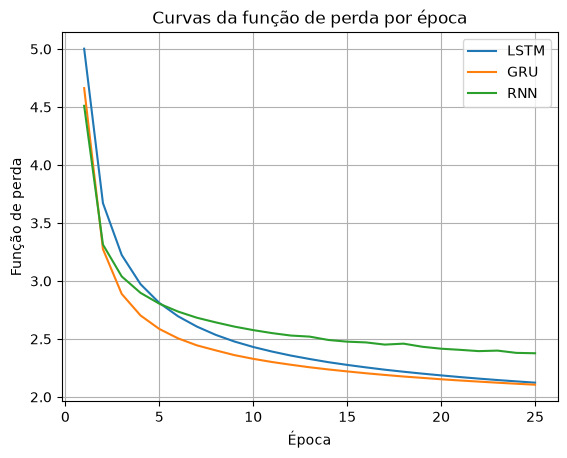

In [19]:
# Compara as curvas de treinamento das três arquiteturas recorrentes.
plt.figure()

for rnn_type in RNN_TYPES:

    losses = resultados_rnn[rnn_type]["losses"]
    epochs = range(1, len(losses) + 1)

    plt.plot(
        epochs,
        losses,
        label=rnn_type.upper()
    )

plt.xlabel("Época")
plt.ylabel("Função de perda")
plt.title("Curvas da função de perda por época")
plt.legend()
plt.grid(True)
plt.show()

### 5.6. Geração de Textos

#### 5.6.1. Classe geradora de textos para um modelo específico ( instância de `RNNModel` )

In [20]:
class TextGenerator:
    """
    Gerador de texto auto-regressivo, a partir de um modelo treinado.

    Esta classe recebe um modelo que, dado um tensor de índices de tokens
    com shape [B, L], devolve logits [B, L, V]. A partir disso, permite
    gerar texto token a token, usando amostragem com temperatura ou modo
    guloso (greedy).

    Parameters
    ----------
    model : torch.nn.Module
        Modelo de linguagem treinado que recebe entradas [B, L] e retorna
        logits [B, L, V].
    itos : list of str
        Lista de mapeamento índice -> token (index-to-string).
    device : str or torch.device, optional
        Dispositivo onde o modelo será executado (por exemplo, "cpu" ou "cuda").
        (default = "cpu")
    """

    def __init__(self, model, itos, device="cpu"):
        self.model = model.to(device)                    # envia o modelo para o dispositivo (CPU ou GPU)
        self.itos = itos                                 # lista índice -> token
        self.stoi = {w: i for i, w in enumerate(itos)}   # dicionário token -> índice (string-to-index)
        self.device = device                             # armazena o dispositivo para uso na geração

    def sample_from(self, probs, temperature=1.0):
        """
        Amostra um índice de token a partir de uma distribuição de probabilidade,
        ajustando-a por uma temperatura.

        Parameters
        ----------
        probs : numpy.ndarray
            Vetor 1D com probabilidades sobre o vocabulário (soma ≈ 1).
        temperature : float, optional
            Fator de "temperatura" para ajustar a distribuição:
            - valores < 1.0 tornam a distribuição mais "aguda" (mais determinística);
            - valores > 1.0 tornam a distribuição mais "achatada" (mais aleatória).
            (default = 1.0)

        Returns
        -------
        idx : int
            Índice de token amostrado da distribuição ajustada.
        p : numpy.ndarray
            Vetor de probabilidades após o ajuste de temperatura e normalização.
        """

        # ajusta a temperatura: eleva as probabilidades à potência 1/temperature
        p = probs ** (1.0 / temperature)
        p = p / p.sum()                                  # renormaliza para que a soma volte a ser 1
        idx = np.random.choice(len(p), p=p)              # amostra um índice de acordo com a distribuição ajustada

        return idx, p

    def generate(self, start_prompt, max_tokens=100, temperature=1.0, greedy=False):
        """
        Gera texto a partir de um prompt inicial, usando o modelo treinado.

        A geração é feita token a token, até atingir max_tokens ou até que
        o token de padding (ID 0) seja gerado.

        Parameters
        ----------
        start_prompt : str
            Texto inicial (prompt) a partir do qual a geração será continuada.
        max_tokens : int, optional
            Número máximo de tokens na sequência gerada (incluindo os do prompt).
            (default = 100)
        temperature : float, optional
            Temperatura usada na amostragem:
            - ignorado se greedy=True;
            - quanto menor, mais determinística a amostragem.
            (default = 1.0)
        greedy : bool, optional
            Se True, utiliza estratégia gulosa (sempre escolhe o token de maior
            probabilidade no passo atual). Se False, utiliza amostragem com temperatura.
            (default = False)

        Returns
        -------
        list of dict
            Lista de dicionários com informações por passo de geração. Cada item contém:
            - "prompt": texto gerado até aquele passo;
            - "word_probs": vetor numpy com a distribuição de probabilidade sobre o vocabulário;
            - "selected_idx": índice do token selecionado naquele passo;
            - "selected_word": token selecionado naquele passo.
        """

        tokens = [self.stoi.get(tok, 1) for tok in start_prompt.lower().split()]    # converte o prompt inicial em índices; tokens fora do vocabulário recebem ID 1 (<UNK>)
        generated = tokens.copy()                                                   # sequência de índices gerada até o momento
        info = []                                                                   # lista para armazenar probabilidades em cada passo
        self.model.eval()                                                           # coloca o modelo em modo de avaliação
        with torch.no_grad():                                                       # desativa gradientes
            while len(generated) < max_tokens and generated[-1] != 0:               # continua gerando enquanto não atingir max_tokens e não for gerado o token <PAD> (ID 0)
                x = torch.tensor([generated], device=self.device)                   # cria tensor de entrada com shape [1, seq_len]
                logits = self.model(x)                                              # obtém logits do modelo: [1, seq_len, V]
                probs = F.softmax(
                    logits[0, -1],                                                  # pega logits do último passo de tempo [V]
                    dim=-1
                ).cpu().numpy()                                                     # converte para probabilidades no CPU como numpy array
                if greedy:
                    idx = int(probs.argmax())                                       # modo guloso: escolhe o índice de maior probabilidade
                    p = probs                                                       # mantém a distribuição original
                else:
                    idx, p = self.sample_from(
                        probs,
                        temperature
                    )                                                               # modo estocástico: amostra usando temperatura

                # Registra o estado da geração, a distribuição utilizada para
                # selecionar o próximo token e o token efetivamente selecionado.
                # As duas últimas informações permitem analisar posteriormente
                # decisões interessantes sem depender da posição fixa do passo.
                info.append({
                    "prompt": " ".join(self.itos[t] for t in generated),
                    "word_probs": p,
                    "selected_idx": idx,
                    "selected_word": self.itos[idx]
                })
                generated.append(idx)                                               # adiciona o novo token gerado à sequência

        text = " ".join(self.itos[i] for i in generated)                            # converte a sequência final de índices de volta para texto
        mode = "GREEDY" if greedy else f"TEMP={temperature}"
        print(f"\nGenerated text ({mode}):\n{text}\n")                              # exibe o texto gerado na saída padrão

        return info                                                                 # retorna informações detalhadas de cada passo

In [21]:
# Configuração comum utilizada na geração de texto para os três modelos.
PROMPT = "recipe for roasted vegetables | "
MAX_GENERATED_TOKENS = 25

# Estratégias de geração que serão comparadas.
# No modo greedy, a temperatura é ignorada pela classe TextGenerator.
GENERATION_CONFIGS = [
    ("Temperatura 1.5", 1.5, False),
    ("Temperatura 1.0", 1.0, False),
    ("Temperatura 0.2", 0.2, False),
    ("Greedy",          1.0, True)
]

#### 5.6.2. Loop gerador de textos para cada modelo

In [22]:
# Gera textos com cada uma das arquiteturas recorrentes utilizando
# exatamente o mesmo prompt e as mesmas estratégias de geração.
for rnn_type in RNN_TYPES:

    model = resultados_rnn[rnn_type]["model"]

    # Cria um gerador de texto associado ao modelo atual.
    generator = TextGenerator(
        model=model,
        itos=ds.itos,
        device=DEVICE
    )

    print("\n" + "=" * 70)
    print(f"MODELO: {rnn_type.upper()}")
    print("=" * 70)

    # Armazena os resultados das diferentes estratégias de geração.
    resultados_rnn[rnn_type]["generations"] = {}

    for config_name, temperature, greedy in GENERATION_CONFIGS:

        # Reinicia a semente antes de cada geração para que todos os
        # experimentos estocásticos partam do mesmo estado aleatório.
        np.random.seed(SEED)

        print(f"\n{config_name}")
        print("-" * 70)

        # Gera o texto utilizando a estratégia atual.
        info = generator.generate(
            start_prompt=PROMPT,
            max_tokens=MAX_GENERATED_TOKENS,
            temperature=temperature,
            greedy=greedy
        )

        # Armazena as informações da geração para análise posterior.
        resultados_rnn[rnn_type]["generations"][config_name] = info

        # Exibe somente as três palavras com maior probabilidade no
        # primeiro passo após o prompt.
        print_probs_pt(
            info[:1],
            ds.itos,
            top_k=3
        )


MODELO: LSTM

Temperatura 1.5
----------------------------------------------------------------------

Generated text (TEMP=1.5):
recipe for roasted vegetables | preheat black seed ( cut into 1 day or grinder . snip sections on side of grill small hot )


PROMPT: recipe for roasted vegetables |
preheat          26.26%
in                6.68%
1                 4.13%
--------


Temperatura 1.0
----------------------------------------------------------------------

Generated text (TEMP=1.0):
recipe for roasted vegetables | preheat broiler . lightly oil 2 - quart shallow baking pan or gratin dish . ( can be prepared 1


PROMPT: recipe for roasted vegetables |
preheat          62.72%
in                8.04%
1                 3.91%
--------


Temperatura 0.2
----------------------------------------------------------------------

Generated text (TEMP=0.2):
recipe for roasted vegetables | preheat oven to 350°f . butter and flour two 9 - inch - diameter cake pans with 2 - inch


PROMPT: recipe 

#### 5.6.3. Função auxiliar para buscar casos extremos na geração

In [51]:
def find_interesting_cases(generations):
    """
    Procura automaticamente casos interessantes nas gerações de texto.

    Para cada modelo são selecionados dois tipos de caso:

    1. Sampling diferente do argmax:
       procura, entre as gerações estocásticas, o passo em que o token
       selecionado apresenta a maior diferença de probabilidade em relação
       ao token mais provável da distribuição.

    2. Distribuição concentrada:
       procura, entre as gerações com temperatura 0.2, o passo em que
       um único token apresenta a maior probabilidade.

    Parameters
    ----------
    generations : dict
        Dicionário contendo os resultados das estratégias de geração
        armazenados por TextGenerator.generate().

    Returns
    -------
    list of dict
        Casos selecionados automaticamente para análise.
    """

    divergent_cases = []
    concentrated_cases = []

    # Percorre todas as estratégias de geração disponíveis para o modelo.
    for config_name, info in generations.items():

        # O modo greedy não participa da busca por decisões divergentes,
        # pois nele o token selecionado é sempre o próprio argmax.
        is_greedy = config_name == "Greedy"

        # Percorre todos os passos registrados durante a geração.
        for step, step_info in enumerate(info):

            word_probs = np.asarray(step_info["word_probs"])

            # Recupera diretamente o token selecionado durante a geração.
            # Essas informações são armazenadas pela própria TextGenerator.
            selected_idx = step_info["selected_idx"]
            selected_word = step_info["selected_word"]
            selected_prob = float(word_probs[selected_idx])

            # Identifica o token com maior probabilidade no passo atual.
            argmax_idx = int(np.argmax(word_probs))
            argmax_word = ds.itos[argmax_idx]
            argmax_prob = float(word_probs[argmax_idx])

            # Nas estratégias estocásticas, procura situações em que o
            # token efetivamente amostrado não corresponde ao argmax.
            if not is_greedy and selected_idx != argmax_idx:

                # Quanto maior esta diferença, mais evidente é o efeito
                # da amostragem sobre a decisão produzida pelo modelo.
                probability_gap = argmax_prob - selected_prob

                divergent_cases.append({
                    "type": "divergent",
                    "config_name": config_name,
                    "step": step,
                    "selected_word": selected_word,
                    "selected_prob": selected_prob,
                    "argmax_word": argmax_word,
                    "argmax_prob": argmax_prob,
                    "score": probability_gap
                })

            # Para ilustrar o efeito de baixa temperatura, considera apenas
            # a geração com temperatura 0.2 e procura a distribuição mais
            # concentrada encontrada durante a sequência.
            if config_name == "Temperatura 0.2":

                concentrated_cases.append({
                    "type": "concentrated",
                    "config_name": config_name,
                    "step": step,
                    "selected_word": selected_word,
                    "selected_prob": selected_prob,
                    "argmax_word": argmax_word,
                    "argmax_prob": argmax_prob,
                    "score": argmax_prob
                })

    # Seleciona o caso em que a amostragem mais se afastou do token
    # que possuía a maior probabilidade.
    divergent_case = (
        max(divergent_cases, key=lambda case: case["score"])
        if divergent_cases
        else None
    )

    # Seleciona o caso de temperatura baixa em que a distribuição
    # apresentou a maior concentração em um único token.
    concentrated_case = (
        max(concentrated_cases, key=lambda case: case["score"])
        if concentrated_cases
        else None
    )

    # Remove eventuais casos inexistentes e devolve somente os exemplos
    # efetivamente encontrados nesta execução.
    return [
        case
        for case in [divergent_case, concentrated_case]
        if case is not None
    ]

#### 5.6.4.  Identifica e mostra casos extremos na geração de textos

In [ ]:
# Procura automaticamente casos interessantes para cada uma das
# arquiteturas recorrentes, evitando depender de passos fixos que
# poderiam mudar após um novo treinamento.
for rnn_type in RNN_TYPES:

    generations = resultados_rnn[rnn_type]["generations"]

    interesting_cases = find_interesting_cases(
        generations
    )

    # Exibe os casos encontrados utilizando a mesma apresentação de
    # probabilidades empregada nas demais análises do notebook.
    for case in interesting_cases:

        print("\n" + "=" * 70)

        if case["type"] == "divergent":
            description = "Sampling diferente do argmax"
        else:
            description = "Distribuição concentrada"

        print(
            f"{rnn_type.upper()} | "
            f"{case['config_name']} | "
            f"Passo {case['step'] + 1} | "
            f"{description}"
        )

        print("=" * 70)

        # Recupera o passo completo armazenado durante a geração.
        info = generations[case["config_name"]]

        # Exibe as três palavras mais prováveis naquele passo.
        print_probs_pt(
            info[case["step"]:case["step"] + 1],
            ds.itos,
            top_k=3
        )

        # Exibe explicitamente qual token foi efetivamente selecionado,
        # permitindo compará-lo com a previsão de maior probabilidade.
        print(
            f"Token selecionado: {case['selected_word']} "
            f"({case['selected_prob'] * 100:.2f}%)"
        )

        print(
            f"Token mais provável: {case['argmax_word']} "
            f"({case['argmax_prob'] * 100:.2f}%)"
        )


LSTM | Temperatura 1.0 | Passo 2 | Sampling diferente do argmax

PROMPT: recipe for roasted vegetables | preheat
oven             87.26%
broiler           9.70%
the               2.08%
--------

Token selecionado: broiler (9.70%)
Token mais provável: oven (87.26%)

LSTM | Temperatura 0.2 | Passo 3 | Distribuição concentrada

PROMPT: recipe for roasted vegetables | preheat oven
to              100.00%
and               0.00%
.                 0.00%
--------

Token selecionado: to (100.00%)
Token mais provável: to (100.00%)

GRU | Temperatura 1.0 | Passo 11 | Sampling diferente do argmax

PROMPT: recipe for roasted vegetables | whisk buttermilk , wine , and 1 teaspoon lemon juice
in               91.44%
,                 2.10%
and               2.02%
--------

Token selecionado: , (2.10%)
Token mais provável: in (91.44%)

GRU | Temperatura 0.2 | Passo 3 | Distribuição concentrada

PROMPT: recipe for roasted vegetables | preheat oven
to              100.00%
and               0.00%
up    

## **Seção 6 — MiniGPT**

### Hiperparâmetros específicos para o MiniGPT

Nesta seção está a resolução do laboratorio 6 referente aos modelos auto-regressivos com transformadores. Segundo especificação, ele mantém os mesmos hiperparametros do laboratorio da [Seção 5 — Modelos auto-regressivos com RNNs](#seção-5--modelos-auto-regressivos-com-rnns), abaixo reproduzidos apenas para simplificar a referência. 

| Parâmetro | Valor | Descrição |
|---|--:|---|
| `VOCAB_SIZE` | 10_000 | Número máximo de tokens no vocabulário |
| `MAX_LEN` | 200 | Comprimento máximo da sequência de entrada |
| `EMBEDDING_DIM` | 100 | Dimensão dos vetores de palavras |
| `BATCH_SIZE` | 32 | Número de exemplos por lote |
| `EPOCHS` | 25 | Número de passadas pelo conjunto de treinamento |
| `LEARNING_RATE` | 1e-3 | Passo usado pelo otimizador |
| `SEED`| 42 | Semente geradora de numeros aleatórios fixa para reprodutibilidade |

In [ ]:
# Hiperparâmetros específicos do MiniGPT, conforme a configuração
# base do Laboratório 6.
N_HEADS          = 2       # número de cabeças de atenção no caso base
FEED_FORWARD_DIM = 256     # dimensão do MLP interno do bloco Transformador no caso base

# O Lab 6 reutiliza diretamente o vocabulário construído no Lab 5.
vocab = ds.itos

### Redes Neurais

#### Camada de Transformação de Embeddings semanticos e posicionais

In [25]:
class TokenAndPositionEmbedding(nn.Module):
    """
    Camada que combina embedding de tokens e embedding posicional por soma.

    A soma exige que os embeddings de token e posição tenham a mesma dimensão.

    Parameters
    ----------
    max_len : int
        Comprimento máximo das sequências / número máximo de posições representáveis.
    vocab_size : int
        Tamanho do vocabulário (número máximo de tokens distintos).
    embed_dim : int
        Dimensão dos vetores de embedding para tokens e posições.

    Attributes
    ----------
    max_len : int
        Armazena o comprimento máximo da sequência.
    vocab_size : int
        Armazena o tamanho do vocabulário.
    embed_dim : int
        Armazena a dimensão do embedding.
    token_emb : nn.Embedding
        Embedding de tokens: índices de tokens -> vetores de dimensão embed_dim.
    pos_emb : nn.Embedding
        Embedding posicional: índices de posição -> vetores de dimensão embed_dim.
    """

    def __init__(self, max_len: int, vocab_size: int, embed_dim: int) -> None:

        super().__init__()            # inicializa a base nn.Module
        self.max_len = max_len        # comprimento máximo da sequência
        self.vocab_size = vocab_size  # tamanho do vocabulário
        self.embed_dim = embed_dim    # dimensão dos embeddings (token e posição)

        # Camada de embedding de tokens (treinável)
        self.token_emb = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim
        )

        # Camada de embedding posicional (treinável)
        self.pos_emb = nn.Embedding(
            num_embeddings=max_len,
            embedding_dim=embed_dim
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Propagação direta.
        Soma embeddings de token e posição.

        Parameters
        ----------
        x : torch.Tensor
            Tensor de entrada contendo índices de tokens com shape (B, S),
            onde B = tamanho do lote e S = comprimento da sequência.

        Returns
        -------
        torch.Tensor
            Embeddings combinados com shape (B, S, D),
            onde D = dimensão dos embeddings.
        """

        B, S = x.shape                                          # x: (B, S) -> extrai o tamanho do lote (B) e comprimento da sequência (S)

        positions = (                                           # constrói índices de posição para cada elemento do lote
            torch.arange(S, device=x.device)                    # cria [0, 1, ..., S-1] -> shape (S,)
            .unsqueeze(0)                                       # adiciona dimensão de lote -> shape (1, S)
            .expand(B, S)                                       # replica para cada item do lote -> shape (B, S)
        )

        token_embeddings = self.token_emb(x)                    # aplica embedding de tokens: (B, S) -> (B, S, D)
        pos_embeddings = self.pos_emb(positions)                # aplica embedding posicional: (B, S) -> (B, S, D)

        return token_embeddings + pos_embeddings                # combina informação semântica + ordem temporal por soma

    def extra_repr(self) -> str:
        return (                                                # define string extra para print/summary do módulo
            f"max_len={self.max_len}, "
            f"vocab_size={self.vocab_size}, "
            f"embed_dim={self.embed_dim}"
        )

#### Camada de Transformação e Máscara Causal

In [26]:
class MaskedTransformerLayer(nn.Module):
    """
    Bloco Transformer (do tipo decoder-only) com máscara causal.

    Este bloco implementa:
    1) Autoatenção com máscara causal (impede acesso a tokens futuros).
    2) Conexão residual + normalização por camada.
    3) MLP posição-a-posição (feed-forward) + conexão residual + normalização por camada.

    Parameters
    ----------
    embed_dim : int
        Dimensão dos vetores de embedding e atenção.
    num_heads : int
        Número de cabeças de atenção múltipla.
    ff_dim : int
        Dimensão da camada intermediária no MLP.
    dropout : float, optional
        Taxa de dropout aplicada à camada de atenção e ao MLP. Default: 0.1.

    Attributes
    ----------
    attn : nn.MultiheadAttention
        Camada de autoatenção múltipla que opera sobre (batch_size, seq_len, embed_dim).
    layer_norm_1 : nn.LayerNorm
        Normalização por camada aplicada após o bloco de atenção.
    mlp : nn.Sequential
        Rede MLP interna (Linear → ReLU → Linear → Dropout).
    layer_norm_2 : nn.LayerNorm
        Normalização por camada aplicada após o bloco de MLP.

    Notes
    -----
    A máscara causal impede que cada token no passo t "veja" tokens em posições > t.
    """

    def __init__(
        self,
        embed_dim: int,
        num_heads: int,
        ff_dim: int,
        dropout: float = 0.1
    ) -> None:

        super().__init__()                                                      # inicializa a base nn.Module

        # self.attn: Autoatenção de múltiplas cabeças usando x como Q, K e V
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,                                                # dimensão dos vetores de entrada/saída da atenção
            num_heads=num_heads,                                                # número de cabeças de atenção
            dropout=dropout,                                                    # dropout aplicado internamente pela atenção
            batch_first=True                                                    # formato esperado: (B, S, D)
        )

        # self.layer_norm_1: normalização aplicada após a conexão residual da atenção
        self.layer_norm_1 = nn.LayerNorm(embed_dim)                             # Normalização por Camada 1

        # self.mlp: rede feed-forward aplicada a cada token (Linear → ReLU → Linear → Dropout)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),                                       # projeta D -> ff_dim
            nn.ReLU(),                                                          # não-linearidade do MLP
            nn.Linear(ff_dim, embed_dim),                                       # projeta ff_dim -> D
            nn.Dropout(dropout)                                                 # dropout na saída do MLP (regularização)
        )

        # self.layer_norm_2: normalização aplicada após a conexão residual do MLP
        self.layer_norm_2 = nn.LayerNorm(embed_dim)                             # Normalização por Camada 2

    @staticmethod
    def _causal_mask(
        sz: int,
        device: torch.device | None = None
    ) -> torch.Tensor:
        """
        Cria máscara causal booleana com shape (sz, sz).

        Parameters
        ----------
        sz : int
            Comprimento da sequência (S).
        device : torch.device | None, optional
            Dispositivo onde a máscara será criada.

        Returns
        -------
        torch.Tensor
            Máscara booleana triangular superior:
            True  -> posições mascaradas (futuras),
            False -> posições permitidas.
        """

        return torch.triu(
            torch.ones(sz, sz, dtype=torch.bool, device=device),  # matriz cheia de True/1
            diagonal=1                                            # zera diagonal principal e parte inferior
        )

    def forward(
        self,
        x: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Propagação direta do bloco Transformador (mascarado).

        Parameters
        ----------
        x : torch.Tensor
            Entrada com shape (B, S, D), onde:
            B = tamanho do lote, S = comprimento da sequência, D = dimensão dos embeddings.

        Returns
        -------
        x_out : torch.Tensor
            Saída do bloco com shape (B, S, D).
        attn_output_weights : torch.Tensor
            Pesos de atenção. Pode ter forma (B, H, S, S) ou (B, S, S),
            dependendo da configuração de heads.
        """

        seq_len = x.shape[1]                                                    # x tem shape (B, S, D) -> extrai o comprimento da sequência (S)

        attn_mask = self._causal_mask(
            seq_len,
            x.device
        )                                                                       # máscara causal com shape (S, S)

        attn_output, attn_output_weights = self.attn(                           # Aplica a camada de autoatenção causal de múltiplas cabeças
            x,                                                                  # Query = x
            x,                                                                  # Key   = x
            x,                                                                  # Value = x
            attn_mask=attn_mask,                                                # impede atenção a tokens futuros
            need_weights=True,                                                  # retorna pesos de atenção
            average_attn_weights=True                                           # retorna média dos pesos entre cabeças
        )

        # Bloco "Add & Norm" (#1):
        #   1. Conexão residual: x (entrada original) + attn_output (saída da atenção).
        #   2. LayerNorm: normaliza a soma resultante ao longo da dimensão embed_dim.
        z = self.layer_norm_1(x + attn_output)                                  # Add & Norm #1: residual da atenção

        mlp_output = self.mlp(z)                                                # Aplica a rede MLP sobre z: (B, S, D) -> (B, S, D)

        # Bloco "Add & Norm" (#2):
        #   1. Conexão residual: z (entrada ao bloco MLP) + mlp_output (saída da rede MLP).
        #   2. LayerNorm: normaliza a soma resultante ao longo da dimensão embed_dim.
        x_out = self.layer_norm_2(z + mlp_output)                               # Add & Norm #2: residual do MLP

        return x_out, attn_output_weights                                       # retorna (saída do bloco, pesos de atenção)

#### Camada Linear e LogSoftmax

In [27]:
class LSM(nn.Module):
    """
    Aplica Linear seguido de LogSoftmax.

    Parameters
    ----------
    embed_dim : int
        Dimensão de entrada (tamanho do embedding vindo do Transformer).
    vocab_size : int
        Número de classes (tamanho do vocabulário).
    bias : bool, optional
        Se a camada Linear deve ter viés (bias). Default: False.
    """

    def __init__(
        self,
        embed_dim: int,
        vocab_size: int,
        bias: bool = False
    ) -> None:

        super().__init__()

        # Projeta de embed_dim para vocab_size (logits)
        self.linear = nn.Linear(
            in_features=embed_dim,
            out_features=vocab_size,
            bias=bias
        )

        # Converte logits em log-probabilidades
        self.log_softmax = nn.LogSoftmax(dim=-1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Parameters
        ----------
        x : torch.Tensor
            Tensor de entrada com shape (..., embed_dim).

        Returns
        -------
        torch.Tensor
            Log-probabilidades com shape (..., vocab_size).
        """

        logits = self.linear(x)

        return self.log_softmax(logits)

#### Composição das camadas num GPTMini

In [28]:
class GPTMini(nn.Module):
    """
    Modelo GPT simplificado (decoder-only) para geração de texto.

    Parameters
    ----------
    vocab_size : int
        Tamanho do vocabulário (número de tokens únicos).
    max_len : int
        Comprimento máximo das sequências (número de posições para embeddings posicionais).
    embed_dim : int
        Dimensão dos vetores de embedding (tanto para token quanto para posição).
    num_heads : int
        Número de cabeças de atenção múltipla no bloco Transformer.
    ff_dim : int
        Dimensão da camada intermediária no MLP do bloco Transformer.

    Attributes
    ----------
    embed_layer : TokenAndPositionEmbedding
        Camada que soma embeddings de token e posicionais.
    block : MaskedTransformerLayer
        Bloco Transformer (decoder-only) aplicado sobre a soma token_emb + pos_emb.
    lsm : LSM
        Camada linear + LogSoftmax que projeta vetores de dimensão embed_dim
        de volta ao espaço de vocabulário (tamanho vocab_size).
    """

    def __init__(
        self,
        vocab_size: int,
        max_len: int,
        embed_dim: int,
        num_heads: int,
        ff_dim: int
    ) -> None:

        super().__init__()

        # Camada de embeddings (tokens + posição)
        self.embed_layer = TokenAndPositionEmbedding(
            max_len=max_len,
            vocab_size=vocab_size,
            embed_dim=embed_dim
        )

        # Bloco Transformer (atenção causal + MLP)
        self.block = MaskedTransformerLayer(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim
        )

        # Camada final LSM: Linear + LogSoftmax
        self.lsm = LSM(
            embed_dim=embed_dim,
            vocab_size=vocab_size,
            bias=True
        )

    def forward(
        self,
        toks: torch.Tensor
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Executa a propagação direta do GPTMini.

        Parameters
        ----------
        toks : torch.Tensor
            Tensor de entrada contendo índices de tokens, com forma (B, S).
            Cada valor deve estar no intervalo [0, vocab_size).

        Returns
        -------
        log_probs : torch.Tensor
            Log-probabilidades para cada token no vocabulário,
            com shape (B, S, V).
        attn_weights : torch.Tensor
            Pesos de atenção do bloco Transformer.
        """

        # Gera o tensor resultante da soma de token + pos embeddings
        x: torch.Tensor = self.embed_layer(toks)                                # (B, S, D)

        # Passa pela cabeça do Transformer (atenção causal + MLP)
        h, attn = self.block(x)                                                 # (B, S, D), pesos de atenção

        # Projeta saída h do Transformer para log-probabilidades sobre o vocabulário
        log_probs = self.lsm(h)                                                # (B, S, V)

        # Retorna as log-probabilidades e os pesos de atenção
        return log_probs, attn

### Treinamento dos modelos

#### Calculo do negativo do logaritmo da verossimilhança (negative log-likelihood - NLL)

In [29]:
def compute_nll_logprobs(log_probs, targets, loss_fn):
    """
    Calcula o negativo do logaritmo da verossimilhança (negative log-likelihood - NLL)
    agregada sobre todos os tokens do batch, reformatando log-probabilidades e alvos
    para o shape esperado por NLLLoss.

    Parameters
    ----------
    log_probs : torch.Tensor
        Tensor de log-probabilidades com shape [B, S, V], onde:
        B = batch_size, S = comprimento da sequência, V = tamanho do vocabulário.
        Tipicamente é a saída direta de um modelo que aplica LogSoftmax na última dimensão.
    targets : torch.Tensor
        Tensor de alvos com shape [B, S], contendo IDs de tokens.
    loss_fn : torch.nn.Module
        Instância de função de perda compatível com log-probabilidades
        (ex.: nn.NLLLoss).

    Returns
    -------
    torch.Tensor
        Escalar com a perda NLL agregada de acordo com o `reduction` da loss_fn.
    """

    B, S, V = log_probs.shape       # B: tamanho do lote, S: comprimento da sequência, V: tamanho do vocabulário

    loss = loss_fn(
        log_probs.view(B * S, V),   # reshape de [B, S, V] -> [N, C], onde:
                                    #   N = B*S (um "exemplo" por token do lote)
                                    #   C = V   (número de classes = tamanho do vocabulário)
                                    # NLLLoss espera log-probabilidades nesse formato [N, C].
        targets.view(B * S)         # reshape de [B, S] -> [N], com:
                                    #   N = B*S (um rótulo inteiro por token do lote)
                                    # NLLLoss espera alvos 1D [N] alinhados com as linhas das predições.
    )

    return loss

#### Função de treinamento completo de um modelo específico ( instância de `MiniGPT` )

In [30]:
def train_minigpt(
    model,
    dataloader,
    optimizer,
    criterion,
    device: str = DEVICE,
    epochs: int = EPOCHS
) -> list[float]:
    """
    Treina o modelo pelo número de épocas especificado e retorna
    uma lista com a loss média por lote em cada época.

    Parameters
    ----------
    model : nn.Module
        Modelo PyTorch a ser treinado.
    dataloader : DataLoader
        DataLoader que fornece batches de (x, y).
    optimizer : torch.optim.Optimizer
        Otimizador para atualizar os pesos do modelo.
    criterion : callable
        Função de perda compatível com log-probabilidades
        (ex.: nn.NLLLoss com ignore_index=0).
    device : torch.device
        Dispositivo onde o modelo e dados serão alocados.
    epochs : int
        Número de épocas de treinamento.

    Returns
    -------
    losses_per_epoch : list of float
        Lista de tamanho `epochs`, onde cada elemento é a loss média
        por batch naquela época.
    """

    losses_per_epoch = []                                              # lista que armazenará a loss média de cada época

    # Loop principal de treinamento, iterando de 1 até epochs
    for epoch in tqdm(range(1, epochs + 1), desc="Épocas", unit="época"):

        model.train()                                                   # coloca o modelo em modo de treinamento (ativa dropout, etc.)
        running_loss = 0.0                                              # acumulador da loss ao longo dos batches desta época

        # Loop sobre todos os batches do dataloader
        for x, y in tqdm(dataloader, desc="Lotes", leave=False):

            x = x.to(device)                                            # move o batch de entrada para o dispositivo; x: [B, S]
            y = y.to(device)                                            # move o batch de alvos para o dispositivo;   y: [B, S]

            optimizer.zero_grad()                                       # zera gradientes acumulados de iterações anteriores

            log_probs, _ = model(x)                                     # forward do modelo; log_probs: [B, S, V]

            loss = compute_nll_logprobs(                                # calcula NLL agregada no batch
                log_probs,
                y,
                criterion
            )

            loss.backward()                                             # retropropagação: calcula gradientes
            optimizer.step()                                            # atualiza os parâmetros do modelo

            running_loss += loss.item()                                 # acumula o valor escalar da loss deste batch

        avg_loss = running_loss / len(dataloader)                       # calcula a loss média da época
        losses_per_epoch.append(avg_loss)                               # armazena a loss média desta época

    return losses_per_epoch                                             # devolve a lista de losses médias por época

#### Cáculo da perplexidade de um modelo específico ( instância de `MiniGPT` )

In [31]:
def compute_minigpt_perplexity(model, data_loader):
    """
    Calcula a perplexidade de um MiniGPT em um conjunto de dados.

    A função percorre todos os lotes do data_loader, acumula a soma do NLL
    sobre todos os tokens não-PAD e, ao final, computa:

        avg_nll = NLL média por token
        perplexity = exp(avg_nll)

    Parameters
    ----------
    model : torch.nn.Module
        MiniGPT já treinado que recebe tensores [B, S] e retorna
        log-probabilidades [B, S, V] e pesos de atenção.
    data_loader : torch.utils.data.DataLoader
        DataLoader com lotes (x_batch, y_batch) usados para avaliação.

    Returns
    -------
    tuple of float
        avg_nll : NLL média por token não-PAD.
        ppl     : perplexidade correspondente (exp(avg_nll)).
    """

    model.eval()                                               # coloca o modelo em modo de avaliação
    total_loss = torch.tensor(0.0, device=DEVICE)              # acumula a soma da NLL sobre todos os tokens não-PAD
    total_tokens = torch.tensor(0.0, device=DEVICE)            # acumula o número total de tokens não-PAD usados no cálculo

    loss_fn = nn.NLLLoss(
        ignore_index=0,                                        # ignora o token <PAD> (ID 0)
        reduction="sum"                                        # soma a NLL sobre os tokens válidos
    )

    with torch.no_grad():                                      # bloco sem cálculo de gradiente
        for x_batch, y_batch in data_loader:

            x_batch = x_batch.to(DEVICE)                       # move o lote de entradas para o dispositivo
            y_batch = y_batch.to(DEVICE)                       # move o lote de alvos para o dispositivo

            log_probs, _ = model(x_batch)                      # obtém log-probabilidades: [B, S, V]

            loss = compute_nll_logprobs(
                log_probs,
                y_batch,
                loss_fn
            )

            total_loss += loss                                 # acumula a soma das perdas
            total_tokens += (y_batch != 0).sum()               # conta tokens não-PAD

    avg_nll = total_loss / total_tokens                        # NLL média por token não-PAD
    ppl = torch.exp(avg_nll)                                   # perplexidade = exp(NLL média)

    return avg_nll.item(), ppl.item()

#### Setup dos experimentos

In [32]:
# Configurações dos experimentos do MiniGPT.
#
# Em cada experimento, apenas um hiperparâmetro é alterado em relação
# à configuração base. A dimensão do embedding deve ser divisível
# pelo número de cabeças de atenção.

MINIGPT_EXPERIMENTS = {
    "base": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": N_HEADS,
        "ff_dim": FEED_FORWARD_DIM
    },

    "embedding-64": {
        "embed_dim": 64,
        "num_heads": N_HEADS,
        "ff_dim": FEED_FORWARD_DIM
    },

    "embedding-128": {
        "embed_dim": 128,
        "num_heads": N_HEADS,
        "ff_dim": FEED_FORWARD_DIM
    },

    "heads-1": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": 1,
        "ff_dim": FEED_FORWARD_DIM
    },

    "heads-4": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": 4,
        "ff_dim": FEED_FORWARD_DIM
    },

    "ff-128": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": N_HEADS,
        "ff_dim": 128
    },

    "ff-512": {
        "embed_dim": EMBEDDING_DIM,
        "num_heads": N_HEADS,
        "ff_dim": 512
    }
}

# Valida a restrição exigida pelo MultiheadAttention:
# EMBEDDING_DIM precisa ser divisível por N_HEADS.
for experiment_name, config in MINIGPT_EXPERIMENTS.items():

    assert config["embed_dim"] % config["num_heads"] == 0, (
        f"Configuração inválida em '{experiment_name}': "
        f"embed_dim={config['embed_dim']} não é divisível por "
        f"num_heads={config['num_heads']}."
    )

#### Geração de path de salvamento do checkpoint conforme cada modelo

In [33]:
def get_minigpt_checkpoint_path(experiment_name):
    """
    Retorna o caminho do checkpoint correspondente a um experimento MiniGPT.

    Parameters
    ----------
    experiment_name : str
        Nome identificador do experimento.

    Returns
    -------
    pathlib.Path
        Caminho do arquivo de checkpoint.
    """

    return CHECKPOINT_DIR / f"lab6-minigpt-{experiment_name}.pt"

#### Salvamento de um checkpoint

In [34]:
def save_minigpt_checkpoint(
    experiment_name,
    model,
    config,
    losses,
    test_nll,
    test_ppl,
    num_params
):
    """
    Salva o estado do MiniGPT e os resultados associados ao experimento.
    """

    checkpoint_path = get_minigpt_checkpoint_path(experiment_name)

    checkpoint = {
        "experiment_name": experiment_name,
        "config": config,
        "model_state_dict": model.state_dict(),
        "losses": losses,
        "test_nll": test_nll,
        "test_ppl": test_ppl,
        "num_params": num_params
    }

    torch.save(checkpoint, checkpoint_path)

    print(f"Checkpoint salvo em: {checkpoint_path}")

#### Recuperação de um checkpoint

In [35]:
def load_minigpt_checkpoint(experiment_name):
    """
    Carrega o checkpoint de um experimento MiniGPT e reconstrói o modelo.

    Parameters
    ----------
    experiment_name : str
        Nome identificador do experimento.

    Returns
    -------
    dict
        Dicionário contendo o modelo reconstruído e os resultados
        previamente armazenados.
    """

    checkpoint_path = get_minigpt_checkpoint_path(experiment_name)

    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False
    )

    config = checkpoint["config"]

    model = GPTMini(
        vocab_size=len(vocab),
        max_len=MAX_LEN,
        embed_dim=config["embed_dim"],
        num_heads=config["num_heads"],
        ff_dim=config["ff_dim"]
    ).to(DEVICE)

    model.load_state_dict(checkpoint["model_state_dict"])

    return {
        "model": model,
        "config": config,
        "losses": checkpoint["losses"],
        "test_nll": checkpoint["test_nll"],
        "test_ppl": checkpoint["test_ppl"],
        "num_params": checkpoint["num_params"]
    }

#### Execução dos treinamentos

In [36]:
# Dicionário que concentra os modelos e resultados produzidos
# pelos experimentos com o MiniGPT.
resultados_minigpt = {}

# Função de perda utilizada em todos os experimentos.
# O MiniGPT retorna log-probabilidades, portanto usamos NLLLoss.
criterion_minigpt = nn.NLLLoss(ignore_index=0)

for experiment_name, config in MINIGPT_EXPERIMENTS.items():

    checkpoint_path = get_minigpt_checkpoint_path(experiment_name)

    print(f"\n{'=' * 70}")
    print(f"Experimento MiniGPT: {experiment_name}")
    print(
        f"embed_dim={config['embed_dim']}, "
        f"num_heads={config['num_heads']}, "
        f"ff_dim={config['ff_dim']}"
    )
    print(f"{'=' * 70}")

    if checkpoint_path.exists():

        print("Checkpoint encontrado. Carregando experimento...")

        resultados_minigpt[experiment_name] = (
            load_minigpt_checkpoint(experiment_name)
        )

    else:

        # O enunciado exige que cada experimento seja iniciado com a
        # mesma semente e com uma nova instância do modelo.
        torch.manual_seed(SEED)

        model = GPTMini(
            vocab_size=len(vocab),
            max_len=MAX_LEN,
            embed_dim=config["embed_dim"],
            num_heads=config["num_heads"],
            ff_dim=config["ff_dim"]
        ).to(DEVICE)

        # Um novo otimizador é criado imediatamente após o novo modelo,
        # conforme exigido pelo enunciado do laboratório.
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=LEARNING_RATE
        )

        losses = train_minigpt(
            model=model,
            dataloader=train_dl,
            optimizer=optimizer,
            criterion=criterion_minigpt,
            device=DEVICE,
            epochs=EPOCHS
        )

        test_nll, test_ppl = compute_minigpt_perplexity(
            model,
            test_dl
        )

        num_params = sum(
            p.numel()
            for p in model.parameters()
            if p.requires_grad
        )

        resultados_minigpt[experiment_name] = {
            "model": model,
            "config": config,
            "losses": losses,
            "test_nll": test_nll,
            "test_ppl": test_ppl,
            "num_params": num_params
        }

        # O checkpoint é salvo imediatamente após o término do
        # experimento para evitar a perda do treinamento realizado.
        save_minigpt_checkpoint(
            experiment_name=experiment_name,
            model=model,
            config=config,
            losses=losses,
            test_nll=test_nll,
            test_ppl=test_ppl,
            num_params=num_params
        )

    result = resultados_minigpt[experiment_name]

    print(
        f"NLL: {result['test_nll']:.4f} | "
        f"PPL: {result['test_ppl']:.2f} | "
        f"Parâmetros: {result['num_params']:,}"
    )


Experimento MiniGPT: base
embed_dim=100, num_heads=2, ff_dim=256


Épocas: 100%|██████████| 25/25 [07:21<00:00, 17.64s/época]


Checkpoint salvo em: checkpoints/lab6-minigpt-base.pt
NLL: 2.3841 | PPL: 10.85 | Parâmetros: 2,122,356

Experimento MiniGPT: embedding-64
embed_dim=64, num_heads=2, ff_dim=256


Épocas: 100%|██████████| 25/25 [05:35<00:00, 13.42s/época]


Checkpoint salvo em: checkpoints/lab6-minigpt-embedding-64.pt
NLL: 2.5663 | PPL: 13.02 | Parâmetros: 1,352,784

Experimento MiniGPT: embedding-128
embed_dim=128, num_heads=2, ff_dim=256


...

Checkpoint salvo em: checkpoints/lab6-minigpt-heads-4.pt
NLL: 2.3670 | PPL: 10.67 | Parâmetros: 2,122,356

Experimento MiniGPT: ff-128
embed_dim=100, num_heads=2, ff_dim=128


Épocas: 100%|██████████| 25/25 [07:14<00:00, 17.40s/época]


Checkpoint salvo em: checkpoints/lab6-minigpt-ff-128.pt
NLL: 2.4198 | PPL: 11.24 | Parâmetros: 2,096,628

Experimento MiniGPT: ff-512
embed_dim=100, num_heads=2, ff_dim=512


Épocas: 100%|██████████| 25/25 [07:26<00:00, 17.85s/época]


Checkpoint salvo em: checkpoints/lab6-minigpt-ff-512.pt
NLL: 2.3446 | PPL: 10.43 | Parâmetros: 2,173,812


### Comparação das curvas de perda de treinamento dos modelos

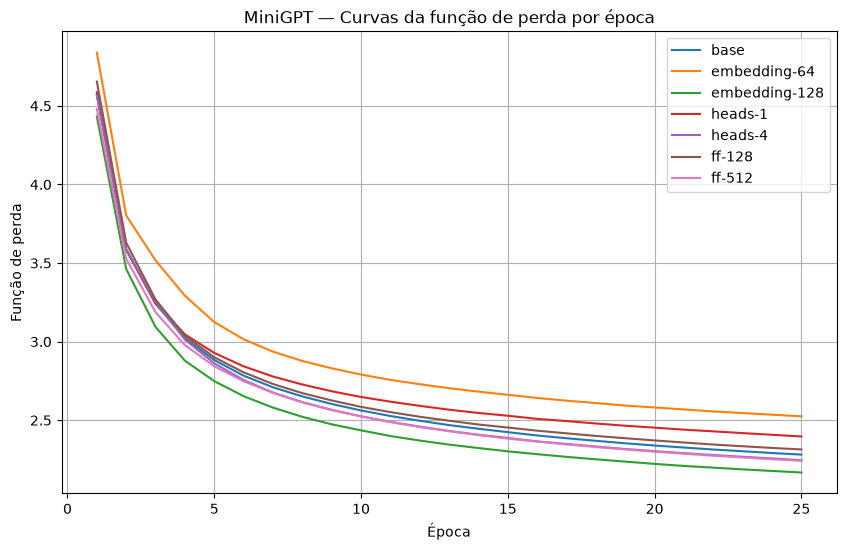

In [37]:
# Compara as curvas de perda dos diferentes experimentos MiniGPT.

plt.figure(figsize=(10, 6))

for experiment_name, result in resultados_minigpt.items():

    epochs = range(1, len(result["losses"]) + 1)

    plt.plot(
        epochs,
        result["losses"],
        label=experiment_name
    )

plt.xlabel("Época")
plt.ylabel("Função de perda")
plt.title("MiniGPT — Curvas da função de perda por época")
plt.legend()
plt.grid(True)
plt.show()

### Tabela comparativa entre os experimentos

In [38]:
# Exibe os resultados obtidos em todos os experimentos MiniGPT.

print(
    f"{'Experimento':<20} "
    f"{'Embedding':>10} "
    f"{'Heads':>7} "
    f"{'FF':>7} "
    f"{'NLL':>10} "
    f"{'PPL':>10} "
    f"{'Parâmetros':>15}"
)

print("-" * 86)

for experiment_name, result in resultados_minigpt.items():

    config = result["config"]

    print(
        f"{experiment_name:<20} "
        f"{config['embed_dim']:>10} "
        f"{config['num_heads']:>7} "
        f"{config['ff_dim']:>7} "
        f"{result['test_nll']:>10.4f} "
        f"{result['test_ppl']:>10.2f} "
        f"{result['num_params']:>15,}"
    )

Experimento           Embedding   Heads      FF        NLL        PPL      Parâmetros
--------------------------------------------------------------------------------------
base                        100       2     256     2.3841      10.85       2,122,356
embedding-64                 64       2     256     2.5663      13.02       1,352,784
embedding-128               128       2     256     2.3146      10.12       2,728,080
heads-1                     100       1     256     2.4761      11.90       2,122,356
heads-4                     100       4     256     2.3670      10.67       2,122,356
ff-128                      100       2     128     2.4198      11.24       2,096,628
ff-512                      100       2     512     2.3446      10.43       2,173,812


### Geração de Textos


#### Classe geradora de textos para um modelo específico ( instância de `MiniGPT` )

In [46]:
# CLASSE TextGeneratorMiniGPT – gera texto passo a passo com o modelo treinado
class TextGeneratorMiniGPT:
    """
    Gera texto autoregressivamente com base num modelo MiniGPT treinado.

    Attributes
    ----------
    idx_to_word : list[str]
        Lista de mapeamento índice → palavra.
    word_to_idx : dict[str, int]
        Dicionário de mapeamento palavra → índice.
    default_temperature : float
        Temperatura padrão de amostragem.
    """

    def __init__(self, idx_to_word: list[str], temperature: float = 1.0):

        self.idx_to_word = idx_to_word                                  # mapeamento índice → palavra
        self.word_to_idx = {w: i for i, w in enumerate(idx_to_word)}    # dicionário inverso palavra → índice
        self.default_temperature = temperature                          # temperatura padrão de amostragem

    def _tokenize(self, txt: str) -> list[str]:
        """
        Converte texto cru em uma lista de tokens utilizando exatamente
        a mesma normalização definida no EpicuriousRecipesDataset do Lab 5.

        A normalização:
        - converte o texto para letras minúsculas;
        - adiciona espaços ao redor dos sinais de pontuação;
        - reduz múltiplos espaços a um único espaço;
        - divide o texto normalizado em tokens.

        Parameters
        ----------
        txt : str
            Texto que será normalizado e tokenizado.

        Returns
        -------
        list[str]
            Lista de tokens produzida a partir do texto normalizado.
        """

        normalized_text = EpicuriousRecipesDataset._pad_punct(txt)

        return normalized_text.split()

    def _sample(self, probs: torch.Tensor, temperature: float) -> int:
        """
        Sorteia 1 token a partir de uma distribuição de probabilidade com temperatura.
        """

        probs = probs ** (1 / temperature)               # aplica temperatura
        probs = probs / probs.sum()                      # re-normaliza para somar 1

        return torch.multinomial(probs, 1).item()        # amostra 1 índice segundo a distribuição ajustada

    @torch.no_grad()                                     # desliga gradiente (inferência)
    def generate(
        self,
        model,
        prompt: str,
        max_tokens: int = MAX_LEN,
        temperature: float | None = None
    ) -> tuple[str, list[dict]]:
        """
        Gera texto passo a passo e coleta estatísticas de atenção e distribuição.

        Returns
        -------
        tuple[str, list[dict]]
            Texto completo gerado e informações coletadas em cada passo.
        """

        model.eval()                                     # ativa modo de avaliação

        temp = (
            self.default_temperature
            if temperature is None
            else temperature
        )

        ids = [
            self.word_to_idx.get(t, 1)
            for t in self._tokenize(prompt)
        ]                                                # prompt → lista de índices (1=<UNK>)

        info: list[dict] = []                            # lista onde cada item = stats de um passo

        while len(ids) < max_tokens and ids[-1] != 0:

            x = torch.tensor([ids], device=DEVICE)       # cria batch (1, S) e move p/ DEVICE

            log_probs, attn = model(x)                   # forward: log_probs (1, S, V) e atenção

            # Extrai os pesos de atenção da última posição.
            if attn.ndim == 4:

                step_atts = (
                    attn[0, :, -1, :]
                    .cpu()
                    .numpy()
                )

            else:

                step_atts = (
                    attn[0, -1, :]
                    .unsqueeze(0)
                    .cpu()
                    .numpy()
                )

            # Amostra o próximo token com temperatura.
            probs = log_probs[0, -1].exp()
            next_id = self._sample(probs, temp)

            # Armazena informações do passo atual para posterior visualização.
            info.append({
                "prompt": prompt,
                "word_probs": probs.cpu().numpy(),
                "atts": step_atts,
                "selected_idx": next_id,
                "selected_word": self.idx_to_word[next_id]
            })

            ids.append(next_id)                              # adiciona token sorteado ao contexto
            prompt += " " + self.idx_to_word[next_id]        # concatena palavra ao texto gerado

        return prompt, info

#### Loop gerador de textos para cada modelo

In [47]:
# Geração de texto utilizando exclusivamente a configuração base do MiniGPT.
#
# O prompt e a quantidade máxima de tokens são herdados do Laboratório 5.
# As definições abaixo são mantidas apenas como documentação e não são
# executadas, preservando exatamente os valores utilizados no Lab 5.

# PROMPT = "recipe for roasted vegetables | "   # definido no Lab 5
# MAX_GENERATED_TOKENS = 25                     # definido no Lab 5

# As temperaturas abaixo são específicas do experimento do Laboratório 6,
# conforme solicitado no enunciado.
MINIGPT_TEMPERATURES = [0.1, 0.5, 1.0, 1.5]

base_model = resultados_minigpt["base"]["model"]

text_generator_minigpt = TextGeneratorMiniGPT(vocab)

geracoes_minigpt = {}

for temperature in MINIGPT_TEMPERATURES:

    # Fixa a semente antes de cada geração para tornar a comparação
    # entre temperaturas reprodutível.
    torch.manual_seed(SEED)

    generated_text, info = text_generator_minigpt.generate(
        model=base_model,
        prompt=PROMPT,
        max_tokens=MAX_GENERATED_TOKENS,
        temperature=temperature
    )

    # Armazena tanto o texto produzido quanto as informações
    # coletadas durante cada passo da geração.
    geracoes_minigpt[temperature] = {
        "text": generated_text,
        "info": info
    }

    print(f"{'=' * 70}")
    print(f"MiniGPT base — Temperatura {temperature}")
    print(f"{'=' * 70}")
    print(generated_text)
    print()

MiniGPT base — Temperatura 0.1
recipe for roasted vegetables |  preheat oven to 450°f . in a large heavy skillet heat oil over moderately high heat until hot but not

MiniGPT base — Temperatura 0.5
recipe for roasted vegetables |  preheat oven to 450°f . generously butter and butter a 9 - inch skillet over moderate heat until foam subsides

MiniGPT base — Temperatura 1.0
recipe for roasted vegetables |  cut red bell pepper on a rack in a broiler and add onion ( season with salt and pepper .

MiniGPT base — Temperatura 1.5
recipe for roasted vegetables |  cut red bell pepper on an cauliflower in half lengthwise and enclose . scoop left lobster . using a chopstick



### Comparação entre todos os modelos geradores auto-regressivos (Laboratórios 5 e 6)

In [53]:
# Identifica o experimento MiniGPT com menor perplexidade no conjunto de teste.
best_minigpt_name = min(
    resultados_minigpt,
    key=lambda name: resultados_minigpt[name]["test_ppl"]
)

best_minigpt = resultados_minigpt[best_minigpt_name]

print(f"Melhor MiniGPT: {best_minigpt_name}")
print()

print(
    f"{'Modelo':<29} "
    f"{'NLL':>10} "
    f"{'PPL':>10} "
    f"{'Parâmetros':>15}"
)

print("-" * 67)

# Exibe os resultados do experimento MiniGPT com menor perplexidade.
print(
    f"{'MiniGPT (' + best_minigpt_name + ')':<29} "
    f"{best_minigpt['test_nll']:>10.4f} "
    f"{best_minigpt['test_ppl']:>10.2f} "
    f"{best_minigpt['num_params']:>15,}"
)

# Acrescenta à comparação os resultados das três arquiteturas
# recorrentes já calculados e armazenados no Laboratório 5.
for rnn_type in RNN_TYPES:

    result = resultados_rnn[rnn_type]

    print(
        f"{rnn_type.upper():<29} "
        f"{result['nll']:>10.4f} "
        f"{result['ppl']:>10.2f} "
        f"{result['num_params']:>15,}"
    )

Melhor MiniGPT: embedding-128

Modelo                               NLL        PPL      Parâmetros
-------------------------------------------------------------------
MiniGPT (embedding-128)           2.3146      10.12       2,728,080
LSTM                              2.3420      10.40       2,407,760
GRU                               2.3433      10.42       2,378,320
RNN                               2.5887      13.31       2,319,440
